<hr id="ust" style="border:0;margin:0">

# Sıfırdan ChatGPT — LLM ve GPT Mimarisi (17 Ders, Türkçe)
### Serinin tüm kodu, tek defterde

Kendi GPT'mizi sıfırdan yazıyoruz: tokenizer'dan attention'a, ön eğitimden instruction
finetuning'e kadar — indirilen bir model değil, satır satır kendimizin kurduğu bir model. Kavram
anlatım haritasında kurulur (`map.excalidraw`), sonra bu defter açılır: kod burada çalışır.

| | |
| --- | --- |
| **Nasıl kullanılır** | Yukarıdan aşağı çalıştır. Bir derse atlamak için kurulumun altındaki içindekilerden tıkla. |
| **Kod kümülatiftir** | Transformer bloğu attention'ı, attention embedding'i kullanır. `import` gerekmez. |
| **Kendine yeter** | Eksik kütüphaneyi kurar, veriyi bulur, GPU varsa GPU'da koşar. Elle kurulum yok. |
| **İnternet** | Açık olsun: GPT-2 ağırlıkları (124M ≈ 548 MB) ve — defteri tek başına açtıysan — iki veri dosyası iner. |

**Nereden açıyorsan:**

| | |
| --- | --- |
| **Kaggle** | Defteri yükle, sağ panelden **GPU T4 ×2** ve **Internet** anahtarlarını aç (ikisi de kapalı gelir), Run All. Veri kendiliğinden iner. |
| **Colab** | Defteri aç, **Runtime > Change runtime type > GPU**, Run All. Veri kendiliğinden iner. |
| **Yerel** | Depoyu klonla, defteri depo kökünde aç. `_data/` yanında olduğu için indirme bile olmaz. |
| **Renkli kutular** | 🟩 anlatım · 🟦 çıktının okunması · 🟨 yapılacak iş · 🟥 tuzak |

<hr id="kurulum" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Kurulum

Bu iki hücre bir kez çalışır: ortamı hazırlar ve veriyi yerine koyar. Sonrasında hiçbir ders kurulumla uğraşmaz.

In [1]:
# --- 1) Eksik kütüphaneleri kur (varsa dokunma) --------------------------------
import importlib.metadata, importlib.util, subprocess, sys

def ensure_package(name):
    """Modül yoksa kurar. Colab/Kaggle'da çoğu zaten hazırdır; o zaman hiçbir şey yapmaz."""
    if importlib.util.find_spec(name) is None:
        print(f"kuruluyor: {name}")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", name], check=True)


for _pkg in ("torch", "tiktoken", "numpy", "matplotlib", "pandas", "safetensors", "tqdm"):
    ensure_package(_pkg)

# --- 2) Ortak içe aktarmalar ---------------------------------------------------
import json, math, os, re, time, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- 3) Cihaz: GPU varsa GPU, yoksa CPU ---------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)          # sabit tohum: her koşuda aynı sayılar çıkar

print("torch     :", torch.__version__)
print("tiktoken  :", importlib.metadata.version("tiktoken"))
print("cihaz     :", device, f"({torch.cuda.get_device_name(0)})" if device.type == "cuda" else "")
print("çekirdek  :", os.cpu_count())

# --- 4) Ders künyesi -----------------------------------------------------------
_T0 = time.time()

def lesson(no, title):
    """Her dersin ilk hücresi: hangi derste olduğumuzu ve koşunun kaçıncı dakikasında
    olduğumuzu yazar. İçindekilerdeki ders bağları doğrudan bu hücreye iner."""
    print(f"Ders {no:02d} · {title}   ·   {(time.time() - _T0) / 60:.1f} dk")

torch     : 2.10.0+cu128
tiktoken  : 0.12.0
cihaz     : cuda (Tesla T4)
çekirdek  : 4


<div class="alert alert-block alert-info">

İkinci hücre **veri çözücüdür.** Serinin iki veri dosyasını üç yerde sırayla arar: defterin yanı başında (`_data/`), Kaggle'a eklenmiş girdilerde, ve son çare olarak serinin deposundan indirir. **Depoyu klonladıysan hiçbiri gerekmez, dosyalar zaten yanında.** Defteri tek başına açtıysan üçüncü adım devreye girer ve internet ister.

Bundan sonra hiçbir ders dosya yolu yazmaz: `data_path("how-words-work.txt")` denir ve doğru yol gelir.

</div>

In [2]:
# --- Veri çözücü ---------------------------------------------------------------

DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)

# Bu iki dosya seriye aittir: instruction-data.json'ın 24 kaydı bu seri için
# değiştirildi, yani üstteki kaynaktan indirilemez. Sıra: yerelde ara → Kaggle'a
# eklenen girdilerde ara → serinin deposundan indir.
# (topic-classification.json listede yok: bize ait, ders 13'te kodla üretilir.)
SOURCES = ["how-words-work.txt", "instruction-data.json"]
SEARCH_DIRS = ["_data", ".", "../_data", "../../_data"]
KAGGLE_INPUT_DIR = Path("/kaggle/input")
REPO_DATA_URL = "https://raw.githubusercontent.com/celiktepesahin/chatgpt-from-scratch-tr/main/_data"


def data_path(name):
    """Dosyanın yolunu döndürür. Bulamazsa ne yapılacağını söyleyerek durur."""
    target = DATA_DIR / name
    if target.exists():
        return target

    for folder in SEARCH_DIRS:                       # 1) defterin yanı başı
        candidate = Path(folder) / name
        if candidate.exists() and candidate.resolve() != target.resolve():
            target.write_bytes(candidate.read_bytes())
            return target

    if KAGGLE_INPUT_DIR.is_dir():                   # 2) Kaggle: + Add Input ile eklenen ne varsa
        for candidate in KAGGLE_INPUT_DIR.glob(f"*/**/{name}"):
            target.write_bytes(candidate.read_bytes())
            print(f"     girdiden alındı: {candidate}")
            return target

    try:                                        # 3) serinin deposundan indir
        with urllib.request.urlopen(f"{REPO_DATA_URL}/{name}", timeout=60) as r:
            target.write_bytes(r.read())
        print(f"     indirildi: {REPO_DATA_URL}/{name}")
        return target
    except Exception as err:
        hint = [
            f"{name} ne yerelde bulundu ne de indirilebildi ({type(err).__name__}).",
            "İnternet kapalıysa önce onu aç (Kaggle: sağ panel > Internet).",
            "Elle koymak istersen dosya serinin deposunda _data/ altındadır:",
            "  Kaggle : sağ panel > + Add Input > Upload > dosyayı seç, hücreyi yeniden çalıştır",
            "  Colab  : soldaki klasör simgesi > yükle (dosya /content'e düşer, yeter)",
            "  Yerel  : defterin yanına _data/ klasörü aç, dosyayı içine koy",
        ]
        raise FileNotFoundError(chr(10).join(hint)) from None


for _name in SOURCES:
    print(" ->", data_path(_name))

<hr id="icindekiler" style="border:0;margin:0;scroll-margin-top:6rem">

## İçindekiler

Ders adına tıkla, derse gider. Kaggle, Colab ve GitHub'da adın yanındaki **#** işaretini kullan.


**<a href="vscode-notebook-cell:?execution_count=3&line=1">BÖLÜM 1 · Büyük Resim</a>** <sup><a href="#bolum-1" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=3&line=1">Ders 01 · Öğrenme, Dil Modeli, LLM ve ChatGPT: Büyük Resim</a> <sup><a href="#ders-01" title="Kaggle / Colab / GitHub bağı">#</a></sup>

**<a href="vscode-notebook-cell:?execution_count=4&line=1">BÖLÜM 2 · Veriden Tensöre</a>** <sup><a href="#bolum-2" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=4&line=1">Ders 02 · Tokenizer'ı Yazıyoruz: Özel Token'lar ve BPE</a> <sup><a href="#ders-02" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=26&line=1">Ders 03 · Veri Hattı: Girdi–Hedef, Batch, Tensör, Embedding</a> <sup><a href="#ders-03" title="Kaggle / Colab / GitHub bağı">#</a></sup>

**<a href="vscode-notebook-cell:?execution_count=50&line=1">BÖLÜM 3 · Attention</a>** <sup><a href="#bolum-3" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=50&line=1">Ders 04 · Attention Nedir: Skor, Ağırlık, Bağlam ve Softmax</a> <sup><a href="#ders-04" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=66&line=1">Ders 05 · Eğitilebilir Attention: Q/K/V, √dₖ ve Sınıfı</a> <sup><a href="#ders-05" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=81&line=1">Ders 06 · Causal ve Multi-Head Attention</a> <sup><a href="#ders-06" title="Kaggle / Colab / GitHub bağı">#</a></sup>

**<a href="vscode-notebook-cell:?execution_count=98&line=1">BÖLÜM 4 · GPT Mimarisi</a>** <sup><a href="#bolum-4" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=98&line=1">Ders 07 · Sinir Ağı: Katman, GELU, Layer Norm, Feed Forward</a> <sup><a href="#ders-07" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=111&line=1">Ders 08 · Gradyan, Zincir Kuralı ve Shortcut Connection</a> <sup><a href="#ders-08" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=122&line=1">Ders 09 · Transformer Bloğu, GPT-2 ve İlk Metin</a> <sup><a href="#ders-09" title="Kaggle / Colab / GitHub bağı">#</a></sup>

**<a href="vscode-notebook-cell:?execution_count=136&line=1">BÖLÜM 5 · Eğitim</a>** <sup><a href="#bolum-5" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=136&line=1">Ders 10 · Kayıp ve Ön Eğitim: Cross-Entropy, Loss, Loop</a> <sup><a href="#ders-10" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=159&line=1">Ders 11 · Üretim Ayarları: Temperature ve Top-k</a> <sup><a href="#ders-11" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=173&line=1">Ders 12 · Ağırlıklar: Kaydet, Yükle, OpenAI'ın GPT-2'si</a> <sup><a href="#ders-12" title="Kaggle / Colab / GitHub bağı">#</a></sup>

**<a href="vscode-notebook-cell:?execution_count=188&line=1">BÖLÜM 6 · Finetuning</a>** <sup><a href="#bolum-6" title="Kaggle / Colab / GitHub bağı">#</a></sup>

- <a href="vscode-notebook-cell:?execution_count=188&line=1">Ders 13 · Finetuning Nedir ve Sınıflandırma Verisi</a> <sup><a href="#ders-13" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=199&line=1">Ders 14 · Classification Head ve Sınıflandırıcının Eğitimi</a> <sup><a href="#ders-14" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=222&line=1">Ders 15 · Instruction Finetuning: Template, Maske, DataLoader</a> <sup><a href="#ders-15" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=241&line=1">Ders 16 · Asistanı Eğit ve Cevaplarını Puanla</a> <sup><a href="#ders-16" title="Kaggle / Colab / GitHub bağı">#</a></sup>
- <a href="vscode-notebook-cell:?execution_count=255&line=1">Ders 17 · Kapanış: Ne Yazdık, Sırada Ne Var</a> <sup><a href="#ders-17" title="Kaggle / Colab / GitHub bağı">#</a></sup>

<hr id="bolum-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 1 · BÜYÜK RESİM

<hr id="ders-01" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 01 · Öğrenme, Dil Modeli, LLM ve ChatGPT: Büyük Resim

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="vscode-notebook-cell:?execution_count=4&line=1">Ders 02</a> <a href="#ders-02">→</a></sub>

In [3]:
lesson(1, "Öğrenme, Dil Modeli, LLM ve ChatGPT: Büyük Resim")

Ders 01 · Öğrenme, Dil Modeli, LLM ve ChatGPT: Büyük Resim   ·   0.0 dk


Bu dersin kodu yoktur; tamamı anlatım haritasındadır. Kurulan zincir şu: öğrenmek bir kuralı örneklerden çıkarmaktır → model o kuralı taşıyan parametre yığınıdır → dil modeli sonraki kelimeyi tahmin eder → LLM bunu milyarlarca parametreyle yapar → ChatGPT ise bir LLM'in üzerine sohbet davranışı eklenmiş hâlidir. Kod bir sonraki derste başlar.

Harita: `part-1-big-picture/01-big-picture/map.excalidraw`.

<hr id="bolum-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 2 · VERİDEN TENSÖRE

<hr id="ders-02" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 02 · Tokenizer'ı Yazıyoruz: Özel Token'lar ve BPE

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-01">←</a> <a href="vscode-notebook-cell:?execution_count=3&line=1">Ders 01</a>  ·  <a href="vscode-notebook-cell:?execution_count=26&line=1">Ders 03</a> <a href="#ders-03">→</a></sub>

In [4]:
lesson(2, "Tokenizer'ı Yazıyoruz: Özel Token'lar ve BPE")

Ders 02 · Tokenizer'ı Yazıyoruz: Özel Token'lar ve BPE   ·   0.0 dk


**Problem:** model harf görmez, sayı görür — ve hiç görmediği kelimeyle de baş etmeli.

Üç aşama: metni parçalayıp numaralayan kendi tokenizer'ımız, sözlükte olmayan kelime için özel token'lar, sonra GPT'nin gerçekten kullandığı **BPE** — kelimeyi bilinen parçalara bölerek sorunu kökünden kaldırır.

<hr id="konu-02-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Tokenizer'ı Sıfırdan Yazıyoruz: Metni Parçalara Ayır

Bu konunun kodu ham metni token dizisine, sonra token ID dizisine çeviriyor. Kendi tokenizer sınıfımızı yazıyoruz ve onu bilinçli olarak batıracağız; GPT'nin gerçekten kullandığı hazır çözüm (BPE) aynı dersin sonunda geliyor.

#### Metni okuyalım

<div class="alert alert-block alert-success">

Bütün veri hattının başlangıcı tek bir dizgi. `f.read()` dosyayı satırlara bölmez, hepsini uç uca tek metin olarak verir: 23 784 karakter. Nereden bölüneceğine biz karar vereceğiz.

Bu metin bizim Corpus (korpus) — modelin öğrendiği metin bütünü. `data_path(...)` kurulum hücresinde tanımlı: dosyayı arar, `_data/` altına kopyalar, yolunu döndürür.

</div>

In [5]:
with open(data_path("how-words-work.txt"), "r", encoding="utf-8") as f:
    raw_text = f.read()   # tek dizgi: 23784 karakter
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 23784
A sentence is a chain--each link holds the next--and the links are not all of the same kind. Some
c


#### Nereden bölmeli?

<div class="alert alert-block alert-success">

Hücre bölme kuralını üç adımda büyütüyor: yalnız boşluk → virgül ve nokta da ayırıcı → işe yaramayan parçalar elenir. Üç çıktı üst üste konunca her düzeltmenin ne kazandırdığı görünüyor.

`re.split` normalde ayırıcıyı atar; parantez onu **yakalama grubu** yapar ve ayırıcı da sonuçta kalır. Noktalama anlam taşıdığı için bu gerekiyor, ama bedeli ikinci çıktıda görünür: boşluklar ve boş dizgiler (`''`) de listeye düşüyor — üçüncü adım onları eliyor.

Üç çıktıyı üst üste karşılaştır: `Hello,` ilk adımda tek parçaydı, sonunda `Hello` ve `,` diye iki ayrı token.

</div>

In [6]:
text = "Hello, world. This, is a test."

# 1) Yalnız boşluktan böl
result = re.split(r'(\s)', text)
print(result)

# 2) Virgül ve nokta da ayırıcı olsun
result = re.split(r'([,.]|\s)', text)
print(result)

# 3) Boş ve yalnız boşluk olan parçaları ele
result = [item for item in result if item.strip()]
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']
['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']
['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


#### Kalan noktalama işaretleri

<div class="alert alert-block alert-success">

Korpusta `?`, `!`, `"`, `'`, `(`, `)`, `:`, `;` ve çift tire `--` de var; kalıp hepsini kapsıyor.

`--` köşeli parantezin **dışında**, ayrı bir seçenek olarak duruyor: köşeli parantez tek karakter eşler, çift tire ise iki karakterlik tek ayırıcı. Tek tire hiçbir seçenekte yok: `this--` bölünürken tireli bir kelime tek parça kalıyor.

</div>

In [7]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


#### Kalıbı bütün metne uygula

<div class="alert alert-block alert-success">

Aynı iki satır, bu kez metnin tamamına. İkinci çıktı **token sayısıdır, kelime sayısı değil** — noktalama da ayrı parça, çift tire de. Modelin ölçüsü token: pencere uzunluğu da hesap yükü de token cinsinden ölçülür.

İlk otuz parçayı gözden geçir: `chain` ile `--` ayrı ayrı duruyor, cümle sonundaki nokta da kendi başına bir token.

</div>

In [8]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

print(preprocessed[:30])
print(len(preprocessed))   # 23784 karakter -> 5136 token

['A', 'sentence', 'is', 'a', 'chain', '--', 'each', 'link', 'holds', 'the', 'next', '--', 'and', 'the', 'links', 'are', 'not', 'all', 'of', 'the', 'same', 'kind', '.', 'Some', 'carry', 'a', 'meaning', 'of', 'their', 'own']
5136


#### Token'dan sayıya: sözlük

<div class="alert alert-block alert-success">

Elde 5 136 parça var, ama çeşit sayısı bundan çok az: aynı token metinde defalarca geçiyor. Vocabulary (sözlük) her çeşidi bir kez kaydeder ve ona bir numara verir — `{token: numara}`.

`sorted` süs değil: `set` her koşuda aynı sırayı vermez, sıralamazsak token bir sonraki koşuda başka ID alır ve o ID'lere göre eğitilmiş tablo anlamsızlaşır.

ID bir **adres**, ölçü değil: `stone` ile `stones` alfabetik komşuluk yüzünden yan yana ID alır, anlamı yakın iki kelime ise iki uca düşer. Model bu ID'lerin üstünde doğrudan çalışamaz — çözüm ders 3'te.

</div>

In [9]:
all_words = sorted(set(preprocessed))   # 5136 token -> 1013 benzersiz
vocab_size = len(all_words)

print(vocab_size)

# Her token'a bir tam sayı: sözlük {token: numara}
vocab = {token:integer for integer,token in enumerate(all_words)}

1013


<div class="alert alert-block alert-success">

Sözlüğün ilk on iki kaydı. Sıralama karakter koduna göre: önce işaretler, sonra rakamlar, sonra BÜYÜK harfler, sonra küçük harfler. Numaranın anlamla ilgisi olmadığı burada çıplak görünüyor — `"` neden 0, `.` neden 6?

</div>

In [10]:
for item in list(vocab.items())[:12]:
    print(item)

('"', 0)
("'", 1)
(',', 2)
('--', 3)
('-ed', 4)
('-ness', 5)
('.', 6)
('1000', 7)
('700', 8)
(':', 9)
(';', 10)
('?', 11)


#### Tokenizer sınıfı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Tek sınıf iki yöne de çalışıyor: `encode` metni token'lara ayırıp ID listesi döndürür, `decode` ters yöne gider.

Satır satır: `str_to_int` sözlüğün kendisi, `int_to_str` onun tersi — sayıdan metne dönmek için ters eşlemenin de tutulması şart. `encode`ın ilk iki satırı yukarıdaki bölme kalıbının aynısı, üçüncü satır her parçayı sözlükte arar. `decode` ID'leri metne çevirip aralarına boşluk koyar; son satır o boşluğu noktalamanın önünden geri siler — kozmetik onarım.

</div>

In [11]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Noktalama işaretlerinden önceki boşluğu kaldır
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

<div class="alert alert-block alert-success">

Girdi korpusun içinden alınmış bir cümle: her token'ı sözlükte var, arama hiç boş dönmüyor. 19 token gidiyor, 19 ID dönüyor — dizi birebir korunuyor.

</div>

In [12]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"The river's mouth was wide, and the tree's shadow
           fell across it."""
ids = tokenizer.encode(text)
print(ids)

[0, 78, 734, 1, 746, 582, 967, 987, 2, 131, 881, 920, 1, 746, 780, 375, 98, 477, 6]


<div class="alert alert-block alert-success">

Ters yön: ID listesi → metin. Çıktıyı girdiyle karşılaştır. Harfler ve noktalama yerinde, ama üç yerde boşluk kaymış: baştaki tırnaktan sonra, `river' s` ve `tree' s` içinde. Kesme işareti ayrı bir token olduğu için birleştirme onu bitişik yazamıyor — bu tokenizer "harfi harfine geri gelir" sözünü veremez.

</div>

In [13]:
tokenizer.decode(ids)

'" The river\' s mouth was wide, and the tree\' s shadow fell across it.'

#### Sözlükte olmayan kelime

<div class="alert alert-block alert-success">

Şimdi korpusta hiç geçmeyen bir kelime verelim. Arama boş dönünce program durur: tahmin etmez, atlamaz, `KeyError` fırlatır — "bu anahtar sözlükte yok". Cümlenin geri kalan bütün token'ları bilinse de zincir ilk eksik halkada kopuyor.

Aşağıdaki hücre **kasten hata verir**; `raises-exception` etiketli olduğu için defterin koşmasını bozmaz. Hata mesajının hangi token'da düştüğüne bak.

</div>

In [14]:
text = "Hello, do you know the answer?"
print(tokenizer.encode(text))

KeyError: 'Hello'

<hr id="konu-02-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Bilinmeyen Kelime Sorunu ve Özel Token'lar

Önceki konu tek bir bilinmeyen kelimede durdu. En ucuz çare sözlüğe iki Special Token (özel token) eklemek: bilinmeyen her kelimeye ortak bir numara, iki metnin arasına da bir sınır işareti. Kod sözlüğü iki kayıt büyütüp tokenizer'ın ikinci sürümünü yazıyor; bedeli çıktıda görünecek.

#### İki özel token

<div class="alert alert-block alert-success">

Sözlük aynı token listesinden yeniden kuruluyor, sonuna iki kayıt eklenerek. `<|unk|>` sözlük dışı her kelimenin ortak numarası (unknown, bilinmeyen); `<|endoftext|>` bağımsız iki metnin arasına konan sınır işareti.

Numaralar 0'dan başladığı için son ID her zaman boydan bir eksiktir: 1 013 kayıtlı sözlükte ID'ler 0–1 012 arasıydı, iki yeni kayıt 1 013 ile 1 014'ü alıyor ve boy 1 015 oluyor.

</div>

In [15]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])   # sözlük boyu: 1013 -> 1015

vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(len(vocab.items()))

1015


<div class="alert alert-block alert-success">

Son beş kayıt: iki yeni token listenin sonuna eklendiği için en büyük iki numarayı alıyor, alfabetik sıraya girmiyor. Girmemeleri doğru — onlar metinden gelmiyor, görev taşıyor.

</div>

In [16]:
for item in list(vocab.items())[-5:]:
    print(item)

('year', 1010)
('yet', 1011)
('you', 1012)
('<|endoftext|>', 1013)
('<|unk|>', 1014)


#### `SimpleTokenizerV2`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** V1'in kopyası; değişen tek yer `encode` içindeki ekleme: sözlükte bulunmayan her token `<|unk|>` ile değiştiriliyor, böylece arama hiç boş dönmüyor.

Artık hata yok — ama bilgi de yok: iki ayrı bilinmeyen kelime aynı numaraya iniyor, aralarındaki fark siliniyor.

</div>

In [17]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int 
            else "<|unk|>" for item in preprocessed
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Noktalama işaretlerinden önceki boşluğu kaldır
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

<div class="alert alert-block alert-success">

İki ayrı cümle `<|endoftext|>` ile birleştirilip tek metin olarak veriliyor — modelin gözünde burası bir belgenin bittiği, ötekinin başladığı yer.

</div>

In [18]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you know the answer?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you know the answer? <|endoftext|> In the sunlit terraces of the palace.


<div class="alert alert-block alert-info">

Çıktıda iki yeni ID ara: bilinmeyen kelimelerin yerinde `<|unk|>`ın ID'si, iki metnin birleştiği yerde `<|endoftext|>`ın ID'si. 17 ID'nin dördü aynı numara — dört ayrı kelime tek kayda indi.

</div>

In [19]:
print(tokenizer.encode(text))

[1014, 2, 308, 1012, 491, 881, 133, 11, 1013, 39, 881, 1014, 1014, 615, 881, 1014, 6]


<div class="alert alert-block alert-success">

Geri çevirelim: hangi kelimeler yerinde, hangileri değil? Program artık durmuyor, ama `<|unk|>` olan dört kelimenin ne olduğu geri getirilemez.

</div>

In [20]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you know the answer? <|endoftext|> In the <|unk|> <|unk|> of the <|unk|>.'

<hr id="konu-02-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### BPE Nedir? GPT Kelimeleri Nasıl Parçalıyor?

Byte Pair Encoding (BPE), bilinmeyen kelime sorununu kökünden kaldırır: sözlükte kelimeler değil **kelime parçaları** durur. Bilinmeyen bir kelime gelirse `<|unk|>`'e düşmez, tanıdığı parçalara ayrılır. GPT-2'nin tokenizer'ı budur ve sözlüğü 50 257 token'dır.

#### Hazır uygulama: `tiktoken`

<div class="alert alert-block alert-success">

BPE'yi OpenAI'ın kullandığı hâliyle çalıştıran kütüphane. `get_encoding("gpt2")` GPT-2'nin **öğrenilmiş** birleştirme kurallarını yükler: hangi harf ikilisinin tek parça sayıldığı bir kez ölçülmüş ve dosyaya yazılmış. Biz eğitmiyoruz, hazır defteri açıyoruz — bu yüzden hangi metni verirsek verelim sözlük boyu değişmez.

</div>

In [21]:
tokenizer = tiktoken.get_encoding("gpt2")

#### Bilinmeyen kelime artık sorun değil

<div class="alert alert-block alert-success">

Aynı sınav, bu kez BPE ile: metinde `someunknownPlace` var, hiçbir kelime sözlüğünde bulunmaz.

`allowed_special` olmadan çağrı hata verirdi: tiktoken özel token'ı kaza ile düz metin sanmasın diye varsayılan olarak reddediyor. Argüman "yalnız bu token'ı işaret olarak kabul et" demek.

</div>

In [22]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


<div class="alert alert-block alert-success">

ID listesi geldi, `<|unk|>` yok. Geri çevirip metnin **tam olarak** geri geldiğini gör: birinci konudaki gidiş-dönüş turu bu kez kayıpsız.

</div>

In [23]:
print(tokenizer.decode(integers))

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


#### Peki nasıl oldu?

<div class="alert alert-block alert-success">

Anlamsız bir dizgi verelim: `Akwirw ier`. BPE bunu tanıdığı en uzun parçalara böler — on karakter altı parçaya iniyor; birleşince dizgi harfi harfine geri geliyor.

Sınır durumda parça tek bir bayta kadar iner ve sözlüğün ilk 256 kaydı zaten tek baytlardır. Bu yüzden **hiçbir girdi kodlanamaz değildir** — `<|unk|>` gereksizleşir.

</div>

In [24]:
integers = tokenizer.encode("Akwirw ier")   # 10 karakter -> 6 token parçası
print(integers)
print(tokenizer.decode(integers))

[33901, 86, 343, 86, 220, 959]
Akwirw ier


#### Sözlük boyları

<div class="alert alert-block alert-success">

GPT-2'nin 50 257'si üç kalemden gelir: 256 tek bayt + 50 000 öğrenilmiş birleştirme + 1 özel token. İlk 256 kayıt garanti katmanıdır, `<|unk|>`e gerek bırakmaz.

Çıktıdaki üç sayıyı karşılaştır: sözlük büyüdükçe aynı metin daha az token'a sığar, ama sözlükteki her kayıt çıkış katmanında bir satır demek — bu takasın hesabı ders 9'da.

</div>

In [25]:
# gpt2 · p50k_base (GPT-3) · cl100k_base (GPT-4 ve sonrası)
for model, encoding in [("gpt2", "gpt2"), ("gpt3", "p50k_base"), ("gpt4", "cl100k_base")]:
    print(f"The vocabulary size for {model.upper()} is: {tiktoken.get_encoding(encoding).n_vocab}")

The vocabulary size for GPT2 is: 50257


The vocabulary size for GPT3 is: 50281


The vocabulary size for GPT4 is: 100277


<div class="alert alert-block alert-success">

Artık metni sayıya çevirebiliyoruz. Sıradaki soru: bu sayı dizisinden **eğitim örneği** nasıl çıkar?

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-03" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 03 · Veri Hattı: Girdi–Hedef, Batch, Tensör, Embedding

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-02">←</a> <a href="vscode-notebook-cell:?execution_count=4&line=1">Ders 02</a>  ·  <a href="vscode-notebook-cell:?execution_count=50&line=1">Ders 04</a> <a href="#ders-04">→</a></sub>

In [26]:
lesson(3, "Veri Hattı: Girdi–Hedef, Batch, Tensör, Embedding")

Ders 03 · Veri Hattı: Girdi–Hedef, Batch, Tensör, Embedding   ·   0.1 dk


**Problem:** elimizde token ID dizisi var; model neyi tahmin etmeyi öğrenecek, sayılar ona hangi biçimde verilecek?

Hedef, dizinin bir adım kaydırılmış hâlidir — metin kendi öğretmenini üretir. Veriler kayan pencereyle kesilip yığınlara toplanır. Her ID bir **embedding** vektörüne çevrilir, çünkü ID sıra numarasıdır, ölçü değil. Sıra da kodlanır: "kedi balığı yedi" ile "balık kediyi yedi" aynı token'lardır.

<hr id="konu-03-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Girdi–Hedef Çiftleri: Metin Kendi Öğretmenini Üretir

Bu konunun kodu tek bir kesitten iki liste dilimliyor, sonra pencereyi bir token'dan dört token'a büyüten bir döngü yazıyor. Aynı dört çift önce ID, sonra `decode` ile metin olarak bastırılıyor.

#### Bütün metni token'a çevir

<div class="alert alert-block alert-success">

Aynı korpus, bu kez BPE ile. Kaç token çıktığına bak ve ders 2'nin sayısıyla karşılaştır: sözlük 1 013'ten 50 257'ye çıktığı hâlde dizi **kısalmadı, uzadı**.

Sebep şu: kelime tabanlı kural her kelimeyi tek parça sayıyordu, BPE ise sık olmayan kelimeleri birkaç parçaya bölüyor. Kazanç token sayısında değil, hiçbir girdinin kodlanamaz kalmamasında.

</div>

In [27]:
enc_text = tokenizer.encode(raw_text)   # 23784 karakter -> 5542 token
print(len(enc_text))

5542


#### Pencere ve kaydırma

<div class="alert alert-block alert-success">

Dizinin ortasından bir kesit alıyoruz: ilk 50 token atlanıyor ki örnek akan cümlelerin içinden gelsin.

İki liste aynı diziden dilimlenir, tek fark başlangıç indeksi. Dilim `[baş:son]` biçimindedir ve `son` dahil değildir: `[:4]` 0–3 indekslerini, `[1:5]` 1–4 indekslerini verir — aynı boy, bir adım kaymış.

Kayma bir hile değil, ön eğitimin bütün fikri: hedef girdinin içinden kesildiği için metni kimsenin etiketlemesi gerekmiyor.

</div>

In [28]:
enc_sample = enc_text[50:]          # ilk 50 token atlandı

context_size = 4  # modelin bir seferde göreceği token sayısı
# Girdi x = ilk 4 token, hedef y = bir token sağa kaymış hâli.
# Örnek: x = [1, 2, 3, 4] iken y = [2, 3, 4, 5]

x = enc_sample[:context_size]       # 4 token, 0. indeksten başlar
y = enc_sample[1:context_size+1]    # aynı boy 4, 1. indeksten: hedef

print(f"x: {x}")
print(f"y:      {y}")

x: [284, 3197, 393, 966]
y:      [3197, 393, 966, 379]


<div class="alert alert-block alert-success">

Aynı fikir döngüyle: `context` her turda bir token uzar, `desired` o dilimden hemen sonraki tek token. Dört tur, dört eğitim örneği — tek pencereden.

Her tur iki satır basıyor: üstte ID'ler, altında aynı çiftin `decode` edilmiş hâli. Modelin çözdüğü soru ikinci satırda çıplak duruyor: "to draw or" verildiğinde sonraki kelime ne?

</div>

In [29]:
for i in range(1, context_size+1):
    context = enc_sample[:i]    # uzunluk i: her turda bir token uzar
    desired = enc_sample[i]     # tek token: dilimden hemen sonraki

    print(context, "---->", desired)
    print("   ", tokenizer.decode(context), "---->", tokenizer.decode([desired]))

[284] ----> 3197
     to ---->  draw
[284, 3197] ----> 393
     to draw ---->  or
[284, 3197, 393] ----> 966
     to draw or ---->  point
[284, 3197, 393, 966] ----> 379
     to draw or point ---->  at


<hr id="konu-03-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Dataset ve DataLoader: Batch, Stride, Kayan Pencere

Bu konunun kodu iki parçadan oluşuyor: `Dataset` sınıfından türeyen kendi sınıfımız ve onu bir `DataLoader`'a bağlayan bir yardımcı fonksiyon. Sonra üç farklı ayarla yığın çekip çıktıları karşılaştırıyoruz.

#### `GPTDatasetV1`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** PyTorch'un `Dataset`i bir sözleşmedir: üç yöntemi doldurursan `DataLoader` senin verinle çalışmayı bilir. `__init__` bütün örnekleri hazırlar, `__len__` kaç örnek olduğunu söyler, `__getitem__` `idx` numaralı örneği verir.

Kritik satır `range(0, len(token_ids) - max_length, stride)`: adım `stride` olduğu için her `stride` token'da bir yeni pencere başlıyor. `input_chunk` pencerenin kendisi, `target_chunk` bir token sağa kaymış hâli — önceki konudaki `x`/`y` çiftinin aynısı, bu kez bütün metin boyunca ve tensör olarak: her örnek `(max_length,)` biçiminde.

</div>

In [30]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Metnin tamamını token'lara çevir
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Kayan pencereyle metni max_length uzunluğunda parçalara böl
        # şekil izi: her örnek (max_length,) biçiminde tek boyutlu tensör
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]               # uzunluk max_length
            target_chunk = token_ids[i + 1: i + max_length + 1]     # aynı boy, 1 sağa kaymış
            self.input_ids.append(torch.tensor(input_chunk))        # -> tensör (max_length,)
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]   # iki tensör, ikisi de (max_length,)

#### `create_dataloader_v1`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** `GPTDatasetV1` kurulup `DataLoader`'a veriliyor. Altı ayar: `batch_size` kaç pencere, `max_length` pencere boyu, `stride` kaydırma, `shuffle` pencere sırasını karıştırır, `drop_last` eksik kalan son yığını atar, `num_workers` yardımcı süreç sayısı.

`drop_last` sessiz görünen bir kural: tensör dikdörtgen olmak zorunda, yarım kalan bir yığın onu bozardı.

`Dataset` tek tek `(max_length,)` örnek verir; `DataLoader` bunları `torch.stack` ile üst üste koyar: `(batch_size, max_length)`. Yığın boyutu hiçbir yerde elle kurulmaz.

</div>

In [31]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Tokenizer'ı hazırla
    tokenizer = tiktoken.get_encoding("gpt2")

    # Veri kümesini oluştur
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Veri yükleyiciyi oluştur — batch_size tane (max_length,) tensörü
    # torch.stack ile tek yığına toplar: (batch_size, max_length)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

#### İlk yığına bakalım

<div class="alert alert-block alert-success">

`batch_size=1, max_length=4, stride=1`: tek pencere, 4 token, 1 token kayarak. `next(...)` bir yığın çeker.

Çıktı iki tensörlük bir liste: girdi ve hedef, ikisi de `(1, 4)`. İkinci tensör birincinin bir token sağa kaymış hâli — girdinin son üç token'ı hedefin ilk üçüyle aynı.

</div>

In [32]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)   # [girdi (1, 4), hedef (1, 4)]
print(first_batch)

[tensor([[  32, 6827,  318,  257]]), tensor([[6827,  318,  257, 6333]])]


<div class="alert alert-block alert-success">

İki yığını üst üste koy: `stride=1` olduğu için ikinci pencere birincinin son üç token'ıyla başlıyor. Çok örnek çıkar, yeni bilgi çıkmaz.

</div>

In [33]:
second_batch = next(data_iter)   # yine (1, 4) + (1, 4); pencere 1 token kaydı
print(second_batch)

[tensor([[6827,  318,  257, 6333]]), tensor([[ 318,  257, 6333,  438]])]


#### Örtüşmesiz ve yığın hâlinde

<div class="alert alert-block alert-success">

`stride` ile `max_length` eşit: örtüşme sıfır, her token tam bir kez girdi olur. Serinin eğitim kesimi de böyle ayarlı — aynı token'ı birçok pencerede görmek veriyi çoğaltmaz, aynı örneği ezberletir.

`batch_size=8` ile çıktı artık 8 satırlık bir tablo: `(8, 4)`. Satırlar uç uca okunur, çünkü pencereler örtüşmüyor — ilk satırın bittiği yerden ikinci satır başlıyor. `shuffle=False` gösterim içindir; eğitimde `True` olur.

</div>

In [34]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

inputs, targets = next(iter(dataloader))   # inputs (8, 4) · targets (8, 4)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 

tensor([[   32,  6827,   318,   257],
        [ 6333,   438, 27379,  2792],
        [ 6622,   262,  1306,   438],
        [  392,   262,  6117,   389],
        [  407,   477,   286,   262],
        [  976,  1611,    13,  2773],
        [  198, 34993,   257,  3616],
        [  286,   511,   898,    25]])

Targets:
 tensor([[ 6827,   318,   257,  6333],
        [  438, 27379,  2792,  6622],
        [  262,  1306,   438,   392],
        [  262,  6117,   389,   407],
        [  477,   286,   262,   976],
        [ 1611,    13,  2773,   198],
        [34993,   257,  3616,   286],
        [  511,   898,    25,  6290]])


<hr id="konu-03-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Matris Çarpımı ve Tensör: Yapay Zekânın Tek İşlemi

Bu konu çoğu anlatımda atlanır — ama olmadan sonrası ezber olur. Embedding bir matristir, dikkat mekanizması baştan sona matris çarpımıdır. Burada `@` işaretinin içini açıyoruz: önce elle döngüyle, sonra tek satırla, ikisinin aynı sayıyı verdiğini görerek.

#### Tensör: sayıların düzeni

<div class="alert alert-block alert-success">

Skaler, vektör, matris, 3B tensör: hepsi aynı kabın farklı derinlikleri. Her tensöre üç soru sorulur — `shape` (her boyutta kaç eleman), `dim()` (kaç boyut), `numel()` (toplam kaç sayı).

`shape` soldan okunur, en soldaki en dış kabuktur: `(8, 4, 256)` = 8 pencere, her pencerede 4 token, her token için 256 sayı. `numel` bunların çarpımıdır: 8 × 4 × 256 = 8 192.

Hata ayıklamanın ilk sorusu bu üçlüdür: şekil ne, nerede değişti?

</div>

In [35]:
scalar = torch.tensor(5)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0, 3.0],
                       [4.0, 5.0, 6.0]])
tensor3 = torch.zeros(8, 4, 256)          # yığın × token × boyut

for name, t in [("skaler", scalar), ("vektör", vector), ("matris", matrix), ("3B tensör", tensor3)]:
    print(f"{name:10s} shape={tuple(t.shape)}  boyut sayısı={t.dim()}  eleman={t.numel()}")

skaler     shape=()  boyut sayısı=0  eleman=1
vektör     shape=(3,)  boyut sayısı=1  eleman=3
matris     shape=(2, 3)  boyut sayısı=2  eleman=6
3B tensör  shape=(8, 4, 256)  boyut sayısı=3  eleman=8192


#### Nokta çarpımı: iki vektörün tek sayısı

<div class="alert alert-block alert-success">

Dot Product (nokta çarpımı): hizalı elemanları çarp, topla — iki vektör tek sayıya iner. O sayı bir uyum ölçüsüdür: aynı yöne bakan iki vektörde artılar birikir, zıt yönde birbirini götürür.

Aynı işlem iki kez yazılıyor: elle döngü ve `torch.dot`. Döngü her turda ara toplamı da basıyor — 1×4 = 4, sonra +2×5 → 14, sonra +3×6 → 32. İki yolun son sayısı birbirini tutmalı.

$a \cdot b = \sum_i a_i b_i$

</div>

In [36]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# 1) Elle: döngüyle çarp ve topla
by_hand = 0.0
for i in range(len(a)):
    by_hand += a[i].item() * b[i].item()
    print(f"  i={i}: {a[i]:.0f} × {b[i]:.0f} = {a[i]*b[i]:.0f}   ara toplam = {by_hand:.0f}")

# 2) PyTorch ile tek satır
print("elle      :", by_hand)
print("torch.dot :", torch.dot(a, b).item())

  i=0: 1 × 4 = 4   ara toplam = 4
  i=1: 2 × 5 = 10   ara toplam = 14
  i=2: 3 × 6 = 18   ara toplam = 32
elle      : 32.0
torch.dot : 32.0


#### Matris çarpımı: üç iç içe döngü ve tek işaret

<div class="alert alert-block alert-success">

Matris çarpımı yüzlerce nokta çarpımını tek hamlede yapar: sonucun `(i, j)` hücresi, A'nın i. satırıyla B'nin j. kolonunun nokta çarpımıdır.

Üç döngü tam bunu heceliyor: `i` A'nın satırlarını gezer, `j` B'nin kolonlarını, en içteki `t` o satır–kolon çiftinin terimlerini toplar. 3 satır × 3 kolon = 9 hücre, yani dokuz ayrı nokta çarpımı. `A @ B` aynısını tek işaretle yapıyor; `torch.allclose` iki sonucun aynı olduğunu söylüyor.

Şekil kuralı: `(3, 2) @ (2, 3) → (3, 3)`. İçteki iki sayı eşit olmak zorunda (A'nın kolon sayısı = B'nin satır sayısı), dıştakiler sonucun şekli.

</div>

In [37]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])          # şekil (3, 2)
B = torch.tensor([[1.0, 0.0, 2.0],
                  [0.0, 1.0, 3.0]])     # şekil (2, 3)

# 1) Elle: üç iç içe döngü — C[i][j] = A'nın i. satırı · B'nin j. kolonu
n, k = A.shape
_, m = B.shape

C_manual = torch.zeros(n, m)
for i in range(n):
    for j in range(m):
        total = 0.0
        for t in range(k):
            total += A[i, t] * B[t, j]
        C_manual[i, j] = total

# 2) PyTorch ile tek işaret
C_torch = A @ B

print("A @ B şekli:", tuple(C_torch.shape), f"  ({n},{k}) @ ({k},{m}) → ({n},{m})")
print("\nelle:\n", C_manual)
print("\ntorch:\n", C_torch)
print("\niki sonuç aynı mı?", torch.allclose(C_manual, C_torch))

A @ B şekli: (3, 3)   (3,2) @ (2,3) → (3,3)

elle:
 tensor([[ 1.,  2.,  8.],
        [ 3.,  4., 18.],
        [ 5.,  6., 28.]])

torch:
 tensor([[ 1.,  2.,  8.],
        [ 3.,  4., 18.],
        [ 5.,  6., 28.]])

iki sonuç aynı mı? True


#### Transpoze ve "herkes herkesle" çarpımı

<div class="alert alert-block alert-success">

Üç token, her biri 4 sayıyla temsil edilmiş: `(3, 4)`. Her token'ı her token'la karşılaştırmak istiyoruz, ama `(3, 4) @ (3, 4)` şekil kuralına uymuyor — içteki ikili eşit değil.

`X.T` satırlarla kolonları yer değiştirir: `(3, 4) → (4, 3)`. Artık `X @ X.T` el sıkışıyor ve `(3, 3)`lük bir skor tablosu çıkıyor: dokuz hücrede dokuz token çifti.

Köşegen her token'ın kendisiyle çarpımıdır, en büyük değerler orada. Son satır bunu sınıyor: `X[0]` ile `X[2]`nin nokta çarpımı tablonun `[0, 2]` hücresine eşit olmalı.

</div>

In [38]:
# 3 token, her biri 4 boyutlu bir vektörle temsil edilsin
X = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                  [0.0, 1.0, 0.0, 1.0],
                  [1.0, 1.0, 0.0, 0.0]])     # şekil (3, 4)

print("X   şekli:", tuple(X.shape))
print("X.T şekli:", tuple(X.T.shape))

scores = X @ X.T                              # (3,4) @ (4,3) → (3,3)
print("\nbütün token çiftlerinin skoru (3 × 3):\n", scores)

# Köşegen: her token'ın kendisiyle çarpımı — en büyük değerler orada
print("\nköşegen:", torch.diagonal(scores))
print("elle kontrol · 1. satır ile 3. satır:", torch.dot(X[0], X[2]).item(),
      "== skorlar[0, 2] =", scores[0, 2].item())

X   şekli: (3, 4)
X.T şekli: (4, 3)

bütün token çiftlerinin skoru (3 × 3):
 tensor([[2., 0., 1.],
        [0., 2., 1.],
        [1., 1., 2.]])

köşegen: tensor([2., 2., 2.])
elle kontrol · 1. satır ile 3. satır: 1.0 == skorlar[0, 2] = 1.0


#### Yığın boyutu: 3 boyutlu tensörlerde çarpım

<div class="alert alert-block alert-success">

Bir Layer'ın (katman) yaptığı iş budur: girdiyi bir ağırlık matrisiyle çarpmak. Yığın boyutu (8) dokunulmadan geçer, yalnız son iki boyut çarpılır: `(8, 4, 256) @ (256, 512) → (8, 4, 512)`. Adı *batched matmul*.

Üç boyutta `.T` kullanılmaz: yer değiştirecek iki boyut `transpose(1, 2)` ile numarayla verilir — yığın boyutu yerinde kalsın diye. Son satır sekiz pencerenin her biri için ayrı bir 4×4 skor tablosu çıkarıyor: bir sonraki bölümün attention hesabı tam bu şekle oturuyor.

</div>

In [39]:
X_batch = torch.randn(8, 4, 256)      # 8 pencere × 4 token × 256 boyut
W = torch.randn(256, 512)             # bir katmanın ağırlık matrisi: 256 → 512

Y = X_batch @ W                       # (8,4,256) @ (256,512) → (8,4,512)
print("girdi :", tuple(X_batch.shape))
print("ağırlık:", tuple(W.shape))
print("çıktı :", tuple(Y.shape), " — yığın boyutu (8) değişmedi")

# Aynı token çiftleri skoru, yığın hâlinde: (8,4,256) @ (8,256,4) → (8,4,4)
score_batch = X_batch @ X_batch.transpose(1, 2)
print("\nyığın hâlinde skor tablosu:", tuple(score_batch.shape), "= 8 ayrı 4×4 tablo")

girdi : (8, 4, 256)
ağırlık: (256, 512)
çıktı : (8, 4, 512)  — yığın boyutu (8) değişmedi

yığın hâlinde skor tablosu: (8, 4, 4) = 8 ayrı 4×4 tablo


<hr id="konu-03-4" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Token Embedding: Kelimenin Anlam Uzayındaki Adresi

Bu konunun kodu `torch.nn.Embedding` katmanını iki ölçekte kuruyor: önce 6 × 3 gibi gözle okunabilir bir tabloyla, sonra 50 257 × 256 ile. Arada katmanın ağırlığına doğrudan bakıp bir ID'yi tablodan geçiriyoruz.

#### Oyuncak ölçekte başlayalım

<div class="alert alert-block alert-success">

ID bir sıra numarasıdır: yan yana iki numara alfabetik komşuluktan gelir, anlamları yakın olduğundan değil. Model bu sayılarla hesap yapamaz — her ID'ye bir vektör gerekiyor. Embedding tam bunu tutan tablodur: sözlükteki her token'a bir satır.

`nn.Embedding(vocab_size, output_dim)`: `vocab_size` **satır** sayısı, `output_dim` satır **uzunluğu**. Oyuncak ölçek 6 × 3 = 18 sayı, gözle okunabilir. `manual_seed` aynı rastgele değerleri senin de görmen için.

</div>

In [40]:
input_ids = torch.tensor([2, 3, 5, 1])   # (4,) — dört token ID'si

vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)   # tablo: (6, 3)

<div class="alert alert-block alert-success">

`embedding_layer.weight` tablonun kendisi: altı satır, her satırda üç sayı. Değerler şimdilik rastgele — eğitim onları yerine yerleştirecek. Çıktıdaki `Parameter` ve `requires_grad=True` bunu söylüyor: bu tensörün gradyanı hesaplanacak, yani öğrenilecek.

</div>

In [41]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


#### Bir ID'yi tablodan geçirmek

<div class="alert alert-block alert-success">

Önce tek ID, sonra dört ID'lik tensör. Çıktıyı yukarıdaki tabloyla satır satır karşılaştır: `3` ID'sinin karşılığı tablonun dördüncü satırı (`-0.4015, 0.9666, -1.1481`). Katman satır seçmekten başka bir şey yapmıyor — hesap yok, arama var.

Şekil: `(4,)` giren tensör `(4, 3)` çıkıyor; her ID'nin yerine kendi satırı geliyor.

</div>

In [42]:
print(embedding_layer(torch.tensor([3])))   # (1,) -> (1, 3)
print(embedding_layer(input_ids))           # (4,) -> (4, 3)

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)
tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### Gerçek ölçek: GPT-2'nin sözlüğü

<div class="alert alert-block alert-success">

Aynı sınıf, bu kez `vocab_size = 50257` ve `output_dim = 256`. Tablo bastırılamayacak kadar büyük: 50 257 × 256 = 12 865 792 sayı, hepsi eğitilecek. Oyuncak tabloyla tek fark ölçek — arama kuralı ve çıkan şekil aynı.

Hücre çıktı basmıyor: tablo kuruluyor, sıra onu kullanmaya geliyor.

</div>

In [43]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)   # tablo: (50257, 256)

<div class="alert alert-block alert-info">

Yığını yeniden kurmuyoruz: `DataLoader` konusunun son hücresinde çektiğimiz yığın (`batch_size=8`, `max_length=4`, örtüşmesiz) hâlâ `inputs` adında duruyor. Şekil `(yığın, token)` sırasındadır.

</div>

In [44]:
max_length = 4   # DataLoader konusundaki yığının pencere boyu; `inputs` yeniden çekilmiyor

print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   32,  6827,   318,   257],
        [ 6333,   438, 27379,  2792],
        [ 6622,   262,  1306,   438],
        [  392,   262,  6117,   389],
        [  407,   477,   286,   262],
        [  976,  1611,    13,  2773],
        [  198, 34993,   257,  3616],
        [  286,   511,   898,    25]])

Inputs shape:
 torch.Size([8, 4])


<div class="alert alert-block alert-success">

Bütün yığın tek çağrıda embedding tablosundan geçiyor. Katman girdinin şeklini korur ve sonuna bir boyut ekler: `(8, 4)` girer, `(8, 4, 256)` çıkar — 32 ID'nin her biri 256 sayıya açıldı.

</div>

In [45]:
token_embeddings = token_embedding_layer(inputs)   # (8, 4) -> (8, 4, 256)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


<hr id="konu-03-5" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Positional Embedding: Sıra Neden Anlamı Değiştirir?

Bu konunun kodu üç adım: ikinci bir `Embedding` katmanı kuruluyor, konum numaraları ondan geçiriliyor ve çıkan tensör token embedding tensörüyle `+` ile toplanıyor.

#### Konum tablosu

<div class="alert alert-block alert-success">

Token embedding tablosu satırını yalnız ID'ye göre seçiyor; aynı kelime cümlenin başında da sonunda da aynı vektörü alıyor. Yani sıra bilgisi şu an tensörün hiçbir yerinde yok — ikinci bir tablo gerekiyor.

Aynı sınıf, farklı argümanlar: satır sayısı `context_length` (yani `max_length`), satır uzunluğu aynı `output_dim` — 4 × 256 = 1 024 sayı. Girdi olarak token ID'si değil `torch.arange(max_length)`, yani `[0, 1, 2, 3]` veriliyor: konum numaraları. Çıktıda şekle bak.

</div>

In [46]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)   # tablo: (4, 256)

pos_embeddings = pos_embedding_layer(torch.arange(max_length))   # (4,) -> (4, 256)
print(pos_embeddings.shape)

torch.Size([4, 256])


#### Toplama

<div class="alert alert-block alert-success">

`(8, 4, 256)` ile `(4, 256)` toplanıyor; şekiller aynı olmadığı hâlde hata yok. PyTorch'un bu davranışı **Broadcasting (yayma)**: eksik boyut kendiliğinden tekrarlanır, yani konum tablosu sekiz pencerenin hepsine aynen uygulanır — 3. sıradaki token hangi pencerede olursa olsun aynı sıra imzasını alır.

Konum bilgisi yan yana eklenmiyor, **toplanıyor**: yan yana eklemek vektör boyunu ikiye katlardı, toplama korur. Çıkan tensör modelin girdisidir: artık bir token'ı iki şey ayırıyor — hangi kelime olduğu ve nerede durduğu.

</div>

In [47]:
input_embeddings = token_embeddings + pos_embeddings   # (8, 4, 256) + (4, 256) -> (8, 4, 256)
print(input_embeddings.shape)

torch.Size([8, 4, 256])


<hr id="konu-03-6" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Veri Hattının Tamamı: Ham Metinden Tensöre

Bölüm 2'nin bütün konuları tek akışta. Aşağıdaki hücre bölümün özetidir: ham metin dosyasından modelin ilk katmanına giren tensöre kadar, arada hiçbir boşluk bırakmadan. Bundan sonraki her bölüm bu tensörün üstüne biner.

#### Uçtan uca

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Altı adıma ayrılmış tek betik; her adım kendi çıktısının şeklini basıyor. Sırayı takip et: karakter → token → pencere yığını → token vektörleri → konum vektörleri → toplam.

Dört ayar en başta toplandı. Birini değiştirip hücreyi yeniden koş: `batch_size` yığının satır sayısını, `max_length` sütun sayısını, `output_dim` en içteki sayı adedini oynatır — hangi şekillerin kaydığına bak.

</div>

In [48]:
# --- Ayarlar ------------------------------------------------------------------
vocab_size = 50257      # BPE sözlüğü (tiktoken "gpt2")
output_dim = 256        # token başına kaç sayı
max_length = 4          # pencere uzunluğu (token)
batch_size = 8          # aynı anda kaç pencere

# --- 1) Ham metin -------------------------------------------------------------
with open(data_path("how-words-work.txt"), "r", encoding="utf-8") as f:
    raw_text = f.read()
print(f"1) ham metin        : {len(raw_text)} karakter")

# --- 2) Token'lara böl (BPE) --------------------------------------------------
tokenizer = tiktoken.get_encoding("gpt2")
print(f"2) token            : {len(tokenizer.encode(raw_text))} token")

# --- 3) Kayan pencere + yığın -------------------------------------------------
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length,
    stride=max_length, shuffle=False
)
inputs, targets = next(iter(dataloader))
print(f"3) girdi ID tensörü : {tuple(inputs.shape)}   (yığın × token)")
print(f"   hedef ID tensörü : {tuple(targets.shape)}  — bir token sağa kaymış hâli")

# --- 4) Token embedding -------------------------------------------------------
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
token_embeddings = token_embedding_layer(inputs)
print(f"4) token embedding  : {tuple(token_embeddings.shape)}  (yığın × token × boyut)")

# --- 5) Konum embedding -------------------------------------------------------
pos_embedding_layer = torch.nn.Embedding(max_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(f"5) konum embedding  : {tuple(pos_embeddings.shape)}      (token × boyut)")

# --- 6) Topla -> modelin girdisi ---------------------------------------------
input_embeddings = token_embeddings + pos_embeddings
print(f"6) input_embeddings : {tuple(input_embeddings.shape)}  <- modelin ilk katmanına giren tensör")

1) ham metin        : 23784 karakter


2) token            : 5542 token
3) girdi ID tensörü : (8, 4)   (yığın × token)
   hedef ID tensörü : (8, 4)  — bir token sağa kaymış hâli


4) token embedding  : (8, 4, 256)  (yığın × token × boyut)
5) konum embedding  : (4, 256)      (token × boyut)
6) input_embeddings : (8, 4, 256)  <- modelin ilk katmanına giren tensör


#### Parametre sayısı

<div class="alert alert-block alert-success">

Bu bölümde kurulan iki tablonun kaç öğrenilebilir sayısı var — bu kez elle değil, kodla. `p.numel()` bir parametre tensörünün eleman sayısını verir; toplam, tabloların satır × kolon çarpımına eşit çıkmalı.

</div>

In [49]:
tok = sum(p.numel() for p in token_embedding_layer.parameters())
pos = sum(p.numel() for p in pos_embedding_layer.parameters())

print(f"token embedding tablosu : {vocab_size} × {output_dim} = {tok:,}".replace(",", " "))
print(f"konum embedding tablosu : {max_length} × {output_dim} = {pos:,}".replace(",", " "))
print(f"toplam                  : {tok + pos:,}".replace(",", " "))
print()
print("Veri hattı bitti. Bundan sonrası bu tensörün üstünde çalışıyor:")
print(f"  input_embeddings {tuple(input_embeddings.shape)} · cihaz: {input_embeddings.device}")

token embedding tablosu : 50257 × 256 = 12 865 792
konum embedding tablosu : 4 × 256 = 1 024
toplam                  : 12 866 816

Veri hattı bitti. Bundan sonrası bu tensörün üstünde çalışıyor:
  input_embeddings (8, 4, 256) · cihaz: cpu


<div class="alert alert-block alert-success">

Bölüm 2'nin kodu bitti. Bundan sonraki bütün hücreler `input_embeddings` biçimindeki bir tensörle çalışıyor: yığın × token × boyut.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="bolum-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 3 · ATTENTION

<hr id="ders-04" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 04 · Attention Nedir: Skor, Ağırlık, Bağlam ve Softmax

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-03">←</a> <a href="vscode-notebook-cell:?execution_count=26&line=1">Ders 03</a>  ·  <a href="vscode-notebook-cell:?execution_count=66&line=1">Ders 05</a> <a href="#ders-05">→</a></sub>

In [50]:
lesson(4, "Attention Nedir: Skor, Ağırlık, Bağlam ve Softmax")

Ders 04 · Attention Nedir: Skor, Ağırlık, Bağlam ve Softmax   ·   0.1 dk


**Problem:** bir kelimenin anlamı yanındakilere bağlı, ama her token hâlâ kendi başına duruyor. Hangi token'a ne kadar bakılacak?

Attention üç adım: her token çifti için **skor**, skorlardan toplamı bir eden **ağırlık**, ağırlıklı toplamdan **bağlam vektörü**. Bu ders mekanizmayı hiç öğrenilen parametre olmadan kuruyor ve skoru ağırlığa çeviren **softmax**'ın içini açıyor.

<hr id="konu-04-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Attention Nedir? Model Neye Bakacağını Nasıl Bilir?

Bölüm 2'nin sonunda elimizde `(yığın, token, boyut)` şeklinde bir tensör var ve her token kendi başına duruyor. Ama bir kelimenin anlamı yanındaki kelimelere bağlıdır. Bu bölümün sorusu şu: bir token işlenirken bağlamdaki diğer token'lardan **hangisine, ne kadar** bakılacak? Aşağıdaki liste bu bölümde yazacağımız beş sürümü ve her birinin hangi eksiği kapattığını gösteriyor; kod hemen ardından başlıyor.

#### Bu bölümde ne inşa edeceğiz

<div class="alert alert-block alert-success">

Beş sürüm sırayla yazılıyor; her biri bir öncekinin bıraktığı eksiği kapatıyor. Kod da böyle büyüyor: son sınıf ilk sürümün üzerine eklenmiş dört düzeltmeden oluşuyor.

- **basit dikkat** — parametre yok, mekanizmanın çıplak iskeleti
- **`SelfAttention`** — üç ağırlık matrisi: artık öğreniyor
- **`CausalAttention`** — maske (geleceği kapat) + dropout + yığın desteği
- **`MultiHeadAttentionWrapper`** — birden çok bakış, n bağımsız geçişle
- **`MultiHeadAttention`** — aynı başlar tek matris çarpımında: GPT'nin sınıfı

</div>

<hr id="konu-04-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Attention'ı Sıfırdan: Skor → Ağırlık → Bağlam

En sade hâliyle başlıyoruz: hiç öğrenilen parametre yok. Skoru **nokta çarpımıyla** hesaplıyoruz, ağırlığa çeviriyoruz, ağırlıklı toplamı alıyoruz. Öğrenilebilir matrisler ders 5'te gelecek — burada mekanizmanın iskeletini görüyoruz.

#### Altı token, üç boyut

<div class="alert alert-block alert-success">

"Your journey starts with one step" cümlesinin altı token'ı, her biri üç sayıyla temsil ediliyor.

Bu tensör ders 3'ün embedding çıktısının yerini tutuyor: orada sayılar eğitimle geliyordu, burada elle yazıldı ki her ara tablo aynı sayılarla izlenebilsin. Boyut neden 3? Gerçek modelde 768; ama 6 × 3 = 18 sayı bir kâğıda sığar, 6 × 768 sığmaz — mekanizma ikisinde de aynı.

Şekil `(6, 3)`: satır token, kolon boyut.

</div>

In [51]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89],  # Your     (x^1) · 1. token'ın vektörü
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

#### 1. adım: skorlar

<div class="alert alert-block alert-success">

Bir token seçip (ikincisi, `journey`) altı token'ın her biriyle ne kadar ilgili olduğunu tek sayıya indiriyoruz. Bu sayının adı **attention score (skor)**.

Ölçü nokta çarpımı: karşılıklı sayıları çarp, topla. Aynı yöne bakan iki vektörde büyük, ayrışanlarda küçük çıkar — `journey` × `journey` = 0.55×0.55 + 0.87×0.87 + 0.66×0.66 = 1.4950, altı skorun en büyüğü.

Kritik satır `attn_scores_2[i] = torch.dot(x_i, query)`: döngü altı token üzerinde yürüyor, sorgu her turda aynı kalıyor. `torch.empty(inputs.shape[0])` önce altı gözlü boş bir yer ayırıyor, döngü onu dolduruyor.

$\text{skor}_i = x_i \cdot q$ · şekil zinciri `(3,) · (3,) → skaler`, altı tur sonunda `(6,)`

</div>

In [52]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)  # nokta çarpımı

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


<div class="alert alert-block alert-info">

Altı skor çıktı. En büyüğü ikinci (1.4950) — sorgu kendisi olduğu için. Hemen ardında üçüncü var (1.4754): `starts` vektörü `journey`'ye çok benziyor. En küçüğü beşinci (0.7070), yani `one` — cümlenin en farklı yöne bakan token'ı. Sayılar 0 ile 1 arasında değil, çünkü henüz ham skor.

</div>

#### 2. adım: skorları ağırlığa çevir

<div class="alert alert-block alert-success">

Skorlar karışım oranı olacak. Oran olmanın iki şartı var: hiçbiri negatif olmayacak ve toplamı tam 1 edecek. Ham skorlar ikinci şartı tutmuyor.

En ucuz yol her skoru skorların toplamına bölmek. Altı skorun hepsi pozitif olduğu için burada iş görüyor; bir sonraki konu bu yolun nerede çöktüğünü gösterecek.

`attn_scores_2.sum()` böleni veriyor; `/` skalerle bölmeyi altı elemana ayrı ayrı uyguluyor: `(6,) / skaler → (6,)`. Sağlama satırı toplamı basıyor.

</div>

In [53]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


<div class="alert alert-block alert-success">

Aynı iş için hazır fonksiyon: `torch.softmax`. Sayılar toplama bölmeyle aynı çıkmıyor — softmax bölmeden önce her skorun e üssünü alıyor, bu yüzden büyük skoru daha da öne çıkarıyor. İçini bir sonraki konuda açacağız.

`dim=0` "toplamı 1 olacak eksen" demek; tek boyutlu bir vektörde tek eksen var, o yüzden 0.

</div>

In [54]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


<div class="alert alert-block alert-info">

İki liste de toplamı 1 veriyor ama sayılar farklı. En büyük skorun payı toplama bölmede 0.2278 iken softmax'ta 0.2379'a çıkıyor; ortalama civarındaki `Your` 0.1455'ten 0.1385'e düşüyor. Softmax araları büyütür: büyükten alıp küçüğe değil, küçükten alıp büyüğe verir.

</div>

#### 3. adım: bağlam vektörü

<div class="alert alert-block alert-success">

Oranlar hazır; şimdi karışım. Altı token'ın vektörü kendi ağırlığıyla çarpılıp toplanıyor, çıkan tek vektör `journey`'nin **context vector (bağlam vektörü)** oluyor.

Çıkan şey girdiyle aynı boyda — üç sayı. Yani token'ın yerine geçebilecek yeni bir temsil: artık içinde komşularından pay var. Üç adımın sırası zorunlu: skor olmadan ağırlık hesaplanamaz, ağırlık olmadan karışımın oranı belli olmaz.

`context_vec_2 += attn_weights_2[i]*x_i`: her turda bir vektör, ağırlığıyla ölçeklenip birikime ekleniyor. `torch.zeros(query.shape)` birikimi girdiyle aynı şekilde, sıfırdan başlatıyor.

$c_2 = \sum_i a_i x_i$ · şekil zinciri: altı kez `(3,)` → `(3,)`

</div>

In [55]:
context_vec_2 = torch.zeros(query.shape)   # query hâlâ 2. token
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


#### Altı token × altı token

<div class="alert alert-block alert-success">

Şimdiye kadar tek token için hesap yaptık. Altı token'ın hepsi için aynı şeyi yapmak 36 skor demek: her token her token'la.

İki yazım da aynı 36 sayıyı üretiyor. İç içe döngü ne olduğunu gösteriyor; `inputs @ inputs.T` aynı işi tek matris çarpımında yapıyor — GPU'nun hızlandırabildiği biçim bu, o yüzden gerçek kodda hep ikincisi. `torch.allclose` ikisinin eşitliğini sayıyla doğruluyor.

`.T` devrik demek: `(6, 3)` tensörün satırı kolon olur. Matris çarpımının şartı "soldakinin kolon sayısı = sağdakinin satır sayısı" — devrik tam bunu sağlıyor: `(6, 3) @ (3, 6) → (6, 6)`.

</div>

In [56]:
attn_scores_loop = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores_loop[i, j] = torch.dot(x_i, x_j)

# Aynı 36 sayı, tek çarpımda
attn_scores = inputs @ inputs.T   # (6, 3) @ (3, 6) -> (6, 6)
print(attn_scores)
print("döngüyle aynı mı?", torch.allclose(attn_scores_loop, attn_scores))

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
döngüyle aynı mı? True


<div class="alert alert-block alert-success">

Skor tablosu hazır; her satırı ağırlığa çevirmek gerek. `dim=-1` "son eksen" demek, yani **her satır kendi içinde** toplamı 1'e getirilir. Satır bir token'ın bakış dağılımı olduğu için doğru eksen bu.

`dim=0` yazılsaydı kolonlar toplamı 1 olurdu: "bu token'a kim bakıyor" tablosu — hata vermez, sessizce başka bir şey hesaplar. Kod bu yüzden satır toplamlarını da basıyor: altısı da 1 değilse `dim` yanlış.

</div>

In [57]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)
print("All row sums:", attn_weights.sum(dim=-1))

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


#### Altı bağlam vektörü, tek çarpımda

<div class="alert alert-block alert-success">

Ağırlık tablosu × girdi tablosu = altı bağlam vektörü, tek çarpımda. Elle yaptığımız `journey` hesabının altı token için toplu hâli.

`(6, 6) @ (6, 3) → (6, 3)`: ağırlık tablosunun her satırı, girdi tablosunun altı satırını kendi oranlarıyla topluyor. Çıkan tablonun boyu girdiyle aynı — altı token girdi, altı token çıktı.

Sağlama hazır: ikinci satır döngüyle bulduğumuz `context_vec_2` ile birebir aynı olmalı, kod ikisini alt alta basıyor.

</div>

In [58]:
all_context_vecs = attn_weights @ inputs   # (6, 6) @ (6, 3) -> (6, 3)
print(all_context_vecs)
print("Previous 2nd context vector:", context_vec_2)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


#### Görelim

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

Altı token'ın vektörü, artı yedinci nokta olarak `journey`'nin bağlam vektörü, üç boyutlu uzayda. Boyutu 3 tutmanın karşılığı burada alınıyor: 768 boyutlu bir vektör çizilemez, üç boyutlu çizilir.

İki çizim aynı yedi noktayı gösteriyor — birincisi yerlerini, ikincisi orijinden çıkan oklarla yönlerini. İkincisi mekanizmayı anlatan olan: nokta çarpımı yön yakınlığını ölçtüğü için `journey` ile `starts` oklarının neredeyse üst üste binmesi, skorlarının neden birbirine yakın çıktığını gösteriyor. Bağlam vektörü de kalabalığın ortasında duruyor: hepsinin karışımı olduğu için.

`torch.cat([inputs, all_context_vecs[1:2]])` yedinci satırı ekliyor. Dilim `[1]` değil `[1:2]`, çünkü `[1]` tek boyutlu `(3,)` verir ve birleştirme iki tensörün aynı boyutta olmasını ister: `(6, 3) + (1, 3) → (7, 3)`.

</div>

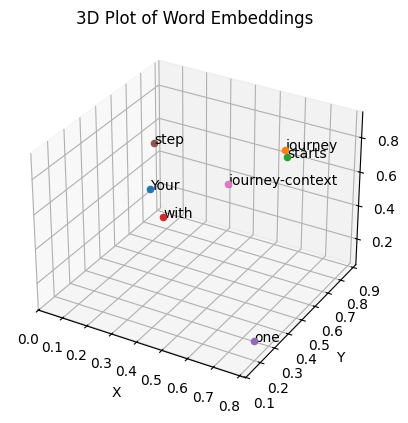

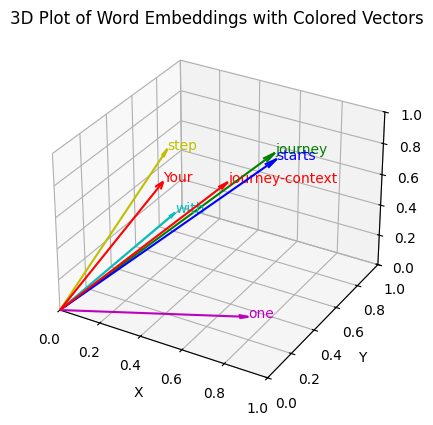

In [59]:
# Altı token, artı yedinci nokta olarak journey'nin bağlam vektörü
inputs2 = torch.cat([inputs, all_context_vecs[1:2]])   # (6, 3) + (1, 3) -> (7, 3)
words2 = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']
xs, ys, zs = inputs2[:, 0].numpy(), inputs2[:, 1].numpy(), inputs2[:, 2].numpy()

# 1. çizim: yedi noktanın yeri
ax = plt.figure().add_subplot(111, projection='3d')
for x, y, z, word in zip(xs, ys, zs, words2):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.title('3D Plot of Word Embeddings')
plt.show()

# 2. çizim: aynı noktalar, orijinden çıkan oklarla — yön de görünüyor
ax = plt.figure().add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']
for x, y, z, word, color in zip(xs, ys, zs, words2, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.set_zlim([0, 1])   # oklar kutunun içinde kalsın
plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<hr id="konu-04-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Softmax Nedir? Skoru Olasılığa Çeviren Fonksiyon

`softmax` genelde "olasılığa çeviren fonksiyon" diye geçiştirilir — ama serinin en çok çağrılan fonksiyonu: dikkat ağırlıklarında, kayıp hesabında, metin üretiminde. İçini şimdi açıyoruz.

#### Ne istiyoruz?

<div class="alert alert-block alert-success">

Bir önceki konuda skorları toplama bölerek ağırlığa çevirdik ve iş gördü. Şimdi aynı yolu negatif skor içeren bir listede deniyoruz: 2, −1, 0.5, −0.5.

Negatif skor niye gelsin? Ders 5'te skorlar öğrenilen matrislerden gelecek; o matrisler sayıları iki yöne de savurur. Yani negatif skor istisna değil, kural.

`scores / scores.sum()` bir önceki konudaki satırın aynısı. Ama bu listede bölen 1'e eşit — 2 + (−1) + 0.5 + (−0.5) = 1 — yani bölme hiçbir şeyi değiştirmiyor.

</div>

In [60]:
# Negatif skor içeren bir örnek — eğitilebilir matrislerle bu normaldir
scores = torch.tensor([2.0, -1.0, 0.5, -0.5])

naive = scores / scores.sum()
print("skorlar          :", scores.tolist())
print("toplama bölme    :", [round(v, 4) for v in naive.tolist()])
print("toplamı          :", naive.sum().item())
print("negatif var mı?  :", bool((naive < 0).any()), "  <- olmaması gerekiyordu")

skorlar          : [2.0, -1.0, 0.5, -0.5]
toplama bölme    : [2.0, -1.0, 0.5, -0.5]
toplamı          : 1.0
negatif var mı?  : True   <- olmaması gerekiyordu


<div class="alert alert-block alert-danger">

Çıktı iki şeyi birden söylüyor. "toplamı" satırı 1.0 diyor: şart sağlanmış gibi. Ama "toplama bölme" satırı girdinin aynısı ve içinde −1.0 ile −0.5 var. Negatif ağırlık karışımda anlamsız — bir token'a "eksi kadar bak" diye bir iş yok. Bir şartı tutan çözüm ötekini kaçırıyor; eksik olan adım skorları önce pozitife taşımak.

</div>

#### `softmax_naive`: e üssü, sonra payla

<div class="alert alert-block alert-success">

Negatifi pozitife taşıyan köprü: her skoru e'nin (≈ 2.7183) üssüne koymak. e üssü hiçbir girdide negatif çıkmaz ve sürekli artar — yani işaret sorunu biterken sıralama da korunur. Sonrası aynı: toplama böl.

Hücre iki iş yapıyor. Üstte fonksiyon ders 4'ün altı skoruna uygulanıyor ve `torch.softmax` ile aynı sayıları vermesi bekleniyor. Altta aynı hesap dört skorluk oyuncak listede satır satır dökülüyor: e üssü, toplam, pay.

Adımları çıktıda takip et: e^2 = 7.3891, e^−1 = 0.3679, e^0.5 = 1.6487, e^−0.5 = 0.6065; toplam 10.0122; ilk pay 7.3891 ÷ 10.0122 = 0.7380. Negatif skorun payı sıfır değil, 0.0367 — küçük ama var, yani hiçbir token karışımın dışında bırakılmıyor.

$\text{softmax}(x)_i = e^{x_i} / \sum_j e^{x_j}$

</div>

In [61]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

# Aynı hesap adım adım — her sayının nereden geldiği görünür (`scores` yukarıdan)
exps = torch.exp(scores)     # 1) her skorun eksponansiyeli — hepsi pozitif
total = exps.sum()           # 2) toplamı
weights = exps / total       # 3) her biri toplama bölünür

for s, e, w in zip(scores.tolist(), exps.tolist(), weights.tolist()):
    print(f"  skor {s:5.1f}   ->  e^skor = {e:8.4f}   ->  ağırlık = {w:.4f}")
print(f"\n  toplam e^skor = {total:.4f}")
print(f"  ağırlıkların toplamı = {weights.sum().item():.6f}")
print(f"  negatif var mı? {bool((weights < 0).any())}")
print(f"\ntorch.softmax ile aynı mı? {torch.allclose(weights, torch.softmax(scores, dim=0))}")

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)
  skor   2.0   ->  e^skor =   7.3891   ->  ağırlık = 0.7380
  skor  -1.0   ->  e^skor =   0.3679   ->  ağırlık = 0.0367
  skor   0.5   ->  e^skor =   1.6487   ->  ağırlık = 0.1647
  skor  -0.5   ->  e^skor =   0.6065   ->  ağırlık = 0.0606

  toplam e^skor = 10.0122
  ağırlıkların toplamı = 1.000000
  negatif var mı? False

torch.softmax ile aynı mı? True


#### İki sürümü büyük sayılarda karşılaştır

<div class="alert alert-block alert-success">

`softmax_naive` matematikte doğru ama bilgisayarda kırılgan. Denemesi kolay: üç büyük skor — 1000, 1001, 1002 — iki sürüme birden.

e^1000 float32'nin taşıyabileceğinden büyük; sonuç `inf` oluyor, `inf / inf` de `nan`. Bu uydurma bir tehlike değil: derin bir modelde ara skorlar yüzlere kolayca çıkar ve `nan` bir kez doğduktan sonra bütün hesabı yer.

`torch.softmax` aynı girdide sağlam sayı veriyor. Farkının ne olduğunu bir sonraki hücrede yazacağız.

</div>

In [62]:
big = torch.tensor([1000.0, 1001.0, 1002.0])

print("softmax_naive :", softmax_naive(big).tolist(), "  <- nan: e^1000 taştı")
print("torch.softmax :", [round(v, 4) for v in torch.softmax(big, dim=0).tolist()])

softmax_naive : [nan, nan, nan]   <- nan: e^1000 taştı
torch.softmax : [0.09, 0.2447, 0.6652]


#### Kararlı sürüm: en büyüğü çıkar

<div class="alert alert-block alert-success">

Tek satırlık düzeltme: e üssünü almadan önce listenin en büyüğünü hepsinden çıkar. En büyük eleman 0 olur, e^0 = 1; geri kalanların hepsi 1'in altında kalır, hiçbir şey taşmaz.

Sonuç değişmez, çünkü pay ve payda aynı sabitle bölünüp sadeleşir: $e^{x_i-m} / \sum_j e^{x_j-m}$ ile $e^{x_i} / \sum_j e^{x_j}$ aynı sayı.

`keepdim=True` en büyüğü `(..., 1)` şeklinde tutuyor; olmasaydı eksen düşer ve çıkarma yayılırken yanlış eksene hizalanırdı. Kod iki sağlama basıyor: büyük sayılarda ve küçük sayılarda `torch.softmax` ile aynı mı. `torch.softmax`'ın içinde tam olarak bu düzeltme var — yani bundan sonra hep kararlı sürümü çağırıyoruz.

</div>

In [63]:
def softmax_stable(x, dim=-1):
    """Sayısal olarak güvenli softmax: en büyük değeri çıkarmak sonucu değiştirmez."""
    x_max = x.max(dim=dim, keepdim=True).values
    e = torch.exp(x - x_max)
    return e / e.sum(dim=dim, keepdim=True)

print("kararlı sürüm :", [round(v, 4) for v in softmax_stable(big, dim=0).tolist()])
print("torch ile aynı mı?", torch.allclose(softmax_stable(big, dim=0), torch.softmax(big, dim=0)))

# Küçük sayılarda da aynı sonucu verir (`scores` = dört elemanlı örnek)
print("küçük sayılarda aynı mı?", torch.allclose(softmax_stable(scores, dim=0), torch.softmax(scores, dim=0)))

kararlı sürüm : [0.09, 0.2447, 0.6652]
torch ile aynı mı? True
küçük sayılarda aynı mı? True


#### `dim` neyi belirler?

<div class="alert alert-block alert-success">

Softmax'ın tek ayarı `dim`: "toplamı 1 olacak" şartının hangi eksen boyunca uygulanacağı. Yanlış eksen hata vermez, sessizce başka bir tablo üretir — bu yüzden ayrı bir hücreyi hak ediyor.

`(2, 3)` bir tabloda iki seçenek var: `dim=-1` her satırı kendi içinde toplar (2 satır, her birinin toplamı 1), `dim=0` her kolonu (3 kolon, her birinin toplamı 1). Dikkat ağırlıklarında satır bir token'ın dağılımı olduğu için doğrusu `dim=-1`.

İkinci satır bilerek üç eşit sayıdan kuruldu: `dim=-1`'de üçü de 0.3333 çıkıyor — eşit skor, eşit pay. Kolon toplamlarında üçüncü değerin tam 1 çıkmadığına da bak: kayan noktalı toplama son basamakta hep biraz sapar.

</div>

In [64]:
m = torch.tensor([[1.0, 2.0, 3.0],
                  [1.0, 1.0, 1.0]])

row = torch.softmax(m, dim=-1)     # her SATIR toplamı 1  <- dikkat mekanizmasında bu
col = torch.softmax(m, dim=0)      # her KOLON toplamı 1

print("dim=-1 (satır bazında):\n", row)
print("satır toplamları:", row.sum(dim=-1).tolist())
print("\ndim=0 (kolon bazında):\n", col)
print("kolon toplamları:", col.sum(dim=0).tolist())

dim=-1 (satır bazında):
 tensor([[0.0900, 0.2447, 0.6652],
        [0.3333, 0.3333, 0.3333]])
satır toplamları: [1.0, 1.0]

dim=0 (kolon bazında):
 tensor([[0.5000, 0.7311, 0.8808],
        [0.5000, 0.2689, 0.1192]])
kolon toplamları: [1.0, 1.0, 0.9999999403953552]


#### Sıra korunuyor, toplam 1'e iniyor

<div class="alert alert-block alert-success">

Son sağlama: softmax girdideki sıralamayı değiştiriyor mu? Dört ham skor giriyor, dört olasılık çıkıyor.

Girdinin toplamı 3.5 — herhangi bir sayı olabilirdi; çıktının toplamı her zaman 1. Ama en büyüğün YERİ değişmiyor: iki `argmax` da 2 basıyor. Bu yüzden "en olası token hangisi" sorusuna softmax'tan önce de sonra da aynı cevap verilir; bölüm 5'te metin üretirken bu işimize yarayacak.

Değişkenin adı `logits`: softmax'a girmeden önceki ham çıktının literatürdeki adı bu. Payların ne kadar ayrıştığına bak — en büyük logit 4.1'in payı 0.9018, en küçüğü −2.3'ün payı 0.0015.

</div>

In [65]:
logits = torch.tensor([-2.3, 0.0, 4.1, 1.7])
probs = torch.softmax(logits, dim=0)

print("logit :", logits.tolist(), " toplam =", logits.sum().item())
print("olasılık:", [round(v, 4) for v in probs.tolist()], " toplam =", round(probs.sum().item(), 6))
print("\nen büyük logit indeksi   :", logits.argmax().item())
print("en büyük olasılık indeksi:", probs.argmax().item(), " <- softmax sırayı bozmaz")

logit : [-2.299999952316284, 0.0, 4.099999904632568, 1.7000000476837158]  toplam = 3.5
olasılık: [0.0015, 0.0149, 0.9018, 0.0818]  toplam = 1.0

en büyük logit indeksi   : 2
en büyük olasılık indeksi: 2  <- softmax sırayı bozmaz


<hr id="ders-05" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 05 · Eğitilebilir Attention: Q/K/V, √dₖ ve Sınıfı

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-04">←</a> <a href="vscode-notebook-cell:?execution_count=50&line=1">Ders 04</a>  ·  <a href="vscode-notebook-cell:?execution_count=81&line=1">Ders 06</a> <a href="#ders-06">→</a></sub>

In [66]:
lesson(5, "Eğitilebilir Attention: Q/K/V, √dₖ ve Sınıfı")

Ders 05 · Eğitilebilir Attention: Q/K/V, √dₖ ve Sınıfı   ·   0.1 dk


**Problem:** önceki dersin attention'ı çalışıyor ama **öğrenmiyor** — içinde eğitilecek tek sayı yok.

Üç ağırlık matrisi ekliyoruz: her token **query** (ne arıyorum), **key** (ne sunuyorum), **value** (ne taşıyorum) rolüne çevrilir. Sonra bir tuzak: boyut büyüdükçe skorlar büyür, softmax sertleşir — çözüm **√dₖ**'ye bölmek. Ders hepsini bir `nn.Module` sınıfında topluyor.

<hr id="konu-05-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Query, Key, Value: Attention'ın Üç Matrisi

Üç ağırlık matrisi ekliyoruz: `W_query`, `W_key`, `W_value`. Her token bu üç matristen geçerek üç ayrı role bürünüyor — query (sorgu: ne arıyorum), key (anahtar: ne sunuyorum), value (değer: ne taşıyorum). Bu konu o çarpımların kodunu kuruyor; eğitilecek sayılar artık bu üç matrisin içinde.

#### Boyutlar: `d_in` nereden, `d_out` nereden

<div class="alert alert-block alert-success">

Üç matris kuracağız; önce şekillerini belirlemek gerek. Girdi boyu `d_in` tensörün kendisinden okunuyor (3), çıkış boyu `d_out` bizim seçimimiz (2).

İkisinin ayrı olabilmesi tasarımın bir parçası: attention'ın çıktısı girdiyle aynı boyda olmak zorunda değil. GPT-2'de ikisi de 768; burada 2 tutuldu ki bütün ara tablolar basılabilsin.

`inputs.shape[1]` satır değil kolon sayısını veriyor — `(6, 3)` tensörde 3. Boyu elle yazmak yerine tensörden okumak, aynı kodun her ölçüde çalışmasını sağlıyor.

</div>

In [67]:
x_2 = inputs[1]      # 2. token'ı örnek alıyoruz
d_in = inputs.shape[1]   # girdi boyutu = 3
d_out = 2                # çıkış boyutu (küçük tuttuk)

#### Üç ağırlık matrisi

<div class="alert alert-block alert-success">

`W_query`, `W_key`, `W_value` kuruluyor ve içeriği basılıyor. Üçü de `(3, 2)`: girdinin 3 sayısını alıp 2 sayı üretiyorlar.

İçleri şu an rastgele — eğitim başlamadan hiçbir sayının anlamı yok, yalnız şekilleri var. Bu üç matris bölümün asıl kazanımı: ders 4'ün attention'ında eğitilecek tek sayı yoktu, artık 3 × 2 × 3 = 18 sayı var.

`torch.manual_seed(123)` rastgeleliği sabitliyor: matris içleri her koşuda aynı çıkıyor, bu yüzden aşağıdaki bütün ara tabloları buradaki sayılarla karşılaştırabilirsin. `requires_grad=False` bilinçli: bu konuda eğitim yok, yalnız hesabı izliyoruz — gradyan takibi ders 8'de açılıyor.

</div>

In [68]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)   # (3, 2)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)     # (3, 2)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)   # (3, 2)

print(W_query)
print(W_key)
print(W_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


#### Bir token'ı üç matristen geçir

<div class="alert alert-block alert-success">

`journey`'nin üç sayısı üç matristen geçip üç ayrı iki sayılık vektöre dönüşüyor: onun query'si, key'i ve value'su. Aynı token, üç farklı rol.

Üç satır da aynı işi yapıyor, yalnız matris değişiyor. Bir vektörü matrisle çarpmak onu başka bir uzaya taşımak demek: `(3,) @ (3, 2) → (2,)`. Çıktıda yalnız query basılıyor; öteki ikisi bir sonraki hücrede altı token için toplu hâlde gelecek.

</div>

In [69]:
query_2 = x_2 @ W_query   # (3,) @ (3, 2) -> (2,)
key_2 = x_2 @ W_key       # (3,) @ (3, 2) -> (2,)
value_2 = x_2 @ W_value   # (3,) @ (3, 2) -> (2,)
print(query_2)

tensor([0.4306, 1.4551])


<div class="alert alert-block alert-success">

Aynı üç çarpım, tek token yerine altısı için birden. Girdiyi bütün hâlde matrise verince satır satır işlem kendiliğinden oluyor: `(6, 3) @ (3, 2) → (6, 2)`.

Üç tablo çıkıyor — `keys`, `values`, `queries` — her biri 6 satır, 2 kolon. Kod yalnız şekilleri basıyor; sayılar sıradaki adımda tablo hâlinde görünecek.

</div>

In [70]:
keys = inputs @ W_key         # (6, 3) @ (3, 2) -> (6, 2)
values = inputs @ W_value     # (6, 3) @ (3, 2) -> (6, 2)
queries = inputs @ W_query    # (6, 3) @ (3, 2) -> (6, 2)
print("keys / values / queries:", keys.shape, values.shape, queries.shape)

keys / values / queries: torch.Size([6, 2]) torch.Size([6, 2]) torch.Size([6, 2])


#### Skor: query × key

<div class="alert alert-block alert-success">

Ders 4'te skor iki GİRDİ vektörünün nokta çarpımıydı. Şimdi bir token'ın query'si ile bütün token'ların key'i çarpılıyor: ilgiyi ölçen şey artık ham vektörler değil, öğrenilebilir matrislerden geçmiş hâlleri.

`keys.T` devrik: `(6, 2)` tablo `(2, 6)` oluyor, böylece çarpım `(2,) @ (2, 6) → (6,)` altı skor veriyor. Ders 4'teki `inputs @ inputs.T` ile aynı kalıp, farklı malzeme.

</div>

In [71]:
attn_scores_2 = query_2 @ keys.T   # (2,) @ (2, 6) -> (6,)
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


<div class="alert alert-block alert-success">

Altı token'ın hepsi için: `queries @ keys.T` 36 skoru tek çarpımda veriyor, `(6, 2) @ (2, 6) → (6, 6)`. Ham skor tablosunun literatürdeki adı omega; yorumda o yüzden geçiyor.

</div>

In [72]:
attn_scores = queries @ keys.T   # (6, 2) @ (2, 6) -> (6, 6), literatürde omega
print(attn_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


<div class="alert alert-block alert-info">

Ders 4'ün tablosu simetrikti: `inputs @ inputs.T` içinde (i, j) ile (j, i) aynı sayıydı, çünkü nokta çarpımı sırayı gözetmez. Şimdi simetri kırıldı — ikinci satırın üçüncü sayısı 1.8111, üçüncü satırın ikinci sayısı 1.8284. Sebep iki ayrı matris: satırı query yapan matris ile kolonu key yapan matris farklı. Bu tam istediğimiz şey: "`journey`'nin `starts`'a bakışı" ile "`starts`'ın `journey`'ye bakışı" artık ayrı iki sayı.

</div>

<hr id="konu-05-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Neden √dₖ'ye Bölüyoruz? Softmax'ın Gizli Tuzağı

Skorlar softmax'a girmeden önce `keys.shape[-1] ** 0.5`'e bölünür. Bu konu o bölmenin kodunu ve gerekçesini iki ölçüm deneyiyle kuruyor: biri ölçek büyürse softmax'ın ne yaptığını, öteki boyut büyürse skorların ne kadar savrulduğunu gösteriyor.

#### Skorları $\sqrt{d_k}$'ye bölmek

<div class="alert alert-block alert-success">

Skorlar softmax'a girmeden araya bir bölme giriyor: her skor $\sqrt{d_k}$'ye bölünüyor. $d_k$ key vektörünün boyu — burada 2, GPT-2'de 64.

Neden gerektiği iki hücre sonra ölçülecek; şimdilik satırı görmek yeter. `keys.shape[-1]` boyu tensörün kendisinden okuyor, `** 0.5` karekök alıyor. Boyu elle yazmak yerine tensörden okumak aynı satırın hem 2 hem 768 boyutta çalışmasını sağlıyor.

$\text{softmax}\!\left(q \cdot k / \sqrt{d_k}\right)$

</div>

In [73]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


#### Aynı skorlar, sekiz katı

<div class="alert alert-block alert-success">

Bölmenin ne işe yaradığını görmek için tersini yapıyoruz: bir skor vektörünü 8 ile çarpıp softmax'a veriyoruz. Beş skor, iki sonuç.

Ölçek büyüdükçe softmax sivriliyor. Sebep e üssünün skor FARKINI büyütmesi: iki skor arasındaki 0.2'lik fark 8 katında 1.6 oluyor ve paylarının oranı yaklaşık 5 katına çıkıyor. Bölme de bunun tersini yapıyor — farkları küçültüp softmax'ı yumuşak tutuyor.

</div>

In [74]:
# Örnek skor vektörü
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

# Ölçeklemeden softmax
print("Softmax without scaling:", torch.softmax(tensor, dim=-1))

# Aynı vektörü 8 ile çarpıp softmax
print("Softmax after scaling (tensor * 8):", torch.softmax(tensor * 8, dim=-1))

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


<div class="alert alert-block alert-info">

İki satırı karşılaştır: sıralama aynı, dağılım değil. En büyük skorun payı 0.2872'den 0.8000'e çıkıyor, iki eşit küçük skorun payı 0.1426'dan 0.0030'a düşüyor. Sivrilmenin bedeli eğitimde ödenir: payı neredeyse 0 olan bağlantıya geri yayılımdan da neredeyse hiç gradyan gitmez, yani o bağlantı öğrenmeyi bırakır.

</div>

#### Varyans ölçümü: boyut büyüdükçe skor savrulur

<div class="alert alert-block alert-success">

Skorlar niye büyür? Bir skor, $d_k$ tane çarpımın toplamı. Bağımsız çarpımların toplamında yayılım terim sayısıyla birlikte büyür — 5 terimde ~5, 100 terimde ~100.

Deney bunu ölçüyor: iki boyutta 1000 rastgele query·key çifti, bölme öncesi ve sonrası varyans. $\sqrt{d_k}$'ye bölmek varyansı $d_k$'ye böler — yani boyut ne olursa olsun yayılımı ~1'e sabitler. Ölçekleme sabit bir sayıyla değil bu yüzden boyuta bağlı yapılıyor.

`torch.randn` normal dağılımdan çekiyor; `.sum(dim=-1)` her satırın $d_k$ çarpımını toplayıp tek skora indiriyor: `(1000, dim) → (1000,)`. `torch.manual_seed(123)` deneyi tekrarlanabilir kılıyor.

</div>

In [75]:
torch.manual_seed(123)   # deney tekrarlanabilir olsun

for dim in (5, 100):
    # 1000 rastgele q·k çifti; her satırda dim adet çarpım toplanıyor
    dots = (torch.randn(1000, dim) * torch.randn(1000, dim)).sum(dim=-1)
    print(f"dim={dim:3d}   ölçeklemeden önce varyans: {dots.var():7.2f}"
          f"   sqrt(dim)'e bölününce: {(dots / dim**0.5).var():.2f}")

dim=  5   ölçeklemeden önce varyans:    5.14   sqrt(dim)'e bölününce: 1.03
dim=100   ölçeklemeden önce varyans:  100.63   sqrt(dim)'e bölününce: 1.01


<div class="alert alert-block alert-info">

İki satır, dört sayı. Bölme öncesi varyans 5.14 ve 100.63 — boyut 20 kat artınca yayılım da 20 kat arttı. Bölme sonrası 1.03 ve 1.01: aynı boyut farkına rağmen ikisi de ~1. Ölçeklemenin işi tam bu — skorları softmax'ın yumuşak çalıştığı aralıkta tutmak.

</div>

#### 3. adım: value'ların ağırlıklı toplamı

<div class="alert alert-block alert-success">

Oranlar hazır, karışım yapılıyor. Ders 4'ten tek fark malzeme: orada ham girdi vektörleri karışıyordu, burada `values` tablosu — yani girdinin `W_value`'dan geçmiş hâli.

Ağırlıklar `journey` satırından geldiği için sonuç onun bağlam vektörü: `(6,) @ (6, 2) → (2,)`. Çıkan iki sayı `d_out` kadar, girdinin üç sayısı kadar değil — attention girdiyi başka bir boya taşıyabiliyor.

$c_2 = \text{softmax}\!\left(q_2 K^T / \sqrt{d_k}\right) V$

</div>

In [76]:
context_vec_2 = attn_weights_2 @ values   # (6,) @ (6, 2) -> (2,)
print(context_vec_2)

tensor([0.3061, 0.8210])


<div class="alert alert-block alert-success">

Bütün hesap tamam ama satırlar dağınık: üç matris bir hücrede, skor başkasında, bölme bir üçüncüsünde. Sıradaki konu aynı hesabı tek bir `nn.Module` sınıfına taşıyor.

</div>

<hr id="konu-05-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Self-Attention Sınıfını Yazıyoruz (nn.Module)

Aynı hesabı iki kez sınıfa dönüştürüyoruz. `v1` ağırlıkları elle `nn.Parameter` olarak tutuyor; `v2` bunun yerine `nn.Linear` kullanıyor.

#### `nn.Module`: dağınık satırlar tek gövdede

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

Sınıf, önceki konunun satırlarını tek gövdeye alıyor: `__init__` neyin SAKLANDIĞINI, `forward` her çağrıda neyin HESAPLANDIĞINI söylüyor. Üç matris bir kez kurulup nesnede kalıyor; skor, ölçekleme, softmax ve karışım her çağrıda yeniden çalışıyor.

PyTorch'ta her katman ve her model `nn.Module`'den türer. `nn.Parameter(...)` bir tensörü modelin parametre listesine sokar: `parameters()` onu döndürür, optimizer onu günceller — düz bir tensör yazılsaydı eğitimde hiç güncellenmezdi. `forward`'ı doğrudan çağırmazsın; `sa_v1(inputs)` demek yeter, `nn.Module` çağrıyı `forward`'a yönlendirir.

`forward` gövdesi bu konuya kadar yazdığımız satırların aynısı; tek fark boyutların sembolik olması. Şekil zinciri `(T, d_in) → (T, d_out)`, arada skor tablosu `(T, T)`.

</div>

In [77]:
class SelfAttention_v1(nn.Module):

    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        # şekil izi: T = token sayısı · d_in = girdi boyu · d_out = çıktı boyu
        keys = x @ self.W_key          # (T, d_in) @ (d_in, d_out) -> (T, d_out)
        queries = x @ self.W_query     # (T, d_in) @ (d_in, d_out) -> (T, d_out)
        values = x @ self.W_value      # (T, d_in) @ (d_in, d_out) -> (T, d_out)
        
        attn_scores = queries @ keys.T   # (T, d_out) @ (d_out, T) -> (T, T): token × token
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values   # (T, T) @ (T, d_out) -> (T, d_out)
        return context_vec

<div class="alert alert-block alert-success">

Sınıfı deniyoruz. `torch.manual_seed(123)` matris içlerini sabitliyor; üç `nn.Parameter` nesne kurulduğu anda rastgele dolduğu için tohum kurulumdan ÖNCE gelmek zorunda.

Altı satır çıkıyor, her biri iki sayı: `(6, 2)`. İkinci satır bir önceki konuda elle bulduğumuz `context_vec_2` ile birebir aynı — 0.3061, 0.8210. Aynı tohum, aynı üç matris, aynı hesap; tek fark artık bir sınıfın içinde. Çıktının sonundaki `grad_fn` de yeni: `nn.Parameter` gradyan takibini açık başlatıyor, az önce elle kurduğumuz matrislerde `requires_grad=False` demiştik.

</div>

In [78]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


#### `v2`: aynı sınıf, `nn.Linear` ile

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

Üç matrisi elle tutmak yerine hazır katman kullanıyoruz. `nn.Linear(d_in, d_out, bias=False)` tam olarak `x @ W` yapıyor; farkı ağırlığı kendisinin başlatması ve `forward`'ın `x @ self.W_key` yerine `self.W_key(x)` biçimine dönmesi. Gerisi `v1` ile birebir aynı.

`bias=False` bias tensörünü hiç oluşturmuyor: Q/K/V projeksiyonlarında bias kullanılmaz, çünkü her token'a eklenen sabit bir vektör skorların oranını değiştirmez. Ağırlığı `(d_out, d_in)` şeklinde saklayıp çarpımda kendiliğinden transpoze ediyor; bu ayrıntı bölüm 5'te GPT-2'nin hazır ağırlıkları yüklenirken önem kazanacak.

</div>

In [79]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

<div class="alert alert-block alert-success">

Bu kez tohum 789. Sayılar `v1`'den farklı çıkacak ama sebep tohum değil: `nn.Linear` ağırlığını başka bir dağılımdan başlatıyor — `torch.rand` 0 ile 1 arasından çekiyor, `nn.Linear` sıfırın iki yanından. Yapı aynı, başlangıç noktası değil.

</div>

In [80]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


<div class="alert alert-block alert-info">

Şekil aynı `(6, 2)`, sayılar başka: ikinci satır `v1`'de 0.3061 / 0.8210 iken burada −0.0748 / 0.0703. Eksi sayılar `nn.Linear`'ın başlangıç dağılımından geliyor, hata değil. Altı satırın birbirine bu kadar yakın olması da beklenen: eğitim görmemiş matrislerle skorlar birbirine yakın çıkıyor, dolayısıyla paylar da neredeyse eşit dağılıyor.

Bundan sonra hep `nn.Linear` sürümü: `CausalAttention` ve `MultiHeadAttention` bunun üzerine kurulacak.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-06" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 06 · Causal ve Multi-Head Attention

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-05">←</a> <a href="vscode-notebook-cell:?execution_count=66&line=1">Ders 05</a>  ·  <a href="vscode-notebook-cell:?execution_count=98&line=1">Ders 07</a> <a href="#ders-07">→</a></sub>

In [81]:
lesson(6, "Causal ve Multi-Head Attention")

Ders 06 · Causal ve Multi-Head Attention   ·   0.1 dk


**İki problem, iki çözüm.**

Birincisi: cevaba bakabilen model öğrenmez. Bir **maskeyle** her token'ı kendisi ve öncesiyle sınırlıyoruz, yanına **dropout** ekliyoruz. İkincisi: tek attention tek tür ilişki yakalar; aynı mekanizmayı paralel **başlar** hâlinde çalıştırıyoruz. Ders bütün başları tek matris çarpımında toplayan sınıfla bitiyor — GPT'de kullanılan sınıf bu.

<hr id="konu-06-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Causal Attention: Geleceğe Bakmak Yasak

Skor matrisinin sağ üst yarısını kapatıyoruz. Bunun iki yazımı var; ikisini de kuruyoruz: `torch.tril` + yeniden normalize etmek, ve `torch.triu` + `masked_fill`.

#### Maskesiz tabloyu elde tutuyoruz

<div class="alert alert-block alert-success">

Maskelemenin neyi değiştirdiğini görmek için önce maskesiz tabloya ihtiyaç var. `sa_v2`'nin içindeki katmanları doğrudan çağırıp ağırlık tablosunu yeniden kuruyoruz — sınıfın `forward`'ı bağlam vektörü döndürüyor, biz ara tabloyu istiyoruz.

`sa_v2.W_query(inputs)` sınıfın içindeki katmana dışarıdan erişiyor: nesnenin alanları `forward` bittikten sonra da yerinde durur, ağırlıklar ders 5'te kuruldukları hâlde. `dim=1` iki boyutlu bir tabloda `dim=-1` ile aynı ekseni gösteriyor.

Şekil zinciri: `(6, 3) → (6, 2)` (query ve key) → skor `(6, 6)` → ağırlık `(6, 6)`.

</div>

In [82]:
queries = sa_v2.W_query(inputs)   # ders 5'te kurulan ağırlıklar
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


#### Yol 1: maskele, sonra yeniden payla

<div class="alert alert-block alert-success">

Tablodaki sorun şu: birinci satır (`Your`) kendisinden SONRAKİ beş token'a da pay veriyor. Model bir sonraki kelimeyi tahmin etmeyi öğrenecek; cevaba bakabildiği sürece öğrenmesi gerekmez.

En doğal çözüm yasak hücrelere 0 yazmak. `torch.tril` alt üçgeni tutan, üstünü sıfırlayan bir maske üretiyor — köşegen dâhil tutuluyor, çünkü token kendine bakabilir. Ağırlıkları bu maskeyle çarpınca üst üçgen sıfırlanıyor.

`torch.ones(6, 6)` önce hepsi 1 olan bir tablo kuruyor, `tril` onu üçgene çeviriyor. Çarpım matris çarpımı değil: `*` eleman eleman çalışıyor, `(6, 6) * (6, 6) → (6, 6)` — her hücre kendi maske hücresiyle.

</div>

In [83]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


<div class="alert alert-block alert-info">

İki tablo basılıyor: maske ve maskelenmiş ağırlıklar. Maskenin satırlarındaki 1 sayısı 1'den 6'ya çıkıyor — birinci token tek hücreye, altıncı token altı hücreye bakabiliyor.

Ama şart bozuldu: ilk satırda tek başına 0.1921 kaldı, toplamı 1 değil. Karışım oranı olmanın şartı toplamın 1 olmasıydı; sıfırlama bunu her satırda ayrı ayrı bozdu. Son satır sağlam, çünkü orada kapanan hücre yok.

</div>

#### Satır toplamlarına yeniden bölmek

<div class="alert alert-block alert-success">

Düzeltme: her satırı kendi toplamına bölmek. Sıfırlar sıfır kalıyor, kalan hücreler aralarındaki oranı koruyarak 1'i dolduruyor.

`keepdim=True` toplamı `(6, 1)` şeklinde tutuyor; olmasaydı `(6,)` çıkardı ve bölme yayılırken kolon bazında yapılırdı — hata vermez, sessizce yanlış tablo üretir. `(6, 6) / (6, 1) → (6, 6)`: her satır kendi böleniyle.

Çıktıda ilk satır tek başına 1.0000; ikinci satır 0.5517 / 0.4483 — toplamı 1 ve oranları maskeleme öncesindeki 0.2041 / 0.1659 oranıyla aynı. Kapatma kalan hücrelerin birbirine göre ağırlığını değiştirmiyor.

</div>

In [84]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


#### Yol 2: skorları $-\infty$ ile doldur (kullanılan yöntem)

<div class="alert alert-block alert-success">

Yol 1 iki geçiş yapıyor: softmax, sonra ikinci bir normalleştirme. Aynı sonucu tek geçişte almanın yolu maskeyi softmax'tan **önce**, skor katında uygulamak.

Yazılan değer 0 değil `-torch.inf`. Sebebi softmax'ın işleyişi: $e^{-\infty} = 0$, yani maskelenen hücre paya da paydaya da hiç girmiyor. 0 yazılsaydı $e^0 = 1$ olurdu ve yasak hücre paydayı şişirirdi.

`torch.triu` bu kez ÜST üçgeni tutuyor: yol 1'in tersine, tutulacakları değil kapatılacakları işaretliyor. `diagonal=1` köşegeni dışarıda bırakıyor — token kendine bakabilir, sonrakilere bakamaz.

</div>

In [85]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print(mask)   # diagonal=1 olmasaydı köşegen de içeride kalırdı

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


<div class="alert alert-block alert-success">

Ham skorlar ve maskelenmiş hâlleri alt alta basılıyor. `masked_fill(maske, değer)` maskenin `True` olduğu her hücreye o değeri yazıyor; `mask.bool()` 1/0 tablosunu True/False'a çeviriyor çünkü fonksiyon boolean maske ister.

Burada sondaki alt çizgi yok: `masked_fill` yeni bir tensör döndürüyor, `attn_scores` yerinde kalıyor — bu yüzden bir üstteki hücrenin ham skorlarını hâlâ basabiliyoruz. Sınıfın içinde `masked_fill_` biçimini göreceğiz, o tensörü yerinde değiştiriyor.

</div>

In [86]:
print(attn_scores)   # ham skorlar, softmax'tan önce

masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


<div class="alert alert-block alert-success">

Tek softmax; yol 1'in ikinci normalleştirmesi **yok**. `-inf` hücreleri kendiliğinden 0 payı alıyor, kalan hücreler 1'i paylaşıyor. $\sqrt{d_k}$ bölmesi de yerinde: maskeleme skor katında olduğu için bölme hâlâ softmax'ın içinde, sırası değişmedi.

</div>

In [87]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


<div class="alert alert-block alert-info">

İki yolun tablosunu yan yana koy: 36 hücrenin hepsi aynı — ilk satırda 1.0000, ikincide 0.5517 / 0.4483, üçüncüde 0.3800 / 0.3097 / 0.3103. Aynı sonuç, tek geçiş; bundan sonra hep bu yol kullanılıyor. Yol 1 silinmedi çünkü maskenin ne yaptığını gösteren tek yer o: sıfırların nereye düştüğü orada görünüyor, burada `-inf` softmax'ın içinde kalıyor.

</div>

<hr id="konu-06-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Dropout ve CausalAttention: Batch Destekli Tam Sınıf

İki ekleme yapıyoruz: **dropout** (aşırı uyuma karşı) ve **yığın desteği** (tek cümle değil, birden çok cümle aynı anda). Sonra ikisini de içeren `CausalAttention` sınıfını yazıyoruz.

#### `nn.Dropout`: bağlantıları rastgele kapat

<div class="alert alert-block alert-success">

Model bir-iki güçlü bağlantıya yaslanabilir; **dropout** buna karşı eğitim sırasında bağlantıların rastgele bir kısmını kapatıyor. Her adımda başkaları kapandığı için model tek bir yola bağımlı kalamıyor.

Mekanizmayı hepsi 1 olan bir `(6, 6)` tabloda görüyoruz: yarısı 0 oluyor, kalanı 2 ile çarpılıyor. Çarpım şart, çünkü değerlerin yarısını silmek toplamı yarıya indirirdi; `1/(1-0.5) = 2` ölçeği yerinde tutuyor — böylece eğitimdeki ortalama ile sınavdaki değer aynı büyüklükte kalıyor.

`torch.manual_seed(123)` hangi hücrelerin kapandığını sabitliyor. Çıktıda her satırda farklı sayıda 0 var: kapatma satır satır değil, hücre hücre yapılıyor — 0.5 oranı tam yarı değil, her hücre için bağımsız yazı-tura.

</div>

In [88]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)   # değerlerin yarısını sıfırla
example = torch.ones(6, 6)        # hepsi 1
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


<div class="alert alert-block alert-success">

Aynı işlem gerçek dikkat ağırlıklarına. Tohum yeniden 123 olduğu için kapanan hücreler bir önceki tablodaki desenle aynı.

Çıktıda iki şeye bak. Birincisi ölçekleme: 0.3800 olan pay 0.7599 oluyor (iki katı), ilk satırdaki 1.0000 payı 2.0000'e çıkıyor. İkincisi ikinci satır: iki hücresi de kapandığı için satır tamamen sıfır — o token o adımda hiç bağlam almıyor. Dropout'un sertliği bu; küçük tabloda göze batıyor, 768 boyutlu bir modelde bir satırın tamamen kapanma olasılığı yok denecek kadar küçük.

</div>

In [89]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


<div class="alert alert-block alert-warning">

`nn.Dropout` modelin moduna bakar: `model.train()` içinde kapatma yapar, `model.eval()`'den sonra hiçbir değeri sıfırlamaz ve ölçeklemez. Eğitimle üretim arasındaki tek anahtar bu satır; eğitim döngüsünü kurarken ikisini de göreceğiz.

</div>

#### Yığın desteği: iki cümle aynı anda

<div class="alert alert-block alert-success">

Şimdiye kadar tek cümleyle çalıştık: `(6, 3)`. Gerçek eğitimde bir seferde birden çok cümle işleniyor, tensör bir eksen daha kazanıyor ve `(yığın, token, boyut)` oluyor.

`torch.stack` iki tensörü YENİ bir eksende üst üste koyuyor: `(6, 3)` iki kez → `(2, 6, 3)`. Buradaki iki katman aynı cümlenin kopyası; sonuç iki katmanda birebir aynı çıkarsa yığın ekseninin hesaba karışmadığı görülür.

`torch.cat` ile karıştırmamak gerek: `cat` var olan bir ekseni uzatır (ders 4'te `(6, 3) + (1, 3) → (7, 3)`), `stack` yeni eksen açar.

</div>

In [90]:
batch = torch.stack((inputs, inputs), dim=0)   # (6, 3) iki kez -> (2, 6, 3)
print(batch.shape)

torch.Size([2, 6, 3])


#### `CausalAttention`: maske, dropout ve yığın tek sınıfta

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

`SelfAttention_v2`'ye üç şey giriyor, gerisi aynı sınıf. Kodda YENİ diye işaretli satırlar bunlar:

1. `nn.Dropout(dropout)` — ağırlıklar hesaplandıktan SONRA uygulanıyor: skorlara değil paylara.
2. `register_buffer('mask', ...)` — maske eğitilen bir parametre değil ama modelle birlikte dolaşmalı. Buffer olarak eklenince `.to(device)` çağrısında maske de GPU'ya geçiyor ve `state_dict`'e giriyor, `parameters()`'a girmiyor. Düz bir alan olarak yazılsaydı model GPU'ya taşınınca maske CPU'da kalır ve çarpım patlardı.
3. `keys.transpose(1, 2)` — üç boyutta `.T` yerine bu: yalnız son iki eksen yer değiştiriyor, yığın ekseni yerinde kalıyor.

`[:num_tokens, :num_tokens]` dilimi maskeyi gelen dizinin uzunluğuna kırpıyor: maske `context_length` kadar kuruldu, gelen dizi daha kısa olabilir. `masked_fill_` sonundaki alt çizgi yerinde işlem demek — yeni tensör üretmiyor, bellekten tasarruf ediyor.

Şekil zinciri `(b, T, d_in) → (b, T, d_out)`, arada skor tablosu `(b, T, T)`. `d_in` girdinin boyu (3), `d_out` çıkışın boyu (2) — ikisi de ders 5'te kuruldu.

</div>

In [91]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)   # YENİ
        # YENİ: maske parametre değil ama modelle birlikte dolaşmalı.
        # Şekli (context_length, context_length): üst üçgen 1, gerisi 0.
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # YENİ: baştaki b ekseni (yığın). Şekil izi: (b, T, d_in)
        keys = self.W_key(x)         # (b, T, d_in) -> (b, T, d_out)
        queries = self.W_query(x)    # (b, T, d_in) -> (b, T, d_out)
        values = self.W_value(x)     # (b, T, d_in) -> (b, T, d_out)

        # Üç boyutta .T yerine transpose(1, 2): yalnız son iki eksen yer değiştirir,
        # yığın ekseni yerinde kalır. (b, T, d_out) @ (b, d_out, T) -> (b, T, T)
        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(  # YENİ; sonundaki _ yerinde işlem demek
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # dizi context_length'ten kısaysa maskenin o kadarı kullanılır
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)   # YENİ

        context_vec = attn_weights @ values   # (b, T, T) @ (b, T, d_out) -> (b, T, d_out)
        return context_vec

<div class="alert alert-block alert-success">

Sınıfı yığınla deniyoruz. `dropout=0.0` bilinçli: sayıları izleyebilmek için kapalı, açık olsa çıktının bir kısmı sıfırlanmış gelirdi.

`context_length = batch.shape[1]` maskenin boyunu veriyor: 6 token, `(6, 6)` maske. Tohum kurulumdan önce, çünkü üç `nn.Linear` nesne kurulurken rastgele doluyor.

</div>

In [92]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)
print(context_vecs)

context_vecs.shape: torch.Size([2, 6, 2])


tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


<div class="alert alert-block alert-info">

Şekil `torch.Size([2, 6, 2])` — yığın, token, `d_out`. Girdi `(2, 6, 3)` girmişti: yığın ve token sayısı korundu, son eksen 3'ten 2'ye indi.

İki satır grubu birebir aynı; yığındaki cümleler aynı olduğu için sonuçları da aynı olmalı — farklı çıksalar yığın ekseni hesaba karışıyor demekti. Maskenin izi de görünüyor: ilk satır yalnız kendi value'sundan geliyor, alt satırlar giderek daha çok token'ın karışımı, bu yüzden sayılar satır satır kayıyor.

</div>

<hr id="konu-06-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Multi-Head Attention 1: Neden Tek Bakış Yetmez?

Birden çok başı en kaba yoldan kuruyoruz: `nn.ModuleList` içinde birden çok `CausalAttention` nesnesi ve çıktılarının `torch.cat` ile birleştirilmesi.

#### En kaba yol: birden çok kopya

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

Tek attention tek tür ilişki yakalıyor. Birden çok **head (baş)** kurmak aynı mekanizmayı farklı ağırlıklarla paralel çalıştırmak demek: biri yakın komşuya, biri uzak bağlantıya bakabilir — hangisinin neye baktığını kimse elle ayarlamıyor, eğitim belirliyor.

En kaba yazım: n tane bağımsız `CausalAttention` nesnesi. `nn.ModuleList` listedeki nesneleri modelin parçası sayıyor; düz bir Python listesi saymazdı, parametreleri `parameters()`'a girmez ve eğitilmezdi. `forward` her başı ayrı çalıştırıp çıktıları SON eksende yapıştırıyor.

Şekil zinciri: n × `(b, T, d_out)` → `(b, T, n × d_out)`. Bedeli n bağımsız geçiş.

</div>

In [93]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        # Her baş ayrı ayrı koşuyor, sonra çıktılar SON eksende yapıştırılıyor:
        # n × (b, T, d_out) -> (b, T, n × d_out). Bedeli: n bağımsız geçiş.
        return torch.cat([head(x) for head in self.heads], dim=-1)

<div class="alert alert-block alert-success">

İki başlı sürümü deniyoruz: `d_out=2`, `num_heads=2`. Her baş kendi `(2, 6, 2)` çıktısını üretiyor, yapıştırmadan sonra son eksen 4 oluyor.

Tohum bir kez atılıyor ama iki baş farklı ağırlıklarla doluyor: `nn.Linear` kurulumları sırayla rastgele çekiyor, ikinci başa başka sayılar düşüyor. Aynı ağırlıklarla dolsalardı iki baş aynı şeyi hesaplar ve ikincisi boşa çalışırdı.

</div>

In [94]:
torch.manual_seed(123)
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


<div class="alert alert-block alert-info">

Şekil `torch.Size([2, 6, 4])`: son eksen 2 değil 4. Satırların ilk iki sayısı bir önceki konudaki `CausalAttention` çıktısıyla birebir aynı — −0.4519 / 0.2216 ile başlıyor — çünkü birinci baş aynı tohumla aynı ağırlıkları aldı. Son iki sayı ikinci başın katkısı ve işaretleri bile farklı: 0.4772 / 0.1063. Aynı girdi, aynı mekanizma, başka bakış.

</div>

<div class="alert alert-block alert-success">

Sıradaki konu aynı çıktıyı tek çarpımla üretiyor. Sebep hız: 12 başlı bir modelde burası 12 ayrı çarpım kuyruğu demek; tek büyük çarpım GPU'ya tek iş olarak gider. Sonuç aynı, maliyet başka.

</div>

<hr id="konu-06-4" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Multi-Head Attention 2: Tek Matriste Bütün Matematik

Bu ders serinin en yoğun tensör manipülasyonunu içeriyor: tek büyük çarpımın çıktısını `view` ve `transpose` ile başlara bölüyoruz. Satır satır gidiyoruz.

#### Şekil yolculuğu: böl → grupla → yapıştır

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.**

Bir önceki konuda n baş için n ayrı geçiş yapıyorduk. Bu sınıf tek geçiş yapıyor: `W_query`, `W_key`, `W_value` `d_out` kadar çıktı üretiyor, sonra o çıktı başlara BÖLÜNÜYOR. Yani başlara bölünen şey girdi değil çıktı boyu — `d_out = num_heads × head_dim`.

`view` ve `transpose` hiçbir sayıyı değiştirmiyor; aynı sayıları başka düzende gösteriyor. Yolculuk üç durak, hücrede her satırın şekli yorumda yazılı:

1. **BÖL** — `view(b, T, H, hd)`: son eksen ikiye açılıyor. Bir sonraki hücrenin ölçüleriyle `(2, 3, 6)` tensör `(2, 3, 2, 3)` oluyor; 36 sayının hiçbiri değişmiyor, yalnız her satırın 6 sayısı "2 baş × 3 sayı" diye okunuyor.
2. **GRUPLA** — `transpose(1, 2)`: baş ekseni token ekseninin önüne geçiyor, `(b, T, H, hd) → (b, H, T, hd)`. Bu şart, çünkü matris çarpımı yalnız SON İKİ eksende çalışır; baş ekseni öne alınınca her baş kendi `(T, hd)` tablosuyla bağımsız çarpılıyor ve skorlar `(b, H, T, T)` oluyor — baş başına bir skor tablosu.
3. **YAPIŞTIR** — çarpım bitince baş ekseni geri yerine alınıp `view` ile birleştiriliyor: `(b, H, T, hd) → (b, T, H, hd) → (b, T, d_out)`. Son iki eksenin yan yana yazılması başların yan yana eklenmesi demek; önceki konudaki `torch.cat` işini bu satır yapıyor.

Araya `.contiguous()` giriyor: `transpose` sayıları bellekte taşımıyor, yalnız okuma sırasını değiştiriyor — `view` ise bitişik bellek istiyor. `.contiguous()` kopyayı bir kez yapıp `view`'ün önünü açıyor; olmasaydı hata alınırdı.

Son satır bu sınıfa özel: `out_proj`. Başlar bağımsız çalıştı, çıktıları yan yana duruyor; bu katman onları birbirine karıştırıyor. Şekil değişmiyor, `(b, T, d_out) → (b, T, d_out)`.

`assert d_out % num_heads == 0` bölmenin kalansız olmasını garanti ediyor: 6 / 2 = 3 olur, 6 / 4 olmaz. Formül ders 5'tekiyle aynı — $\text{softmax}(QK^T/\sqrt{d_k})V$ — değişen tek şey her başın kendi Q, K, V dilimiyle çalışması.

</div>

In [95]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads   # baş başına boyut: d_out = num_heads × head_dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)   # başların çıktısını karıştıran katman
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        # şekil izi: b = yığın · T = token sayısı · H = num_heads · hd = head_dim
        #            d_out = H × hd  (yani başlara bölünen şey ÇIKTI boyu, girdi değil)
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)         # (b, T, d_in) -> (b, T, d_out)
        queries = self.W_query(x)    # (b, T, d_in) -> (b, T, d_out)
        values = self.W_value(x)     # (b, T, d_in) -> (b, T, d_out)

        # 1) BÖL — son eksen ikiye açılıyor. Yeni sayı üretilmiyor, aynı sayılar başka
        #    düzende gösteriliyor: (b, T, d_out) -> (b, T, H, hd)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)        # -> (b, T, H, hd) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)    # -> (b, T, H, hd)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)  # -> (b, T, H, hd)

        # 2) GRUPLA — baş eksenini öne al. Bundan sonra her baş kendi (T, hd) tablosuyla
        #    bağımsız çalışıyor: (b, T, H, hd) -> (b, H, T, hd)
        keys = keys.transpose(1, 2)           # -> (b, H, T, hd)
        queries = queries.transpose(1, 2)     # -> (b, H, T, hd)
        values = values.transpose(1, 2)       # -> (b, H, T, hd)

        # Nedensel maskeli, ölçekli nokta çarpımı dikkati — her baş için ayrı skor tablosu
        attn_scores = queries @ keys.transpose(2, 3)   # (b,H,T,hd) @ (b,H,hd,T) -> (b,H,T,T)

        # Maskenin token sayısı kadarı alınır ve boolean'a çevrilir
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]   # (T, T), üst üçgen True

        # Yasak hücreleri -sonsuz yap: softmax onlara sıfır ağırlık verir
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)   # satır toplamı 1
        attn_weights = self.dropout(attn_weights)

        # 3) YAPIŞTIR — ağırlıkları değerlerle çarp, sonra baş eksenini geri yerine al:
        #    (b,H,T,T) @ (b,H,T,hd) -> (b,H,T,hd), transpose ile -> (b,T,H,hd)
        context_vec = (attn_weights @ values).transpose(1, 2)   # -> (b, T, H, hd) 
        
        # Başları yan yana birleştir: d_out = num_heads * head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)   # -> (b, T, d_out)
        context_vec = self.out_proj(context_vec)   # başları karıştır, şekil aynı: (b, T, d_out)

        return context_vec

#### Deneyelim: iki baş, üç token

<div class="alert alert-block alert-success">

Yeni ölçüler: `d_in=6`, `d_out=6`, `num_heads=2` → `head_dim=3`. Girdi de yenilendi — üç token × altı sayı — ve iki kopyası yığın oluyor.

Çıktı şekli girdiyle birebir aynı: `(2, 3, 6)`. Bu tesadüf değil, tasarım. `d_out = d_in` seçilirse attention şekli koruyan bir katman olur ve üst üste dizilebilir; bölüm 4'ün transformer bloğu tam bunu yapıyor.

`batch_size, context_length, d_in = batch.shape` üç ölçüyü tensörden okuyor; `context_length` maskenin boyu oluyor — 3 token, `(3, 3)` maske.

</div>

In [96]:
torch.manual_seed(123)

# 3 satır, 6 kolonluk girdi tensörü
inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # 1. token
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # 2. token
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # 3. token
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 3, 6])


tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])


#### Aynı sınıf, GPT-2 ölçüleriyle

<div class="alert alert-block alert-success">

Aynı sınıf, oyuncak ölçüler yerine gerçek olanlar: `d_out=768`, `num_heads=12`, `context_length=1024`. Sınıfın tek satırı değişmiyor — bütün şekiller tensörden okunduğu için gövde ölçekten bağımsız.

`sum(p.numel() for p in mha_gpt2.parameters())` modelin bütün parametrelerini tek tek sayıyor. `register_buffer` ile eklenen maske bu toplamda YOK, çünkü maske parametre değil — 1024 × 1024 hücrelik bir tablo, sayılsa toplamı bir milyondan fazla şişirirdi.

Şekil zinciri: `(2, 4, 768) → (2, 4, 12, 64) → (2, 12, 4, 64)` → skorlar `(2, 12, 4, 4)` → geri `(2, 4, 768)`.

</div>

In [97]:
torch.manual_seed(123)

# GPT-2'nin küçüğündeki gerçek ölçüler
mha_gpt2 = MultiHeadAttention(d_in=768, d_out=768, context_length=1024,
                              dropout=0.0, num_heads=12)

x = torch.randn(2, 4, 768)          # 2 cümle × 4 token × 768 boyut
out = mha_gpt2(x)

print("girdi :", tuple(x.shape))
print("çıktı :", tuple(out.shape), " <- şekil korunuyor")
print("baş başına boyut:", mha_gpt2.head_dim, " (768 / 12)")
print("ölçekleme böleni: sqrt(%d) = %.1f" % (mha_gpt2.head_dim, mha_gpt2.head_dim ** 0.5))

total = sum(p.numel() for p in mha_gpt2.parameters())
print("\nparametre sayısı:", f"{total:,}".replace(",", " "))
print("  4 matris × 768 × 768 =", f"{4 * 768 * 768:,}".replace(",", " "), "+ out_proj bias 768")

girdi : (2, 4, 768)
çıktı : (2, 4, 768)  <- şekil korunuyor
baş başına boyut: 64  (768 / 12)
ölçekleme böleni: sqrt(64) = 8.0

parametre sayısı: 2 360 064
  4 matris × 768 × 768 = 2 359 296 + out_proj bias 768


<div class="alert alert-block alert-info">

Dört satır dört şey söylüyor. Şekil korunuyor: `(2, 4, 768)` girer, aynısı çıkar. Baş başına boyut 64 = 768 / 12, ölçekleme böleni de √64 = 8 — ders 5'in $\sqrt{d_k}$ bölmesi bu modelde 8'e karşılık geliyor. Parametre sayısı 2 360 064: dört matris × 768 × 768 = 2 359 296, artı `out_proj`'un 768 bias'ı — Q/K/V katmanları `bias=False` olduğu için fark tam 768.

Bölüm 3'ün kodu bitti: parametresiz iskeletten başlayıp GPT'nin kullandığı sınıfa geldik. `MultiHeadAttention` bölüm 4 ve 5'te değiştirilmeden kullanılıyor.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="bolum-4" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 4 · GPT MİMARİSİ

<hr id="ders-07" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 07 · Sinir Ağı: Katman, GELU, Layer Norm, Feed Forward

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-06">←</a> <a href="vscode-notebook-cell:?execution_count=81&line=1">Ders 06</a>  ·  <a href="vscode-notebook-cell:?execution_count=111&line=1">Ders 08</a> <a href="#ders-08">→</a></sub>

In [98]:
lesson(7, "Sinir Ağı: Katman, GELU, Layer Norm, Feed Forward")

Ders 07 · Sinir Ağı: Katman, GELU, Layer Norm, Feed Forward   ·   0.1 dk


Attention harmanlıyor — peki **düşünen** parça hangisi? Bu ders bloğun etrafındaki sinir ağını sıfırdan kuruyor.

**Nöron** çarpar, toplar, sapma ekler; yan yana dizilince **katman**, üst üste dizilince **sinir ağı** olur. Ama araya doğrusal olmayan bir kapı girmezse derinlik cebirsel olarak çöker — GPT-2'nin kapısı **GELU**. Bu üçlü **feed forward** odasını verir. Ders **layer normalization** ile biter: her token kendi içinde hizalanır.

<hr id="konu-07-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Sinir Ağı: Nöron, Katman ve İleri Geçiş

Tahtada bir nöronu ve iki katmanlı oyuncak ağı elle hesapladık. Burada aynı ağı kodda kurup çıkan sayıların birebir tuttuğunu görüyoruz; önce modelin bütün ölçülerini taşıyan yapılandırma sözlüğünü tanıtıyoruz.

#### Modelin ölçü sözlüğü

<div class="alert alert-block alert-success">

Modelin bütün ölçüleri tek sözlükte, karşılıkları yorumda. Bu bölümdeki her sınıf sözlüğü `cfg` adıyla alır — ölçüler koda dağılmaz.

</div>

In [99]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # sözlük boyu (BPE)
    "context_length": 1024,  # bağlam penceresi (token)
    "emb_dim": 768,          # token başına vektör boyu
    "n_heads": 12,           # dikkat başı sayısı
    "n_layers": 12,          # transformer bloğu sayısı
    "drop_rate": 0.1,        # dropout oranı
    "qkv_bias": False        # sorgu/anahtar/değer matrislerinde bias var mı
}

#### Bir nöron, elle ve kodda

<div class="alert alert-block alert-success">

Bir nöron üç şey yapar: **çarp**, **topla**, **sapma ekle**. Üç ölçüyü kendi ağırlıklarıyla çarpar, çarpımları toplar, üstüne bir sapma bindirir. Nöronlar yan yana dizilince katman olur — ve katmanın tamamı tek satıra iner:

$$h \;=\; W_1x + b_1 \qquad (2,3)\times(3,) \rightarrow (2,)$$

`W1`'in her **satırı** bir nöronun ağırlıkları; iki satır olduğu için iki nöron, yani iki sayı çıkıyor. `nn.Linear(3, 2)` aynı işi yapan hazır katmandır: `weight` ile `bias`ını elle doldurup çıkan iki sayının birebir tuttuğunu görüyoruz.

</div>

In [100]:
# Tahtadaki oyuncak ağ: bir öğrencinin sınav puanını tahmin ediyoruz.
# Üç ölçü (hepsi aynı aralığa çekilmiş): uyku saati · devamsızlık · çalışma saati.
# Ağırlıklar rastgele DEĞİL, elle seçildi — her çarpım kalemle izlenebilsin diye.
x  = torch.tensor([1.0, 2.0, 0.5])          # (3,)   — uyku · devamsızlık · çalışma
W1 = torch.tensor([[ 0.4, -0.3, 0.8],       # (2, 3) — her SATIR bir nöronun ağırlıkları
                   [-0.5,  0.1, 0.1]])
b1 = torch.tensor([0.2, -0.1])              # (2,)   — nöron başına bir sapma

h = W1 @ x + b1        # (2,3) @ (3,) -> (2,); sapma eklenir. Bir katmanın tamamı: çarp, topla, ekle
print("gizli katman :", h.tolist())         # tahtada elle: 0.4 ve -0.35

# `nn.Linear` tam olarak bu işi yapar. İçindeki weight/bias'ı elle doldurup sağlamasını alıyoruz.
layer = nn.Linear(3, 2)
with torch.no_grad():                       # ağırlık atamak bir hesap değil: kayda girmesin
    layer.weight.copy_(W1)
    layer.bias.copy_(b1)
print("nn.Linear    :", layer(x).tolist())  # birebir aynı iki sayı

W2 = torch.tensor([[1.0, -2.0]])            # (1, 2) — tek çıkış nöronu
b2 = torch.tensor([0.5])
print("ağın çıktısı :", (W2 @ h + b2).item())   # ileri geçiş bitti: 1.6

gizli katman : [0.3999999761581421, -0.3499999940395355]
nn.Linear    : [0.3999999761581421, -0.3499999940395355]
ağın çıktısı : 1.5999999046325684


<div class="alert alert-block alert-info">

`gizli katman` ile `nn.Linear` **aynı iki sayıyı** basmalı: tahtadaki `0.4` ve `-0.35`. Son satır ağın uçtan uca çıktısı, `1.6`.

**Öğrenilen tek şey** `W1`, `b1`, `W2`, `b2` değerleridir; GPT-2'nin 124 milyonu da bunlar.

</div>

#### Doğrusallık tuzağı: iki katman tek katmana çöküyor

<div class="alert alert-block alert-success">

Aradaki hesap yalnız çarpma ve toplamaysa iki katman cebirsel olarak tek katmana iner:

$$W_2(W_1x + b_1) + b_2 \;=\; (W_2W_1)\,x + (W_2b_1 + b_2)$$

Hücre eşdeğer tek katmanı kurup iki çıktıyı basıyor, sonra araya bir **kapı** koyup aynı ağı üç kez çalıştırıyor.

</div>

In [101]:
# İki katmanı TEK katmana indiriyoruz:  W2(W1x + b1) + b2  =  (W2W1)x + (W2b1 + b2)
W_eq = W2 @ W1              # (1,2) @ (2,3) -> (1,3): iki ağırlık matrisi tek matrise çöküyor
b_eq = W2 @ b1 + b2         # (1,)

print("eşdeğer W    :", W_eq.tolist()[0])   # tahtada elle: 1.4, -0.5, 0.6
print("eşdeğer b    :", b_eq.tolist()[0])   # tahtada elle: 0.9
print("iki katman   :", (W2 @ (W1 @ x + b1) + b2).item())
print("tek katman   :", (W_eq @ x + b_eq).item())   # AYNI sayı: derinlik hiçbir şey kazandırmadı

# Araya doğrusal olmayan bir kapı koyunca çöküş imkânsızlaşıyor: üç rejim, üç ayrı çıktı.
gates = [("kapısız", lambda v: v),
         ("ReLU   ", torch.relu),
         ("GELU   ", lambda v: nn.functional.gelu(v, approximate="tanh"))]
print()
for name, gate in gates:
    print(f"{name} -> {(W2 @ gate(W1 @ x + b1) + b2).item():.4f}")

eşdeğer W    : [1.399999976158142, -0.5, 0.6000000238418579]
eşdeğer b    : 0.8999999761581421
iki katman   : 1.5999999046325684
tek katman   : 1.5999999046325684

kapısız -> 1.6000
ReLU    -> 0.9000
GELU    -> 1.0164


<div class="alert alert-block alert-danger">

`iki katman` ile `tek katman` **aynı sayıyı** basıyor: derinlik hiçbir şey kazandırmadı.

Alttaki üç satır ise ayrışıyor — `kapısız` 1.6, `ReLU` 0.9, `GELU` 1.0164. Kapı devreye girdiği an çöküş imkânsızlaşır.

</div>

<hr id="konu-07-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### GELU ve Feed Forward: Kapı ve Düşünme Odası

Kapının neden gerektiğini gördük; şimdi GPT-2'nin seçtiği kapıyı yazıyoruz ve onu bloğun düşünme odasına yerleştiriyoruz: genişlet, kapıdan geçir, daralt.

#### `GELU` sınıfı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Kapının kendisi: gelen her sayıyı tek tek büken sabit bir eğri. GPT-2'nin kullandığı `tanh` yaklaşımı tek satırda duruyor:

$$\mathrm{GELU}(x) \;\approx\; 0.5\,x\left(1 + \tanh\left(\sqrt{2/\pi}\,(x + 0.044715\,x^3)\right)\right)$$

`__init__` boş, çünkü GELU'nun öğrenilecek düğmesi yoktur — parametresiz bir dönüşüm. `nn.Module`'den türemesinin tek sebebi `nn.Sequential` içine katman gibi konabilmesi.

</div>

In [102]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # eleman bazlı: şekil ne olursa olsun korunur, her sayı tek tek dönüştürülür
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

#### GELU ile ReLU'nun farkı

<div class="alert alert-block alert-success">

Tahtadaki sayı tablosunu eğri olarak çizelim: −3 ile 3 arasında 100 nokta.

</div>

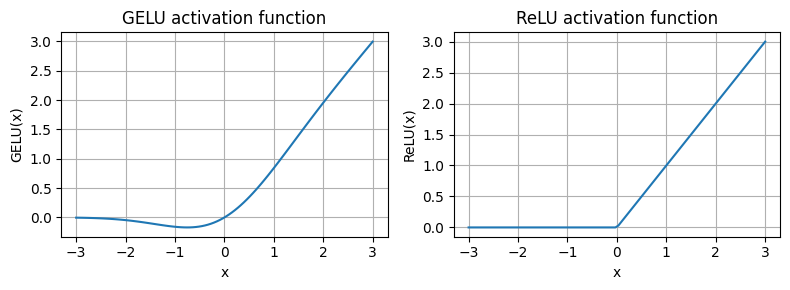

In [103]:
gelu, relu = GELU(), nn.ReLU()

# Çizim için örnek noktalar
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">

ReLU'nun sıfırda **keskin köşesi** var, negatif tarafı düz. GELU aynı yerde yumuşak kıvrılır ve negatifte tam kesmez — dip nokta `x ≈ -0.75`, değeri `-0.17`.

</div>

#### `FeedForward`: genişlet, kapıdan geçir, daralt

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Bloğun düşünme odası: `nn.Sequential` üç öğeyi sırayla çalıştırır — `nn.Linear` → `GELU` → `nn.Linear`.

Neden araya geniş bir oda giriyor: 768 sayı önce 3 072 ayrı nörona dağıtılır, her biri kapıdan tek tek geçer, sonuç yeniden 768'e toplanır. Kapının büktüğü yön sayısı artınca ayırt edilebilen örüntü de artıyor. Genişleme oranı 4 kodda sabit, şekil zinciri `(b, T, 768) → (b, T, 3072) → (b, T, 768)`. Çıkışın yine 768 olması zorunlu: blok zincirine ancak öyle takılır.

</div>

In [104]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),   # (…, 768) -> (…, 3072) genişletme
            GELU(),                                          # şekil aynı, değerler bükülür
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),   # (…, 3072) -> (…, 768) daraltma
        )

    def forward(self, x):
        # giriş ve çıkış boyu aynı, arada dört kat geniş bir ara katman var:
        # (b, T, 768) -> (b, T, 3072) -> (b, T, 768). Doğrusal olmayan geçiş bu geniş ara
        # katmanda yapılır; blok zincirine takılabilmesi için çıkış yine 768 olmak zorunda.
        return self.layers(x)

<div class="alert alert-block alert-success">

Katmanı deneyelim. Attention token'ları birbirine karıştırırken feed forward her token'ı **tek başına** işler; ilk iki eksen hesaba hiç girmiyor.

</div>

In [105]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)   # (2, 3, 768): 2 cümle × 3 token × 768 boyut
out = ffn(x)                # (2, 3, 768) -> (2, 3, 3072) -> (2, 3, 768)
print(out.shape)

torch.Size([2, 3, 768])


<div class="alert alert-block alert-success">

Odanın faturası: `layers.0` genişletme, `layers.2` daraltma katmanı (`layers.1` GELU, parametresi yok).

</div>

In [106]:
def fmt(n):
    return f"{n:,}".replace(",", " ")

for name, p in ffn.named_parameters():
    print(f"{name:16s} {str(tuple(p.shape)):16s} {fmt(p.numel()):>10s}")

print("-" * 46)
print(f"{'toplam':16s} {'':16s} {fmt(sum(p.numel() for p in ffn.parameters())):>10s}")

layers.0.weight  (3072, 768)       2 359 296
layers.0.bias    (3072,)               3 072
layers.2.weight  (768, 3072)       2 359 296
layers.2.bias    (768,)                  768
----------------------------------------------
toplam                             4 722 432


<div class="alert alert-block alert-info">

Dört satırın tamamı yapılandırma sözlüğünden çıkıyor — `emb_dim` 768, genişleme oranı 4, yani 3 072:

| kalem | hesap | sayı |
| --- | --- | --- |
| genişletme ağırlığı | 768 × 3 072 | 2 359 296 |
| genişletme sapması | 3 072 nöron × 1 | 3 072 |
| daraltma ağırlığı | 3 072 × 768 | 2 359 296 |
| daraltma sapması | 768 nöron × 1 | 768 |
| **toplam** | 2 362 368 + 2 360 064 | **4 722 432** |

Sapma sayısı her zaman **çıkış** nöronu sayısı kadardır: nöron başına bir tane. Bu 4 722 432, bir transformer bloğunun en pahalı parçası olacak.

</div>

<hr id="konu-07-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Layer Normalization: Ortalamayı Çıkar, Yayılıma Böl

Aynı katmandan çıkan iki token bambaşka ölçeklerde olabilir; 12 kat üst üste binince bu fark büyür. Layer normalization her token'ı kendi içinde hizalar. Tahtadaki iki satırlık örneği burada elle ve sınıfla yan yana koyuyoruz.

#### İki satır, iki ayrı ölçek

<div class="alert alert-block alert-success">

Tahtadaki örnek: altışar sayılık iki satır, biri 2–5 biri 15–25 aralığında. Sayılar ortalama ve varyans tam sayı çıksın diye seçildi.

Hesap son eksen boyunca, yani satır satır. `unbiased=False` böleni $n$ yapar ($n-1$ değil) — `LayerNorm` sınıfı da böyle hesaplar.

</div>

In [107]:
# Tahtadaki iki satır: aynı katmandan çıkmış iki token — ama iki AYRI ölçekte.
sample = torch.tensor([[ 2.0,  4.0,  4.0,  4.0,  5.0,  5.0],     # 2 ile 5 arasında
                       [15.0, 19.0, 19.0, 21.0, 21.0, 25.0]])    # 15 ile 25 arasında

mean = sample.mean(dim=-1, keepdim=True)                 # (2, 6) -> (2, 1): satır satır ortalama
var = sample.var(dim=-1, keepdim=True, unbiased=False)   # unbiased=False -> bölen n (n-1 değil)
print("ortalama :", mean.flatten().tolist())             # tahtada elle: 4.0 ve 20.0
print("varyans  :", var.flatten().tolist())              # tahtada elle: 1.0 ve 9.0

centered = sample - mean            # 1. hamle: ortalamayı çıkar -> ortalama 0 olur
aligned = centered / var.sqrt()     # 2. hamle: yayılıma böl    -> yayılım 1 olur
print("\nortalanmış:\n", centered)
print("\nhizalanmış:\n", aligned)

ortalama : [4.0, 20.0]
varyans  : [1.0, 9.0]

ortalanmış:
 tensor([[-2.,  0.,  0.,  0.,  1.,  1.],
        [-5., -1., -1.,  1.,  1.,  5.]])

hizalanmış:
 tensor([[-2.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000],
        [-1.6667, -0.3333, -0.3333,  0.3333,  0.3333,  1.6667]])


<div class="alert alert-block alert-info">

Tahtayla karşılaştır: ortalamalar **4.0** ve **20.0**, varyanslar **1.0** ve **9.0**. Hizalanmış tabloda birinci satır `-2, 0, 0, 0, 1, 1`, ikincisi `-1.667 … 1.667` — iki satır artık aynı ölçekte.

</div>

#### `LayerNorm` sınıfı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Yukarıdaki iki hamlenin sınıf hâli, sonuna iki öğrenilebilir düğme eklenmiş:

$$y \;=\; \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} \;+\; \beta$$

Kodda $\gamma$ = `scale`, $\beta$ = `shift`, $\varepsilon$ = `eps`. `eps` paydaya eklenir ki varyans sıfıra çok yakınken bölme taşmasın.

`nn.Parameter` sarmalı kritik: düz bir tensör `parameters()` listesine girmez, optimizatör onu görmez. `scale` birlerle, `shift` sıfırlarla başladığı için ilk anda formül $\gamma=1,\ \beta=0$ ile sade hizalamaya iner — sınıf hizalamayı bozmaz; eğitim isterse ölçeği geri açar.

</div>

In [108]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # şekil hiç değişmez: (…, emb_dim) girer, (…, emb_dim) çıkar. Hesap SON eksende,
        # yani her token kendi vektörü içinde hizalanır — komşu token'lara bakılmaz.
        mean = x.mean(dim=-1, keepdim=True)                  # (…, emb_dim) -> (…, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)    # (…, emb_dim) -> (…, 1)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)     # (…, 1) yayınlanır -> (…, emb_dim)
        return self.scale * norm_x + self.shift              # scale/shift: (emb_dim,) yayınlanır

<div class="alert alert-block alert-success">

Sınıfı **aynı iki satıra** uyguluyoruz. Elle yaptığımız hesabın farkı tek yerde: sınıf paydaya `eps` ekliyor.

</div>

In [109]:
ln = LayerNorm(emb_dim=6)
out = ln(sample)           # (2, 6) -> (2, 6): şekil aynı, iki satır artık ortak ölçekte
print(out)

print("\nortalama :", [round(v, 6) for v in out.mean(dim=-1).tolist()])
print("varyans  :", [round(v, 6) for v in out.var(dim=-1, unbiased=False).tolist()])
print("\nelle hesapla en büyük fark:", (out - aligned).abs().max().item())

tensor([[-2.0000,  0.0000,  0.0000,  0.0000,  1.0000,  1.0000],
        [-1.6667, -0.3333, -0.3333,  0.3333,  0.3333,  1.6667]],
       grad_fn=<AddBackward0>)

ortalama : [0.0, 0.0]
varyans  : [0.99999, 0.999999]

elle hesapla en büyük fark: 1.0013580322265625e-05


<div class="alert alert-block alert-info">

Ortalamalar sıfıra, varyanslar bire iniyor. Son satır elle hesapla sınıf arasındaki **en büyük farkı** basıyor: `1e-05` mertebesinde, yani yalnız `eps`in izi — `-2.0` beklerken `-1.99999` çıkmasının sebebi bu.

</div>

#### İki ispat: hizalama neyi siler, neyi korur?

<div class="alert alert-block alert-success">

**Birincisi:** hizalama ölçekten ve kaymadan bağımsızdır — satırı on katına çıkarıp yüz eklesek hizalanmış hâli değişmemeli.

**İkincisi:** `scale` ile `shift` her ölçeği geri kurabilir — `γ = 3`, `β = 20` uygulanınca ortalama 20, varyans 9 çıkmalı.

</div>

In [110]:
# İSPAT 1 · hizalama ÖLÇEKTEN ve KAYMADAN bağımsızdır.
# Aynı satırın on katını ve yüz fazlasını hizalayalım: üçü de AYNI sonucu vermeli.
row = sample[1]                         # 15, 19, 19, 21, 21, 25
trials = [("özgün", row), ("on katı", row * 10), ("yüz fazlası", row + 100)]
for name, trial in trials:
    m = trial.mean()
    v = trial.var(unbiased=False)       # bölen n
    scaled = (trial - m) / v.sqrt()     # iki hamle: çıkar, böl
    print(f"{name:<12} ortalama {m.item():7.1f}   varyans {v.item():8.1f}")
    print(f"{'':<12} hizalanmış -> {[round(t, 4) for t in scaled.tolist()]}")

# İSPAT 2 · scale ve shift her ölçeği GERİ KURABİLİR.
# 1. satırın hizalanmış hâli ortalama 0, yayılım 1; γ ve β ile başka bir ölçek kuralım.
aligned_1 = aligned[0]                  # yukarıda hizaladığımız 1. satır
restored = 3.0 * aligned_1 + 20.0       # γ = 3 (yayılım), β = 20 (ortalama)
print(f"\nγ=3, β=20 uygulanınca : {[round(t, 1) for t in restored.tolist()]}")
print(f"yeni ortalama {restored.mean().item():.4f}   "
      f"yeni varyans {restored.var(unbiased=False).item():.4f}")
print("-> dersin 2. satırının istatistiğinin aynısı: ortalama 20, varyans 9")

özgün        ortalama    20.0   varyans      9.0
             hizalanmış -> [-1.6667, -0.3333, -0.3333, 0.3333, 0.3333, 1.6667]
on katı      ortalama   200.0   varyans    900.0
             hizalanmış -> [-1.6667, -0.3333, -0.3333, 0.3333, 0.3333, 1.6667]
yüz fazlası  ortalama   120.0   varyans      9.0
             hizalanmış -> [-1.6667, -0.3333, -0.3333, 0.3333, 0.3333, 1.6667]

γ=3, β=20 uygulanınca : [14.0, 20.0, 20.0, 20.0, 23.0, 23.0]
yeni ortalama 20.0000   yeni varyans 9.0000
-> dersin 2. satırının istatistiğinin aynısı: ortalama 20, varyans 9


<div class="alert alert-block alert-danger">

Birinci ispatta ortalamalar **20 · 200 · 120**, varyanslar **9 · 900 · 9** — hepsi farklı, ama hizalanmış satırlar **birebir aynı**.

İkinci ispatta çıkan satır `[14.0, 20.0, 20.0, 20.0, 23.0, 23.0]`, ortalaması 20 ve varyansı 9. Katman hizalamayı istediği an geri alabiliyor — hizalama bir kısıt değil, başlangıç noktası.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-08" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 08 · Gradyan, Zincir Kuralı ve Shortcut Connection

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-07">←</a> <a href="vscode-notebook-cell:?execution_count=98&line=1">Ders 07</a>  ·  <a href="vscode-notebook-cell:?execution_count=122&line=1">Ders 09</a> <a href="#ders-09">→</a></sub>

In [111]:
lesson(8, "Gradyan, Zincir Kuralı ve Shortcut Connection")

Ders 08 · Gradyan, Zincir Kuralı ve Shortcut Connection   ·   0.2 dk


**Problem:** ağı kurduk ama içindeki bütün sayılar rastgele. Doğru değerlere kim karar veriyor?

Zincir üç halka: **loss (kayıp)** hatayı tek sayıya indirir, **türev** hangi düğmenin ne kadar sorumlu olduğunu söyler, **zincir kuralı** bunu katmanlar boyunca geriye taşır. Sonra sorun çıkar: 1'den küçük çarpanlar on iki katman sonra gradyanı sıfırlar. **Shortcut connection** girdiyi çıktıya ekleyip zincire kısa yol açar; ölçerek göreceğiz.

<hr id="konu-08-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Türev, Zincir Kuralı ve Geri Yayılım

Tahtadaki ağı burada kodda kuruyoruz ve öğrenmenin bütün adımlarını oyuncak veriyle tek tek yapıyoruz: önce türevin ne olduğunu GRAFİKLE görüyoruz, sonra aynı sayıyı deneyerek buluyoruz, zincir kuralıyla dört düğmenin dördü için birden çıkarıyoruz, `backward()` ile karşılaştırıyoruz ve döngüyü altı tur çeviriyoruz.

#### Adım 0a · Çıpa: hız zaten bir türevdir

<div class="alert alert-block alert-success">

Türev soyut bir şey değil. Hızlanan bir araç: katedilen yol `10 · t²` km, iki saatin sonunda 40 km.

**Ortalama hız İKİ noktadan çıkar:** 2. ile 3. saat arası `(90 - 40) / 1 = 50` km/saat. Aracın 2. saatte TAM O ANDA ne kadar hızlı gittiğini bilmek için aralığı daraltmak gerekir — türev budur: bir noktadaki anlık değişim hızı.

Cevabı önceden biliyoruz, çünkü tek kural yetiyor — **kare kuralı**: $u^2$'nin türevi $2u$'dur, sabit çarpan olduğu gibi durur.

$$s(t) = 10\,t^2 \;\Rightarrow\; \frac{ds}{dt} = 20\,t \;\Rightarrow\; t=2 \text{ için } 40$$

Hücre bunu **ispat etmiyor**, sağlamasını alıyor: aralığı daraltınca ortalama hızın 40'a yaklaşıp yaklaşmadığına bakıyor.

</div>

In [112]:
# ÇIPA · hız zaten bir türevdir: yol–zaman grafiğinin eğimi hızı verir.
# Hızlanan bir araç: katedilen yol  distance(t) = 10 · t²   (km, t saat cinsinden)


def distance(t):
    return 10 * t ** 2


t0 = 2.0
print(f"2. saatin sonunda katedilen yol: {distance(t0):.1f} km")
print("\naralığı daraltalım — ORTALAMA hız neye yakınsıyor?")
for h in [1.0, 0.5, 0.1, 0.01]:
    avg_speed = (distance(t0 + h) - distance(t0)) / h
    print(f"  {t0} -> {t0 + h:<5} saat :  "
          f"({distance(t0 + h):7.3f} - {distance(t0):.1f}) / {h:<5} = {avg_speed:6.2f} km/saat")
print("\ntürev: 20 · t = 40.00 km/saat  <-  hız göstergesinin 2. saatte gösterdiği ANLIK sayı")
print("ortalama hız İKİ noktadan çıkar (kesen), anlık hız TEK noktadan (teğet).")

2. saatin sonunda katedilen yol: 40.0 km

aralığı daraltalım — ORTALAMA hız neye yakınsıyor?
  2.0 -> 3.0   saat :  ( 90.000 - 40.0) / 1.0   =  50.00 km/saat
  2.0 -> 2.5   saat :  ( 62.500 - 40.0) / 0.5   =  45.00 km/saat
  2.0 -> 2.1   saat :  ( 44.100 - 40.0) / 0.1   =  41.00 km/saat
  2.0 -> 2.01  saat :  ( 40.401 - 40.0) / 0.01  =  40.10 km/saat

türev: 20 · t = 40.00 km/saat  <-  hız göstergesinin 2. saatte gösterdiği ANLIK sayı
ortalama hız İKİ noktadan çıkar (kesen), anlık hız TEK noktadan (teğet).


<div class="alert alert-block alert-info">

Son sütun: **50.00 → 45.00 → 41.00 → 40.10**. Aralık kapandıkça ortalama hız anlık hıza yakınsıyor.

Kaybın türevi de bu — tek fark eksenlerin adı: zaman yerine **düğmenin değeri**, yol yerine **kayıp**.

</div>

#### Adım 0b · Aynı fikir, kaybın grafiğinde

<div class="alert alert-block alert-success">

Eksenlerin adı değişiyor, kural aynı kalıyor. Kaybı **yalnız `w2`'nin fonksiyonu** olarak yazıyoruz; öteki üç düğme sabit, kapıdan çıkan sayı `a = 2.0` olduğu için elde `L(w2) = (2·w2 + 1 - 8)² = (2·w2 - 7)²` kalıyor. Dibi `w2 = 3.5`'te; biz `(2, 9)` noktasındayız.

Yine kare kuralı, bu kez içi de `w2`'ye bağlı olduğu için **iç türevle** çarpılıyor — parantezin içi `2·w2 - 7`, onun `w2` türevi 2:

$$\frac{dL}{dw_2} = 2\,(2w_2 - 7)\cdot 2 = 4\,(2w_2 - 7) \;\Rightarrow\; w_2 = 2 \text{ için } 4\cdot(-3) = -12$$

Grafik bu −12'yi gözle gösteriyor: üç **kesen doğru**nun eğimi sırayla −8, −10, −11.6. `h` küçüldükçe kesen dönüp tek bir doğruya oturuyor: **teğet**, eğimi −12. Türev o teğetin eğimidir.

</div>

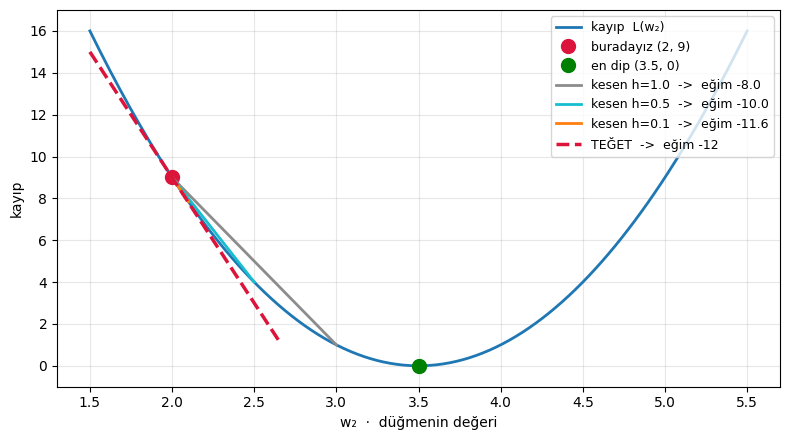

In [113]:
# Aynı fikir, bu kez kaybın üstünde. Ders 8'in ağı:
# girdi 2 -> [w1 1.5, b1 -1.0] -> ReLU -> [w2 2.0, b2 1.0] -> tahmin.
# Kaybı YALNIZ w2'nin fonksiyonu olarak yazalım; öteki üç düğme sabit kalsın.
# a = ReLU(1.5 × 2 - 1.0) = 2.0 olduğu için  loss(w2) = (2·w2 - 7)²
target = 8.0
a_fixed, b2_fixed = 2.0, 1.0


def loss_of(w2):
    return (w2 * a_fixed + b2_fixed - target) ** 2


grid = np.linspace(1.5, 5.5, 200)
plt.figure(figsize=(8, 4.5))
plt.plot(grid, loss_of(grid), linewidth=2, label="kayıp  L(w₂)")
plt.plot(2.0, loss_of(2.0), "o", color="crimson", markersize=10, label="buradayız (2, 9)")
plt.plot(3.5, loss_of(3.5), "o", color="green", markersize=10, label="en dip (3.5, 0)")

# Üç kesen doğru: iki nokta birbirine yaklaştıkça eğim teğete oturuyor.
for h, color in [(1.0, "0.55"), (0.5, "tab:cyan"), (0.1, "tab:orange")]:
    slope = (loss_of(2.0 + h) - loss_of(2.0)) / h
    plt.plot([2.0, 2.0 + h], [loss_of(2.0), loss_of(2.0 + h)], color=color, linewidth=2,
             label=f"kesen h={h}  ->  eğim {slope:.1f}")

# Teğet: L = 9 - 12(w2 - 2). Kesikli çizildi ki altındaki kesen görünsün.
plt.plot([1.5, 2.65], [loss_of(2.0) - 12 * (1.5 - 2.0), loss_of(2.0) - 12 * (2.65 - 2.0)],
         "--", color="crimson", linewidth=2.5, label="TEĞET  ->  eğim -12")

plt.xlabel("w₂  ·  düğmenin değeri")
plt.ylabel("kayıp")
plt.ylim(-1, 17)
plt.legend(fontsize=9, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">

Grafikte üç şeye bak: **kırmızı nokta** durduğumuz yer (kayıp 9), **yeşil nokta** varmak istediğimiz dip (kayıp 0), ve üç kesenin kesikli teğete yaklaşması.

Eğimin **eksi** olması "sağa git" demek; büyüklüğü (12) yokuşun dikliği. Tek sayıdan iki karar çıkıyor: yön ve aciliyet.

</div>

#### Adım 1 · Türevi deneyerek bul

<div class="alert alert-block alert-success">

Ağ üç satır: ham toplam, kapı, ikinci katman — `max(0.0, z)` ReLU'nun ta kendisidir.

Türevin tanımı zaten bir deney: **düğmeyi çok az oynat, kayıp ne kadar değişti, orana bak.** Bu hücre hiçbir kural kullanmıyor; sembolik cevabı (−12) yukarıda bulmuştuk, burada aynı sayıya bölme ve çıkarmayla varıyoruz. İki bağımsız yolun aynı yere çıkması kuralın sağlamasıdır.

</div>

In [114]:
# Ders 7'nin işi, en küçük hâliyle: tek ölçü (çalışma saati) -> sınav puanı.
# girdi 2 -> [w1 1.5, b1 -1.0] -> ReLU -> [w2 2.0, b2 1.0] -> tahmin, gerçek puan 8.
# Sayılar elle seçildi: birazdan bütün türevler TAM SAYI çıkacak.
x, target = 2.0, 8.0
w1, b1, w2, b2 = 1.5, -1.0, 2.0, 1.0


def forward(w1, b1, w2, b2):
    z = w1 * x + b1            # ham toplam: birinci katman
    a = max(0.0, z)            # ReLU kapısı
    return z, a, w2 * a + b2   # ikinci katman -> tahmin


z, a, pred = forward(w1, b1, w2, b2)
loss = (pred - target) ** 2
print(f"ileri geçiş:  z = {z}   a = {a}   tahmin = {pred}   kayıp = {loss}")

# TÜREVİ DENEYEREK BUL: w2'yi h kadar oynat, kayıptaki değişim oranına bak.
print("\nw2 = 2.0 düğmesini h kadar oynatalım:")
for h in [0.1, 0.01, 0.001, 0.0001]:
    _, _, pred_new = forward(w1, b1, w2 + h, b2)
    loss_new = (pred_new - target) ** 2
    ratio = (loss_new - loss) / h
    print(f"  h = {h:<8}  kayıp {loss} -> {loss_new:8.4f}   oran = {ratio:9.4f}")
print("\nh küçüldükçe oran tek bir sayıya yakınsıyor:  dL/dw2 = -12")

ileri geçiş:  z = 2.0   a = 2.0   tahmin = 5.0   kayıp = 9.0

w2 = 2.0 düğmesini h kadar oynatalım:
  h = 0.1       kayıp 9.0 ->   7.8400   oran =  -11.6000
  h = 0.01      kayıp 9.0 ->   8.8804   oran =  -11.9600
  h = 0.001     kayıp 9.0 ->   8.9880   oran =  -11.9960
  h = 0.0001    kayıp 9.0 ->   8.9988   oran =  -11.9996

h küçüldükçe oran tek bir sayıya yakınsıyor:  dL/dw2 = -12


<div class="alert alert-block alert-info">

İlk satır ileri geçiş: `z = 2.0`, `a = 2.0`, `tahmin = 5.0`, `kayıp = 9.0` — tahtadaki dairelerin içindeki sayılar.

Alttaki oran **−11.6 → −11.96 → −11.996 → −11.9996** diye ilerliyor: `h` sıfıra yaklaştıkça cevap **−12**'ye yakınsıyor.

</div>

#### Adım 2 · Zincir kuralı: dört türev birden

<div class="alert alert-block alert-success">

Deneyerek bulmak tek düğme için bile dört hesap gerektirdi; 124 milyon düğme için imkânsız. Zincir kuralı hepsini birden verir: **birleşik bir hesabın türevi, halkaların türevlerinin çarpımıdır.**

Sayı koymadan önce her halkanın türevini sembolle alıyoruz. Kural sütununa bak — hücrenin yaptığı iş bundan başkası değil:

| halka | hesap | türevi | hangi kural |
| --- | --- | --- | --- |
| kayıp | $L = (\hat{y} - y)^2$ | $dL/d\hat{y} = 2(\hat{y} - y)$ | kare kuralı: $u^2 \to 2u$ |
| 2. katman | $\hat{y} = w_2 a + b_2$ | $\partial/\partial w_2 = a$, $\partial/\partial b_2 = 1$, $\partial/\partial a = w_2$ | çarpımın türevi **öteki** çarpandır |
| kapı | $a = \mathrm{ReLU}(z)$ | $da/dz = 1$ ($z>0$), aksi hâlde $0$ | parçalı tanım |
| 1. katman | $z = w_1 x + b_1$ | $\partial/\partial w_1 = x$, $\partial/\partial b_1 = 1$ | çarpımın türevi **öteki** çarpandır |

Sayılar ancak şimdi giriyor: $\hat{y}=5$, $y=8$, $a=2$, $w_2=2$, $x=2$ ve $z=2>0$. Kodda `1.0 if z > 0 else 0.0` yazan yer üçüncü satırın ta kendisi: kapı açıksa sinyal aynen geçer, kapalıysa zincire **sıfır** girer — ölü nöron tam olarak budur.

</div>

In [115]:
# Aynı sayıyı ZİNCİR KURALIYLA bulalım — üstelik dört düğmenin dördü için birden.
# Kural: birleşik bir hesabın türevi, halkaların türevlerinin ÇARPIMIDIR.

dL_dpred = 2 * (pred - target)                  # kayıp farkın karesi -> türevi farkın iki katı
dL_dw2 = dL_dpred * a                           # tahmin = w2 * a + b2  ->  w2'ye göre türev: a
dL_db2 = dL_dpred * 1.0                         #                           b2'ye göre türev: 1
dL_da = dL_dpred * w2                           #                           a'ya göre türev: w2
dL_dz = dL_da * (1.0 if z > 0 else 0.0)         # ReLU türevi: z pozitifse 1, değilse 0
dL_dw1 = dL_dz * x                              # z = w1 * x + b1  ->  w1'e göre türev: x
dL_db1 = dL_dz * 1.0                            #                      b1'e göre türev: 1

print("GERİ GEÇİŞ — kayıptan başlayıp halka halka geriye:")
print(f"  dL/dtahmin = 2 × ({pred} - {target}) = {dL_dpred}")
print(f"  dL/dw2     = {dL_dpred} × {a} = {dL_dw2}")
print(f"  dL/db2     = {dL_dpred} × 1 = {dL_db2}")
print(f"  dL/da      = {dL_dpred} × {w2} = {dL_da}")
print(f"  dL/dz      = {dL_da} × 1 = {dL_dz}   (ReLU türevi 1, çünkü z pozitif)")
print(f"  dL/dw1     = {dL_dz} × {x} = {dL_dw1}")
print(f"  dL/db1     = {dL_dz} × 1 = {dL_db1}")
print(f"\nzincir tek satırda: dL/dw1 = {dL_dpred} × {w2} × 1 × {x} = {dL_dw1}")

GERİ GEÇİŞ — kayıptan başlayıp halka halka geriye:
  dL/dtahmin = 2 × (5.0 - 8.0) = -6.0
  dL/dw2     = -6.0 × 2.0 = -12.0
  dL/db2     = -6.0 × 1 = -6.0
  dL/da      = -6.0 × 2.0 = -12.0
  dL/dz      = -12.0 × 1 = -12.0   (ReLU türevi 1, çünkü z pozitif)
  dL/dw1     = -12.0 × 2.0 = -24.0
  dL/db1     = -12.0 × 1 = -12.0

zincir tek satırda: dL/dw1 = -6.0 × 2.0 × 1 × 2.0 = -24.0


<div class="alert alert-block alert-info">

Dört düğmenin türevi: `dL/dw₁ = -24`, `dL/db₁ = -12`, `dL/dw₂ = -12`, `dL/db₂ = -6`.

`dL/dw₂` satırındaki **−12**, bir önceki hücrede dört kez hesap yaparak bulduğumuz sayının aynısı — iki bağımsız yol aynı yere çıktı.

</div>

#### Adım 3 · `backward()` aynı işi yapıyor

<div class="alert alert-block alert-success">

`requires_grad=True` yazdığın an PyTorch o tensörle yapılan **her işlemi kaydeder**; `backward()` kaydı geriye sarıp türevleri `.grad` alanına yazar. Buna **autograd** (otomatik türev) denir.

</div>

In [116]:
# PyTorch aynı zinciri kendisi yürütür. `requires_grad=True` yazdığın an o tensörle
# yapılan her işlem kaydedilir; `backward()` kaydı geriye sarıp türevleri `.grad`e yazar.
tw1, tb1, tw2, tb2 = (torch.tensor(v, requires_grad=True) for v in (w1, b1, w2, b2))

t_pred = tw2 * torch.relu(tw1 * x + tb1) + tb2     # İLERİ GEÇİŞ — kayıt burada tutuluyor
t_loss = (t_pred - target) ** 2                    # KAYIP
t_loss.backward()                                  # GERİ GEÇİŞ — zinciri geriye sar

print(f"{'düğme':<8}{'elle':>12}{'autograd':>12}")
print("-" * 32)
for name, manual, tensor in [("w1", dL_dw1, tw1), ("b1", dL_db1, tb1),
                             ("w2", dL_dw2, tw2), ("b2", dL_db2, tb2)]:
    print(f"{name:<8}{manual:>12.1f}{tensor.grad.item():>12.1f}")
print("\nİki sütun birebir aynı: backward() yukarıdaki yedi satırı yapıyor, başka bir şey değil.")

düğme           elle    autograd
--------------------------------
w1             -24.0       -24.0
b1             -12.0       -12.0
w2             -12.0       -12.0
b2              -6.0        -6.0

İki sütun birebir aynı: backward() yukarıdaki yedi satırı yapıyor, başka bir şey değil.


<div class="alert alert-block alert-info">

İki sütun birebir aynı: `backward()` sihir değil, bir önceki hücrede elle yazdığımız yedi satırın otomatiği. Ders 10'da aynısı 124 milyon düğme için olacak.

</div>

#### Adım 4 · Döngü: aynı dört hareket, altı kez

<div class="alert alert-block alert-success">

Döngünün gövdesi dört bölüm ve **sırası değişmez**: ileri geçiş → kayıp → geri geçiş → güncelle. Güncelleme satırı `w1 -= lr * gw1`: türevin **tersi** yönde, `lr` kadar — türev negatifse düğme artar.

Burada düz Python sayılarıyla çalıştığımız için gradyan sıfırlama gerekmiyor.

</div>

In [117]:
# Bir adım yetmedi. Aynı DÖRT HAREKETİ altı kez tekrarlayalım:
# ileri geçiş -> kayıp -> geri geçiş -> güncelle.
w1, b1, w2, b2 = 1.5, -1.0, 2.0, 1.0     # baştan başla
lr = 0.01                                 # öğrenme oranı: adımın uzunluğu

print(f"{'tur':>3}{'w1':>8}{'b1':>8}{'w2':>8}{'b2':>8}{'tahmin':>9}{'kayıp':>9}"
      f"{'dL/dw1':>10}{'dL/db1':>9}{'dL/dw2':>9}{'dL/db2':>9}")
print("-" * 90)
for step in range(1, 7):
    z = w1 * x + b1                       # 1) İLERİ GEÇİŞ
    a = max(0.0, z)
    pred = w2 * a + b2
    loss = (pred - target) ** 2           # 2) KAYIP

    g = 2 * (pred - target)               # 3) GERİ GEÇİŞ — zincir kuralı, yukarıdakinin aynısı
    gw2, gb2 = g * a, g
    gz = g * w2 * (1.0 if z > 0 else 0.0)
    gw1, gb1 = gz * x, gz

    print(f"{step:>3}{w1:>8.3f}{b1:>8.3f}{w2:>8.3f}{b2:>8.3f}{pred:>9.3f}{loss:>9.4f}"
          f"{gw1:>10.3f}{gb1:>9.3f}{gw2:>9.3f}{gb2:>9.3f}")

    w1 -= lr * gw1                        # 4) GÜNCELLE — her düğme türevin TERSİ yönde
    b1 -= lr * gb1
    w2 -= lr * gw2
    b2 -= lr * gb2

print(f"\naltı tur sonunda tahmin {pred:.4f}, hedef {target} — kayıp {loss:.4f}")
print("sağlama: 1. satırın w1 ve dL/dw1 sütunları -> 1.5 - 0.01 × (-24) = 1.74 -> 2. satırın w1")

tur      w1      b1      w2      b2   tahmin    kayıp    dL/dw1   dL/db1   dL/dw2   dL/db2
------------------------------------------------------------------------------------------
  1   1.500  -1.000   2.000   1.000    5.000   9.0000   -24.000  -12.000  -12.000   -6.000
  2   1.740  -0.880   2.120   1.060    6.572   2.0392   -12.109   -6.055   -7.426   -2.856
  3   1.861  -0.819   2.194   1.089    7.458   0.2939    -4.758   -2.379   -3.147   -1.084
  4   1.909  -0.796   2.226   1.099    7.825   0.0307    -1.559   -0.780   -1.059   -0.350
  5   1.924  -0.788   2.236   1.103    7.948   0.0028    -0.469   -0.235   -0.321   -0.105
  6   1.929  -0.786   2.240   1.104    7.985   0.0002    -0.137   -0.069   -0.094   -0.031

altı tur sonunda tahmin 7.9847, hedef 8.0 — kayıp 0.0002
sağlama: 1. satırın w1 ve dL/dw1 sütunları -> 1.5 - 0.01 × (-24) = 1.74 -> 2. satırın w1


<div class="alert alert-block alert-danger">

Kayıp kolonu: **9.0 → 2.04 → 0.29 → 0.03 → 0.003 → 0.0002** — her turda yaklaşık onda birine iniyor.

Tahmin kolonu hedefe yürüyor: **5.0 → 6.572 → 7.4579 → 7.8248 → 7.9475 → 7.9847**. Hiçbir düğme sıçramıyor; tahtadaki iterasyon tablosuyla satır satır aynı.

</div>

<hr id="konu-08-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Kaybolan Gradyan ve Shortcut Connection

Zincir kuralı türevleri birbiriyle çarpar. 1'den küçük sayılar çarpıla çarpıla sıfıra iner: `0.5` beş kez çarpılınca `0.03` olur, on iki kez çarpılınca `0.0002`. Girişe en yakın katmana kalan sinyal budur — **Vanishing Gradient (kaybolan gradyan)**. Çare **Shortcut Connection (kısayol bağlantısı)**: girdiyi katmanın çıktısına eklemek. Burada beş katmanlı bir deney ağı kurup gradyanları katman katman ölçüyoruz, sonra tek bir bayrağı çevirip aynı ölçümü tekrarlıyoruz.

#### Beş katmanlı bir deney ağı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Bu sınıf mimarinin parçası değil, bir **ölçüm aracı**: kısayolun etkisini A/B ölçmenin tek yolu aynı ağı iki kez koşturmak. Her katman `Linear + GELU`.

Bütün ders `forward` içindeki tek `if` dalında: `use_shortcut` açıkken `x = x + layer_output`, kapalıyken `x = layer_output`. Yani kısayol katmanın yerine geçmiyor, **yanına** bir toplama ekliyor.

</div>

In [118]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Bu katmanın çıktısı
            layer_output = layer(x)
            # Kısayol yalnız ŞEKİL KORUNUYORSA uygulanabilir. Boyutlar
            # [3, 3, 3, 3, 3, 1]: ilk dört katman (1, 3) -> (1, 3), kısayol açık;
            # son katman (1, 3) -> (1, 1), şekil değiştiği için else dalına düşer.
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

<div class="alert alert-block alert-success">

Katman boyutları `[3, 3, 3, 3, 3, 1]`; araya giren dört katman aynı şekilde, yani kısayol uygulanabilir. Önce kısayolsuz model.

</div>

In [119]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)   # aynı başlangıç ağırlıkları için tohum
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

#### Gradyanları yazdıran fonksiyon

<div class="alert alert-block alert-success">

Önceki konuda elle yürüttüğümüz üç adımın aynısı: ileri geçiş → `nn.MSELoss()` → `backward()`. Sonra yalnız ağırlık matrisleri seçilip `param.grad.abs().mean()` basılıyor — önce işaret atılır, sonra ortalama alınır.

Son satır fonksiyonu kısayolu **olmayan** modelle çağırıyor. Çıktıdaki katman adları sıralıdır: ilk satır girişe, son satır çıkışa en yakın katman.

</div>

In [120]:
def print_gradients(model, x):
    # İleri geçiş
    output = model(x)
    target = torch.tensor([[0.]])

    # Çıktı ile hedefin ne kadar uzak olduğunu ölç
    loss = nn.MSELoss()(output, target)

    # Geri geçiş: gradyanları hesapla
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Ağırlığın gradyanının ortalama mutlak değeri
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


<div class="alert alert-block alert-danger">

Beş satır: `layers.0` girdiye en yakın, `layers.4` kayba en yakın katman. İki uç arasında **25 kat** fark var — kayba yakın katman öğrenirken ilk katman neredeyse hiç sinyal almıyor.

</div>

#### Aynı model, kısayol açık

<div class="alert alert-block alert-success">

Tek fark `use_shortcut=True`. `torch.manual_seed(123)` yeniden çağrıldığı için başlangıç ağırlıkları da birebir aynı: iki ölçüm arasındaki tek değişken bayrağın kendisi.

</div>

In [121]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


<div class="alert alert-block alert-info">

`layers.0` satırlarını karşılaştır: `0.0002` → `0.2217`, ilk katmanın gradyanı **yaklaşık 1 100 kat** büyüdü. Beş satır artık aynı mertebede.

Sebep tek satırlık bir türev. Kısayolsuz katman $y = f(x)$, türevi $f'(x)$; kısayollu katman $y = x + f(x)$, türevi

$$\frac{dy}{dx} = 1 + f'(x)$$

çünkü toplamın türevi türevlerin toplamıdır ve $x$'in kendine göre türevi 1. $f'(x)$ sıfıra inse bile zincire giren çarpan 1'in altına düşmez — ders 9'da `x = x + shortcut` olarak iki kez geçecek.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-09" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 09 · Transformer Bloğu, GPT-2 ve İlk Metin

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-08">←</a> <a href="vscode-notebook-cell:?execution_count=111&line=1">Ders 08</a>  ·  <a href="vscode-notebook-cell:?execution_count=136&line=1">Ders 10</a> <a href="#ders-10">→</a></sub>

In [122]:
lesson(9, "Transformer Bloğu, GPT-2 ve İlk Metin")

Ders 09 · Transformer Bloğu, GPT-2 ve İlk Metin   ·   0.2 dk


Parçalar hazır: attention, layer norm, feed forward, shortcut. Bu ders hepsini **transformer bloğunda** birleştirip bloğu on iki kez dizerek **GPT-2 küçük**'ü kuruyor.

Bloğun tek sözleşmesi girdisiyle aynı şekli döndürmek. Parametreleri kalem kalem sayıyoruz: **weight tying** 163 milyonu 124 milyona indiriyor. Ders modelin ilk — anlamsız ama uçtan uca çalışan — metniyle bitiyor.

<hr id="konu-09-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Transformer Bloğu: Parçalar Tek Gövdede

Bütün parçalar hazır: `MultiHeadAttention` (ders 6), `LayerNorm` ve `FeedForward` (ders 7), kısayol bağlantısı (ders 8). Bu konu onları tek sınıfta birleştiriyor: bloğun anatomisi tek `forward` içinde.

#### `forward`ın iki turu

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** `__init__` beş alt nesne kuruyor: `att`, `ff`, `norm1`, `norm2` ve kısayol yolundaki dropout. Gövdede ise aynı beş satırlık kalıp iki kez geçiyor — `shortcut = x`, hizala, alt katman, dropout, `x + shortcut`. İki turun `norm1`/`norm2` ve `att`/`ff` adları dışında hiçbir farkı yok; birinci tur token'ları birbirine karıştırır, ikincisi her token'ı tek başına işler.

Hizalamanın alt katmandan **önce** gelmesi bir tasarım kararıdır: kısayol yolu üzerinde hiçbir işlem kalmasın diye. Bloğun tek sözleşmesi şekil: `(b, T, 768) → (b, T, 768)`.

</div>

In [123]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # şekil izi: b = yığın · T = token sayısı · emb_dim = 768.
        # Blok şekli DEĞİŞTİRMEZ: (b, T, 768) girer, (b, T, 768) çıkar. On iki tanesinin
        # üst üste dizilebilmesi buna bağlı — çıkışı bir sonrakinin girişine oturuyor.

        # 1. tur: dikkat + kısayol
        shortcut = x                       # (b, T, 768) — girdiyi kenara koy
        x = self.norm1(x)                  # şekil aynı: her token kendi içinde hizalanır
        x = self.att(x)                    # (b, T, 768) -> (b, T, 768); içeride 12 başa bölünür
        x = self.drop_shortcut(x)
        x = x + shortcut                   # kenara koyduğumuz girdiyi geri ekle

        # 2. tur: ileri beslemeli ağ + kısayol — aynı kalıp, başka iki alt katmanla
        shortcut = x                       # (b, T, 768) — bu turun girdisi
        x = self.norm2(x)
        x = self.ff(x)                     # (b, T, 768) -> (b, T, 3072) -> (b, T, 768)
        x = self.drop_shortcut(x)
        x = x + shortcut                   # ikinci kısayol

        return x

<div class="alert alert-block alert-success">

Bloğu deniyoruz: `(2, 4, 768)` girdi. İki `shape` satırının **aynı** çıkması tasarımdır — blok girdisiyle aynı şekli döndürmezse on iki tanesi üst üste dizilemez.

</div>

In [124]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)   # (2, 4, 768): 2 cümle × 4 token × 768 boyut
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)           # (2, 4, 768) -> (2, 4, 768): blok şekli korur
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


#### Bir bloğun faturası

<div class="alert alert-block alert-success">

Blok parametrelerini kalem kalem sayalım. Beklenen sayı yapılandırma sözlüğünden çıkıyor — `emb_dim` 768, feed forward oranı 4:

| parça | hesap | sayı |
| --- | --- | --- |
| dikkat: dört kare matris | 4 × 768 × 768 | 2 359 296 |
| dikkat: yalnız çıkış izdüşümünün sapması | 768 | 768 |
| feed forward (yukarıda saydık) | 2 362 368 + 2 360 064 | 4 722 432 |
| iki LayerNorm: her birinde `scale` + `shift` | 2 × (768 + 768) | 3 072 |
| **blok** | 2 360 064 + 4 722 432 + 3 072 | **7 085 568** |

Sorgu, anahtar ve değer matrislerinde sapma yok — `qkv_bias` sözlükte `False`. `norm = total - attn - ff` satırı bunu sağlamaya çeviriyor: blokta parametresi olan başka hiçbir şey kalmadığı için geriye tam olarak iki norm kalmalı.

</div>

In [125]:
total = sum(p.numel() for p in block.parameters())
attn = sum(p.numel() for p in block.att.parameters())
ff = sum(p.numel() for p in block.ff.parameters())
norm = total - attn - ff        # blokta parametresi olan başka hiçbir şey yok: kalan iki norm

print("dikkat (4 matris)        :", fmt(attn))
print("ileri beslemeli ağ       :", fmt(ff))
print("iki LayerNorm            :", fmt(norm))
print("blok toplamı             :", fmt(total))
print()
print("kaba kural: 12 × d²      :", fmt(12 * 768 * 768), " (bias ve norm hariç yaklaşık)")
print("fark                     :", fmt(total - 12 * 768 * 768), "  <- bias'lar ve norm parametreleri")

dikkat (4 matris)        : 2 360 064
ileri beslemeli ağ       : 4 722 432
iki LayerNorm            : 3 072
blok toplamı             : 7 085 568

kaba kural: 12 × d²      : 7 077 888  (bias ve norm hariç yaklaşık)
fark                     : 7 680   <- bias'lar ve norm parametreleri


<div class="alert alert-block alert-info">

Blok toplamı **7 085 568**, tablonun son satırının aynısı. İki LayerNorm'un payı yalnız 3 072 — hizalama neredeyse bedava; para dikkat ile feed forward'a gidiyor.

Kaba kural `12 × 768²` = 7 077 888, gerçek toplamın binde biri kadar altında; **7 680** olan fark kalem kalem çıkarılabilir: sapmalar `768 + 3 072 + 768 = 4 608`, artı norm parametreleri 3 072. Bir modelin boyunu kafadan kestirmek için `12 × d²` yeterli.

</div>

<hr id="konu-09-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### GPT-2'yi Kurduk: Parametreleri Sayıyoruz

Blok hazır; şimdi 12 tanesini üst üste koyup embedding katmanlarını ve çıkış katmanını ekliyoruz. Sonuç: çalışan bir GPT-2. Ardından ders 1'de elle hesapladığımız sayıları kodla doğruluyoruz — ve 163M ile 124M arasındaki farkın sebebini görüyoruz.

#### `GPTModel`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Blok bir kez yazıldı; model onu on iki kez kuruyor, önüne iki embedding (`tok_emb`, `pos_emb` + `drop_emb`), arkasına `final_norm` ve `768 → 50 257` çıkış katmanı ekliyor. Altı alan adının hepsi bu bölümden sonra da kullanılacak — ders 12 OpenAI ağırlıklarını tam bu adlara yazacak.

İki satır dikkat ister. `*[TransformerBlock(cfg) for _ in range(...)]` çağrıyı 12 kez yaptığı için 12 **ayrı** nesne kuruluyor; paylaşılan hiçbir ağırlık yok. `out_head`'de `bias=False` — çıkış katmanı yalnız bir matris, birazdan onu toplamdan düşerken bu işe yarayacak.

`device=in_idx.device` konum numaralarını girdinin cihazında üretir; yoksa GPU'da "cihaz uyuşmuyor" hatası alınır.

</div>

In [126]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        # şekil izi:  b = yığın · T = token sayısı · emb_dim = 768 · vocab_size = 50257
        batch_size, seq_len = in_idx.shape                       # in_idx: (b, T) ID tablosu
        tok_embeds = self.tok_emb(in_idx)                        # (b, T) -> (b, T, 768)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))    # -> (T, 768)
        x = tok_embeds + pos_embeds        # (b, T, 768) + (T, 768) -> (b, T, 768) · yayınlama
        x = self.drop_emb(x)
        x = self.trf_blocks(x)             # 12 blok sırayla — şekil hiç değişmez
        x = self.final_norm(x)
        logits = self.out_head(x)          # (b, T, 768) -> (b, T, 50257): token başına skor
        return logits

#### İki cümlelik bir yığın

<div class="alert alert-block alert-success">

Modeli gerçek metinle deneyelim: iki kısa metni gerçek tokenizer ile ID'ye çevirip üst üste koyuyoruz.

</div>

In [127]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)   # iki (4,) tensör -> (2, 4)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


<div class="alert alert-block alert-success">

Yığını modelden geçiriyoruz. Model henüz eğitilmedi, skorlar anlamsız; anlamlı olan **şekil**: son eksen sözlük boyu kadar.

</div>

In [128]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)   # (2, 4) -> (2, 4, 50257): 8 token × 50 257 skor
print("\nOutput shape:", out.shape)


Output shape: torch.Size([2, 4, 50257])


<div class="alert alert-block alert-info">

Çıktı `(2, 4, 50257)` — bölümün başında ilan ettiğimiz sözleşme: girdi token ID'leri, çıktı token başına sözlük boyunda puan listesi.

</div>

#### Parametre sayımı

<div class="alert alert-block alert-success">

`p.numel()` bir tensörün eleman sayısı; hepsi toplanınca modelin boyu çıkar. Beklediğimiz sayı 124 412 160'tı — bakalım.

</div>

In [129]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


<div class="alert alert-block alert-danger">

Bu sayı **163 milyon** — oysa GPT-2 küçük diye bilinen model 124 milyon. Aradaki fark 163 009 536 − 124 412 160 = **38 597 376**, yani tam olarak `50 257 × 768`: bir token embedding tablosu kadar. Fark nereden geliyor?

</div>

#### Ağırlık paylaşımı (weight tying)

<div class="alert alert-block alert-success">

Çıkış katmanı `768 → 50 257`, sapması yok: `50 257 × 768 = 38 597 376` sayı. Token embedding tablosu `50 257 → 768`: **aynı boyutlar**. Weight tying (ağırlık paylaşımı) bu iki tabloyu tek tablo yapmaktır — girişte satır okunur, çıkışta aynı satırlarla çarpım alınır.

Hücre önce iki şekli basıyor, sonra çıkış katmanını toplamdan düşüyor: `163 009 536 − 38 597 376 = 124 412 160`.

</div>

In [130]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

# Aynı tablo iki iş yapabilir: girişte ID -> vektör, çıkışta vektör -> skor.
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])
Number of trainable parameters considering weight tying: 124,412,160


<div class="alert alert-block alert-info">

İki `shape` satırı **aynı** boyutları veriyor: aynı tablo iki iş yapabilir — girişte ID'yi vektöre, çıkışta vektörü skora çevirir.

Alttaki sayı **124 412 160**, ders 1'de elle bulduğumuzun aynısı.

</div>

#### Dört kalem, tek toplam

<div class="alert alert-block alert-success">

Aynı sayımı kalem kalem basalım. Dört kalemin dördü de yapılandırma sözlüğündeki sayılardan çıkıyor, hiçbiri ölçülmüyor:

| kalem | hesap | sayı |
| --- | --- | --- |
| 12 × transformer bloğu | 7 085 568 × 12 | 85 026 816 |
| token embedding | 50 257 × 768 | 38 597 376 |
| konum embedding | 1 024 × 768 | 786 432 |
| son LayerNorm | 2 × 768 | 1 536 |
| **toplam** | — | **124 412 160** |

Son satır belleği veriyor: her parametre float32, yani 4 bayt — `163 009 536 × 4 = 652 038 144` bayt, `÷ 1 048 576` ile megabayta iner.

</div>

In [131]:
tok = model.tok_emb.weight.numel()
pos = model.pos_emb.weight.numel()
blocks = sum(p.numel() for p in model.trf_blocks.parameters())
fnorm = sum(p.numel() for p in model.final_norm.parameters())

print(f"token embedding   50257 × 768 = {fmt(tok)}")
print(f"konum embedding    1024 × 768 = {fmt(pos)}")
print(f"12 transformer bloğu          = {fmt(blocks)}   ({fmt(blocks // 12)} × 12)")
print(f"son LayerNorm                 = {fmt(fnorm)}")
print("-" * 46)
print(f"ağırlık paylaşımıyla toplam   = {fmt(tok + pos + blocks + fnorm)}")

# Bellek: her parametre float32, yani 4 bayt; sonra bayt -> megabayt.
print(f"Total size of the model: {total_params * 4 / (1024 * 1024):.2f} MB")

token embedding   50257 × 768 = 38 597 376
konum embedding    1024 × 768 = 786 432
12 transformer bloğu          = 85 026 816   (7 085 568 × 12)
son LayerNorm                 = 1 536
----------------------------------------------
ağırlık paylaşımıyla toplam   = 124 412 160
Total size of the model: 621.83 MB


<div class="alert alert-block alert-info">

Dört kalem tabloyla birebir tutuyor ve toplam **124 412 160** çıkıyor: ders 1'de tahtada elle bulduğumuz sayı.

Basılan **621.83 MB** ise `total_params` üzerinden hesaplanıyor, yani **paylaşımsız** modelin boyudur — yukarıdaki 163 009 536'dan geliyor.

</div>

<hr id="konu-09-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Model İlk Kelimesini Söylüyor (Henüz Eğitimsiz)

Otoregresif üretim döngüsünün kodu: bir fonksiyon, bir `for` ve dört satırlık bir gövde. Sonunda döngünün maliyetini ölçüyoruz.

#### `generate_text_simple`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Otoregresif üretim: model bir token üretir, üretileni dizinin sonuna ekler ve kendi çıktısını yeniden okur. Döngünün her turu dört satır ve her satır bir eksen düşürüyor:

| Adım | Kod | şekil |
| --- | --- | --- |
| pencereyi kırp | `idx[:, -context_size:]` | `(b, T)` |
| modeli çağır | `logits = model(idx_cond)` | `(b, T, 50257)` |
| son konumu al | `logits[:, -1, :]` | `(b, 50257)` |
| seç ve ekle | `torch.argmax(...)` + `torch.cat` | `(b, 1)` → `(b, T+1)` |

`torch.softmax` satırı hesabı değiştirmiyor: `argmax` en büyük logiti de en büyük olasılığı da aynı yerde bulur; sıcaklık ve top-k eklenince (ders 11) olasılık gerçekten gerekecek.

</div>

In [132]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx: (b, T) — o anki bağlamın ID'leri. Şekil izi: b = yığın,
    # T = o turdaki token sayısı (her turda BİR artar), V = vocab_size = 50257.

    for _ in range(max_new_tokens):
        
        # Bağlam pencereye sığmıyorsa son context_size token'ı al
        # Örnek: pencere 5, elimizde 10 token varsa yalnız son 5'i kullanılır
        idx_cond = idx[:, -context_size:]
        
        # Tahminleri al
        with torch.no_grad():
            logits = model(idx_cond)   # (b, T) -> (b, T, V)
        
        # Yalnız son konumun tahmini ilgilendiriyor: orta eksen DÜŞER.
        # Öteki T-1 konumun logitleri hesaplandı ama kullanılmıyor.
        logits = logits[:, -1, :]                 # (b, T, V) -> (b, V)

        # Logit -> olasılık (ders 4)
        probas = torch.softmax(logits, dim=-1)    # (b, V), satır toplamı 1

        # En yüksek olasılıklı token'ın ID'si
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)   # (b, V) -> (b, 1)

        # Seçilen token'ı dizinin sonuna ekle
        idx = torch.cat((idx, idx_next), dim=1)   # (b, T) + (b, 1) -> (b, T+1)

    return idx

#### Bir başlangıç metni ver

<div class="alert alert-block alert-success">

Dört token'lık bir istem kuruyoruz ve modelden altı yeni token istiyoruz. `model.eval()` dropout'u kapatır (ders 6): üretimde modelin bildiği her şeyi kullanmasını istiyoruz.

</div>

In [133]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)             # düz Python listesi: 4 ID
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # (4,) -> (1, 4)
print("encoded_tensor.shape:", encoded_tensor.shape)

model.eval()   # dropout kapansın: çıkarım modu. Açık kalsaydı aynı istem her
               # çağrıda başka bir sonuç verirdi.
out = generate_text_simple(model=model, idx=encoded_tensor, max_new_tokens=6,
                           context_size=GPT_CONFIG_124M["context_length"])
print("Output:", out)
print("Output length:", len(out[0]))

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


<div class="alert alert-block alert-success">

ID'leri metne çevirelim.

</div>

In [134]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


<div class="alert alert-block alert-danger">

Çıkan cümle anlamsız — ve bu bir **kanıttır**, kusur değil. Ağırlıklar hâlâ rastgele; makine uçtan uca çalışıyor ama model henüz hiçbir şey bilmiyor. Eksik olan tek şey eğitim: ders 10 onu ekleyecek.

</div>

#### Döngünün maliyeti

<div class="alert alert-block alert-success">

Bütün sayılar `encoded_tensor` ile `out`un şekillerinden ve yapılandırma sözlüğünden türetiliyor.

</div>

In [135]:
start_len = encoded_tensor.shape[1]
generated = out.shape[1] - start_len
vocab_size = GPT_CONFIG_124M["vocab_size"]
lengths = [start_len + i for i in range(generated)]
processed = sum(lengths)

print("başlangıç dizisi  :", start_len, "token")
print("üretilen token    :", generated, " (her token için bir ileri geçiş)")
print("tur uzunlukları   :", " + ".join(str(u) for u in lengths), "=", processed, "token işlendi")
print("üretilen logit    :", fmt(processed * vocab_size), f" ({processed} × {vocab_size})")
print("okunan logit      :", fmt(generated * vocab_size), f" ({generated} × {vocab_size})")
print("kullanılan logit  :", generated)

başlangıç dizisi  : 4 token
üretilen token    : 6  (her token için bir ileri geçiş)
tur uzunlukları   : 4 + 5 + 6 + 7 + 8 + 9 = 39 token işlendi
üretilen logit    : 1 960 023  (39 × 50257)
okunan logit      : 301 542  (6 × 50257)
kullanılan logit  : 6


<div class="alert alert-block alert-info">

`üretilen logit` ile `kullanılan logit` satırlarını karşılaştır: 1 960 023 puan hesaplandı, 6 tanesi kullanıldı.

Sebep: her tur bütün bağlamı baştan işliyor. Gerçek sistemler bunu önceki turların hesabını saklayarak çözer — ama o ayrı bir konu.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="bolum-5" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 5 · EĞİTİM

<hr id="ders-10" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 10 · Kayıp ve Ön Eğitim: Cross-Entropy, Loss, Loop

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-09">←</a> <a href="vscode-notebook-cell:?execution_count=122&line=1">Ders 09</a>  ·  <a href="vscode-notebook-cell:?execution_count=159&line=1">Ders 11</a> <a href="#ders-11">→</a></sub>

In [136]:
lesson(10, "Kayıp ve Ön Eğitim: Cross-Entropy, Loss, Loop")

Ders 10 · Kayıp ve Ön Eğitim: Cross-Entropy, Loss, Loop   ·   0.2 dk


**Problem:** tahminin ne kadar kötü olduğunu tek sayıyla nasıl söyleriz? Eğitim ancak ölçülebilen hatayı küçültür.

**Cross-entropy** doğru token'a verilen olasılığın logaritmasını alır; **perplexity** aynı bilgiyi "model kaç seçenek arasında bocalıyor" diye okutur. Eğitim kaybı düşerken doğrulama kaybı yükseliyorsa model **ezberliyor**. Son kısım eğitim döngüsü: ileri geçiş → kayıp → `backward()` → optimizatör adımı.

<hr id="konu-10-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Cross-Entropy ve Perplexity: Kaybı Elle Çıkarıyoruz

Kaybı (loss) gerçek korpusun ilk cümlesi üzerinde adım adım elle çıkarıyoruz, sonra `cross_entropy`'nin aynı sayıyı verdiğini görüyoruz. Oyuncak dizi yok: girdi de hedef de metnin kendisinden geliyor.

#### Pencereyi 256'ya düşürüyoruz

<div class="alert alert-block alert-success">

Tek sayı değişiyor: `context_length` 1 024 yerine 256. Dikkatin maliyeti pencere uzunluğunun **karesiyle** arttığı için dörde bölmek o kısmı on altıya böler.

Model yeni ölçüyle baştan kuruluyor: ağırlıkları rastgele, hiç eğitilmedi — ölçmek istediğimiz şey tam olarak bu. Sondaki `eval()` dropout'u kapatır, yoksa aynı girdi iki kez farklı kayıp verirdi.

</div>

In [137]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # sözlük boyu
    "context_length": 256,  # kısaltılmış pencere (özgün: 1024) — eğitim tek makinede koşsun
    "emb_dim": 768,         # vektör boyu
    "n_heads": 12,          # dikkat başı sayısı
    "n_layers": 12,         # blok sayısı
    "drop_rate": 0.1,       # dropout oranı
    "qkv_bias": False       # sorgu/anahtar/değer bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();   # çıkarım modu: dropout kapalı

#### İki yardımcı fonksiyon

<div class="alert alert-block alert-success">

Metin ↔ token ID dönüşümü. Asıl iş yığın boyutunda: model `(yığın, token)` biçiminde **iki** boyut bekler, tek cümle bile `(1, token)` olmalı.

`unsqueeze(0)` başa 1 uzunluğunda bir eksen ekliyor — `(T,)` → `(1, T)`, yani "tek cümlelik yığın"; `squeeze(0)` çıkışta o ekseni geri alıyor çünkü `decode` düz bir liste bekler.

</div>

In [138]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # T = token sayısı · (T,) -> (1, T)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)   # (1, T) -> (T,): decode düz liste bekler
    return tokenizer.decode(flat.tolist())

# Eğitim döngüsü her turun sonunda bu metinle örnek üretecek
start_context = "Every effort moves you"

#### Önce üç sayıda: ölçüyü hissedelim

<div class="alert alert-block alert-success">

Eğitimsiz modelin olasılıkları 1e-05 mertebesinde — sayı hissedilmiyor. Ölçüyü önce **üç oyuncak sayıda** kuralım: 1/2, 1/4, 1/8, yani doğru token'a verilmiş üç pay.

Üç karar üç satırda duruyor. `-math.log(v)`: **logaritma** çarpımı toplamaya çevirir (üç payın çarpımı 1/64'e iner, üç cezanın toplamı ise okunur bir sayıda kalır), **eksi** işareti de "küçük = iyi" ölçeğini kurar — p = 1 olsaydı ceza tam 0 olurdu. `/ len(penalties)`: **ortalama** alınır, çünkü toplam tahmin sayısıyla birlikte kendiliğinden büyür.

$L = -\frac{1}{n}\sum \ln p_i$  ·  $\text{Perplexity} = e^{L}$

</div>

In [139]:
p = [0.5, 0.25, 0.125]              # üç tahmin · doğru token'a verilen paylar
penalties = [round(-math.log(v), 4) for v in p]

for v, c in zip(p, penalties):
    print(f"p = {v:<6} -> ceza = -ln p = {c:.4f}")

total_penalty = sum(penalties)
loss = total_penalty / len(penalties)
print(f"toplam {total_penalty:.4f}  /  {len(penalties)}  =  Loss {loss:.4f}")
print(f"Perplexity = e^Loss = {math.exp(loss):.2f}")
print(f"1/p degerlerinin geometrik ortalamasi = {(2 * 4 * 8) ** (1 / 3):.2f}")

p = 0.5    -> ceza = -ln p = 0.6931
p = 0.25   -> ceza = -ln p = 1.3863
p = 0.125  -> ceza = -ln p = 2.0794
toplam 4.1588  /  3  =  Loss 1.3863
Perplexity = e^Loss = 4.00
1/p degerlerinin geometrik ortalamasi = 4.00


<div class="alert alert-block alert-info">

Üç satırın her biri aynı kuralı uyguluyor: pay yarıya inince ceza `ln 2 = 0.6931` kadar artıyor — 0.6931, 1.3863, 2.0794 arasındaki fark hep bu. Toplam 4.1588, üçe bölününce **Loss 1.3863**; `exp` onu **tam 4**'e çeviriyor — 2, 4, 8'in geometrik ortalaması. Okuması: model dört eşit aday arasında bocalıyor gibi davranıyor. Aynı zincir şimdi gerçek metne.

</div>

#### Şimdi gerçek metin: korpusun ilk cümlesi

<div class="alert alert-block alert-success">

Kaybı ilk **dört** tahmin üzerinde elle çıkaracağız: girdi ilk dört token, hedef bir token sağa kaymış hâli — model "A sentence is a" görüp "sentence · is · a · chain" demeli.

Kaydırmayı iki dilim kuruyor: `all_ids[0:4]` girdi, `all_ids[1:5]` hedef. Aynı diziden bir adım kayarak alındıkları için her konumun doğru cevabı bir sonraki token oluyor — ders 3'ün kaydırmalı penceresi, tek yığına inmiş hâliyle: `(1, 4)`.

</div>

In [140]:
with open(data_path("how-words-work.txt"), "r", encoding="utf-8") as f:
    text_data = f.read()

all_ids = tokenizer.encode(text_data)
total_characters, total_tokens = len(text_data), len(all_ids)

print("karakter  :", total_characters)
print("token     :", total_tokens)
print("ilk cümle :", text_data.split(".")[0] + ".")

# Girdi: metnin ilk dört token'ı · Hedef: aynı dizinin bir token sağa kaymış hâli
inputs = torch.tensor([all_ids[0:4]])    # (1, 4)
targets = torch.tensor([all_ids[1:5]])   # (1, 4)

print("girdi  ID :", inputs.tolist(), "->", repr(tokenizer.decode(all_ids[0:4])))
print("hedef  ID :", targets.tolist(), "->", repr(tokenizer.decode(all_ids[1:5])))

karakter  : 23784
token     : 5542
ilk cümle : A sentence is a chain--each link holds the next--and the links are not all of the same kind.
girdi  ID : [[32, 6827, 318, 257]] -> 'A sentence is a'
hedef  ID : [[6827, 318, 257, 6333]] -> ' sentence is a chain'


#### 1. adım: logit → olasılık

<div class="alert alert-block alert-success">

Model her konum için sözlük boyunda bir logit listesi verir — ham puanlar; softmax onu olasılığa çevirir. Tahmini hedefin yanına koyuyoruz — model eğitimsiz, uyumsuzluk beklenen şey.

`no_grad` ölçüm yaptığımızı söyler: gradyan takibi kapalı. Şekil zinciri `(1, 4)` → `(1, 4, 50257)`; softmax şekli değiştirmez, yalnız son eksenin toplamını 1 yapar. `argmax` aynı eksende en yükseği seçer: `(1, 4, 50257)` → `(1, 4)`.

</div>

In [141]:
with torch.no_grad():
    logits = model(inputs)              # (1, 4) -> (1, 4, 50257)

probas = torch.softmax(logits, dim=-1)  # şekil aynı, son eksen olasılığa döndü
predicted = torch.argmax(probas, dim=-1)   # (1, 4, 50257) -> (1, 4): her konumun en yükseği

print("logit şekli    :", tuple(logits.shape))
print("olasılık şekli :", tuple(probas.shape), "· her satır 1'e toplanır")
print("hedef          :", repr(tokenizer.decode(targets[0].tolist())))
print("model diyor ki :", repr(tokenizer.decode(predicted[0].tolist())))

logit şekli    : (1, 4, 50257)
olasılık şekli : (1, 4, 50257) · her satır 1'e toplanır
hedef          : ' sentence is a chain'
model diyor ki : ' Driver novelty rolled Directions'


#### 2. adım: doğru token'ın olasılığı, sonra logaritması

<div class="alert alert-block alert-success">

Her konumda 50 257 olasılıktan yalnız **biri** işimize yarar: hedef token'ın aldığı pay. Dört konum, dört sayı.

`probas[0, positions, targets[0]]` üç indisi birlikte kullanıyor: yığının 0. satırı, `positions` ile dört konum, `targets[0]` ile o konumun doğru token'ı — üç boyutlu tablodan dört sayı çekiliyor, `(1, 4, 50257)` → `(4,)`. Sonra logaritma: 1'den küçük her sayının logaritması negatif olduğu için çıktının tamamı **negatif**.

</div>

In [142]:
positions = torch.arange(targets.shape[1])           # 0, 1, 2, 3
target_probas = probas[0, positions, targets[0]]     # (1, 4, 50257) -> (4,)
log_probas = torch.log(target_probas)             # her biri negatif

for i in range(targets.shape[1]):
    target_word = repr(tokenizer.decode([targets[0][i].item()]))
    print(f"konum {i} · hedef {target_word:12s} · olasılık {target_probas[i]:.4e}"
          f" · log {log_probas[i]:9.4f}")

konum 0 · hedef ' sentence'  · olasılık 8.5707e-06 · log  -11.6672
konum 1 · hedef ' is'        · olasılık 7.9499e-06 · log  -11.7424
konum 2 · hedef ' a'         · olasılık 1.1770e-05 · log  -11.3499
konum 3 · hedef ' chain'     · olasılık 2.0879e-05 · log  -10.7768


<div class="alert alert-block alert-info">

Dört pay da 1e-05 mertebesinde — sözlüğe eşit pay dağıtan bir modelin verdiği 1/50 257 ile aynı büyüklük sırası; model gerçekten hiçbir şey bilmiyor. Loglar buna karşılık dar bir aralıkta: pay 8.5707e-06'dan 2.0879e-05'e iki buçuk katına çıkarken log −11.6672'den −10.7768'e ancak bir birim yükseliyor. Logaritmanın işi bu — çarpımsal farkları toplamsal, yani karşılaştırılabilir farklara çeviriyor.

</div>

#### 3. adım: ortalama, sonra işaret

<div class="alert alert-block alert-success">

Ortalama alınır, toplam alınmaz: toplam yığın büyüdükçe kendiliğinden büyür, ortalama ise dört tahminle 512 tahmini aynı ölçekte tutar. İşaret çevirmek **küçük = iyi** ölçeğini kurar: 0 mükemmel tahmin, üst sınır yok.

</div>

In [143]:
mean_log = torch.mean(log_probas)
loss_by_hand = -mean_log

# Yukarıda GÖRÜNEN dört sayının toplamı: tahtadaki elle hesapla birebir aynı olsun
print("dört log toplamı  :", f"{sum(round(v.item(), 4) for v in log_probas):.4f}")
print("dörde bölünmüş    :", f"{mean_log.item():.4f}")
print("işaret çevrilmiş  :", f"{loss_by_hand.item():.4f}", "  <- Loss")

dört log toplamı  : -45.5363
dörde bölünmüş    : -11.3841
işaret çevrilmiş  : 11.3841   <- Loss


#### Aynı sayı, tek satırda

<div class="alert alert-block alert-success">

`cross_entropy` üç adımı (softmax → log → ortalama → işaret) birlikte yapar; bu yüzden ona olasılık değil **logit** verilir. Şartı biçim: her tahmin bağımsız bir satır olmalı — `(örnek, sınıf)` logit ve `(örnek,)` hedef. Bu yüzden yığın ve konum eksenleri tek eksene düzleşiyor: `(1, 4, 50257)` → `(4, 50257)`, hedef de `(1, 4)` → `(4,)`. Konu 2'nin gerçek eğitim yığınında aynı işlem `(2, 256, 50257)` → `(512, 50257)` olacak.

</div>

In [144]:
logits_flat = logits.flatten(0, 1)   # (1, 4, 50257) -> (4, 50257): dört bağımsız tahmin
targets_flat = targets.flatten()     # (1, 4) -> (4,): her tahminin doğru cevabı
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

print("düzleşmiş logit :", tuple(logits_flat.shape), "· hedef:", tuple(targets_flat.shape))
print("cross_entropy   :", f"{loss.item():.4f}")
print("elle bulduğumuz :", f"{loss_by_hand.item():.4f}")

düzleşmiş logit : (4, 50257) · hedef: (4,)
cross_entropy   : 11.3841
elle bulduğumuz : 11.3841


<div class="alert alert-block alert-info">

Zincirin tamamı üç sayıda okunuyor: dört log toplamı −45.5363, dörde bölünmüş −11.3841, işaret çevrilmiş **11.3841**. `cross_entropy` de aynı sayıyı basıyor — elle yürüttüğümüz yol ile hazır çağrı tek bir hesap.

</div>

#### Perplexity: kaç seçenek arasında?

<div class="alert alert-block alert-success">

`exp(Loss)` kaybı **seçenek sayısına** çevirir: model kaç eşit olasılıklı aday arasında bocalıyor? Hiçbir şey bilmeyen model sözlüğe eşit pay dağıtır: Loss `ln(50257)`, Perplexity 50 257. Ölçek üstel olduğu için Loss'taki 1 birimlik düşüş seçenek sayısını `e` kere, yani kabaca 2.7'ye böler.

</div>

In [145]:
pp = math.exp(loss.item())    # Perplexity = e^Loss
uniform_loss = math.log(50257)    # sözlüğe eşit pay dağıtan modelin kaybı

print(f"Loss                : {loss.item():9.4f}")
print(f"eşit pay ln(50257)  : {uniform_loss:9.4f}")
print(f"fark                : {loss.item() - uniform_loss:+9.4f}")
print()
print(f"Perplexity = e^Loss : {pp:12,.2f}")
print(f"sözlük boyu         : {50257:12,}")
print(f"oran                : {pp / 50257:9.4f}")

Loss                :   11.3841
eşit pay ln(50257)  :   10.8249
fark                :   +0.5591

Perplexity = e^Loss :    87,908.54
sözlük boyu         :       50,257
oran                :    1.7492


<div class="alert alert-block alert-info">

Loss 11.3841, eşit pay dağıtan modelin kaybı 10.8249 — fark +0.5591, yani eğitimsiz model kör bir tahminden bir tık **kötü**: rastgele ağırlıklar payı gelişigüzel token'lara veriyor. Perplexity 87 908.54, sözlük boyu 50 257, oran 1.7492. Bu sayının 1'in altına inmesi "model bir şey öğrendi" demenin ölçüsü; eğitim onu aşağı çekecek.

</div>

<hr id="konu-10-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Training ve Validation Loss: Öğreniyor mu, Ezberliyor mu?

Aynı ölçüyü bütün korpusa uyguluyoruz — ama korpusu ikiye bölerek. Modelin gördüğü metindeki kayıp ile görmediği metindeki kayıp ayrı ayrı ölçülür; öğrenme ile ezberi ayıran tek şey bu ikisinin arası.

#### %90 / %10 bölme

<div class="alert alert-block alert-success">

Bölme **karakter** üzerinden: kesim kelimenin ortasına düşse bile iki parça karışmaz. İki yükleyicinin ayrıldığı iki ayar:

| Ayar | Eğitim | Doğrulama | Neden |
| --- | --- | --- | --- |
| `shuffle` | `True` | `False` | ölçüm her koşuda aynı çıksın |
| `drop_last` | `True` | `False` | eksik yığın gradyanı bozar |

`stride` = `max_length` = pencere: dilimler üst üste binmiyor, aynı token iki yığında birden geçmiyor. Tohum yükleyicilerden önce duruyor — karıştırmanın sırası da ölçümün parçası.

</div>

In [146]:
# Eğitim / doğrulama oranı
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data, val_data = text_data[:split_idx], text_data[split_idx:]

window = GPT_CONFIG_124M["context_length"]   # max_length = stride: pencereler üst üste binmesin

torch.manual_seed(123)   # karıştırma her koşuda aynı sırada olsun
train_loader = create_dataloader_v1(train_data, batch_size=2, max_length=window,
                                    stride=window, drop_last=True, shuffle=True)
val_loader = create_dataloader_v1(val_data, batch_size=2, max_length=window,
                                  stride=window, drop_last=False, shuffle=False)

<div class="alert alert-block alert-success">

Künye: kaç yığın, yığın şekli, kaç token. `count_tokens` her yığındaki eleman sayısını topluyor: `(2, 256)` şekli 512 token demek.

</div>

In [147]:
def count_tokens(loader):
    return sum(xb.numel() for xb, _ in loader)   # (2, 256) -> 512

for split_name, loader in (("eğitim", train_loader), ("doğrulama", val_loader)):
    x, y = next(iter(loader))
    print(f"{split_name:10s} · yığın {len(loader):2d} · şekil {tuple(x.shape)} -> {tuple(y.shape)}"
          f" · token {count_tokens(loader)}")

print("korpus", total_tokens, "token · yükleyicilere giren",
      count_tokens(train_loader) + count_tokens(val_loader), "token (eksik son yığın atıldı)")

eğitim     · yığın  9 · şekil (2, 256) -> (2, 256) · token 4608
doğrulama  · yığın  1 · şekil (2, 256) -> (2, 256) · token 512
korpus 5542 token · yükleyicilere giren 5120 token (eksik son yığın atıldı)


<div class="alert alert-block alert-info">

Eğitim tarafı 9 yığın × 512 = 4 608 token, doğrulama tarafı tek yığın, 512 token. Toplam 5 120 — korpusun 5 542 token'ından az, çünkü iki bölmenin de sonunda 256'lık pencereyi doldurmayan bir artık kalıyor. Eğitimin iş yükünün ölçüsü budur: tur sayısı değil, görülen token sayısı.

</div>

#### Kayıp hesaplayan iki fonksiyon

<div class="alert alert-block alert-success">

| Fonksiyon | İşi |
| --- | --- |
| `calc_loss_batch` | tek yığın için kayıp |
| `calc_loss_loader` | ilk `num_batches` yığının ortalama kaybı |

Konu 1'in dört adımı ilk fonksiyonda tek satıra indi; düzleştirme de aynı: `(2, 256, 50257)` → `(512, 50257)`, hedef `(512,)`. 512 bağımsız tahmin, tek sayı.

`num_batches` bir kaçış kapısı: her ölçümde bütün korpusu geçirmek eğitimden pahalıya gelir. **Bölene dikkat** — `min` satırı olmasa doğrulama kaybı yanlış çıkardı: `val_loader` tek yığın taşıyor ama fonksiyon `eval_iter=5` ile çağrılıyor, bölen 5 olur ve kayıp beşe bölünürdü.

</div>

In [148]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)   # (b, T) -> (b, T, 50257)
    # konu 1'de elle yaptığımız düzleştirmenin aynısı  ·  b = yığın, T = token
    # (b, T, 50257) -> (b*T, 50257)   ve   (b, T) -> (b*T,)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    # Bölen: val_loader tek yığın taşırken fonksiyon eval_iter=5 ile çağrılıyor.
    # min olmasa doğrulama kaybı 1 yerine 5'e bölünürdü.
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    total_loss = 0.
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i == num_batches:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
    return total_loss / num_batches

<div class="alert alert-block alert-success">

Eğitilmemiş modelin iki kaybı. `no_grad` ölçümü öğrenme adımından ayırıyor; tohum, karıştırılan eğitim yığınlarının hep aynı sırada gelmesi için.

</div>

In [149]:
model.to(device)   # nn.Module'lerde atama gerekmez, yerinde taşır

torch.manual_seed(123)   # yükleyicideki karıştırma aynı olsun

with torch.no_grad():    # henüz eğitmiyoruz: gradyan takibi kapalı
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98387877146403
Validation loss: 10.987025260925293


<div class="alert alert-block alert-info">

Eğitim kaybı 10.9839, doğrulama kaybı 10.9870 — ikisi de eşit pay dağıtan modelin 10.8249'unun hemen üstünde ve birbirine eşit. Model gördüğü metinle görmediği metin arasında henüz hiçbir fark tanımıyor: eğitimin başlangıç noktası tam olarak bu. Eğitim başlayınca eğitim kaybı hızla düşecek; doğrulama kaybının ne yaptığı ise dersin asıl sorusu.

</div>

<hr id="konu-10-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Optimizer: SGD, Momentum, AdamW ve Eğitim Döngüsü

Kayıp ölçüldü, gradyan hesaplanabiliyor. Kalan tek soru: gradyanı **hangi adımla** ağırlığa çevireceğiz? Bu konu üç soruyu sırayla, modelsiz ve kalemle izlenebilir örneklerle cevaplıyor — `lr` ne olmalı, gradyanın kendisi güvenilir mi, tek `lr` 124 milyon düğmeye uyar mı — sonra AdamW'yi kurup gerçek eğitim döngüsünü döndürüyor.

#### Optimizer nedir?

<div class="alert alert-block alert-success">

Gradyan **yönü** söyler, mesafeyi söylemez. Mesafeye karar veren kural **Optimizer**; en yalını:

```
w = w - lr * g
```

Adı **SGD** (Stochastic Gradient Descent). **S**: `g` bütün korpustan değil o adımdaki **tek yığından** gelir — gürültülü bir tahmin. Tek düğme `lr`.

### 1. soru: `lr` ne olmalı?

Modelsiz örnek: kayıp `L(w) = (w - 3)²` (dibi `w = 3`), türev `dL/dw = 2(w - 3)`, başlangıç `w = 0`. Bir adım sonra hata `(1 - 2·lr)·(w - 3)`: her adımda **`(1 - 2·lr)` ile çarpılıyor.**

</div>

In [150]:
def sgd_path(lr, steps=4, w=0.0, target_w=3.0):
    """L(w) = (w - hedef)² üzerinde SGD · türev: dL/dw = 2(w - hedef)"""
    w_path = [w]
    for _ in range(steps):
        g = 2 * (w - target_w)   # gradyan
        w = w - lr * g        # ders 8'in güncelleme kuralı
        w_path.append(w)
    return w_path

print(f"{'lr':>5} | {'çarpan':>7} | " + " -> ".join(f"w{i}".rjust(9) for i in range(5)))
for lr in (0.1, 0.5, 1.0, 1.1):
    w_path = " -> ".join(f"{v:9.4f}" for v in sgd_path(lr))
    print(f"{lr:5.2f} | {1 - 2 * lr:+7.1f} | {w_path}")

   lr |  çarpan |        w0 ->        w1 ->        w2 ->        w3 ->        w4
 0.10 |    +0.8 |    0.0000 ->    0.6000 ->    1.0800 ->    1.4640 ->    1.7712
 0.50 |    +0.0 |    0.0000 ->    3.0000 ->    3.0000 ->    3.0000 ->    3.0000
 1.00 |    -1.0 |    0.0000 ->    6.0000 ->    0.0000 ->    6.0000 ->    0.0000
 1.10 |    -1.2 |    0.0000 ->    6.6000 ->   -1.3200 ->    8.1840 ->   -3.2208


<div class="alert alert-block alert-info">

`çarpan` kolonu hikâyenin tamamı — dördü de aynı formülün sonucu:

| lr | çarpan | satırda ne oluyor |
| --- | --- | --- |
| 0.10 | +0.8 | 0.6000 → 1.0800 → 1.4640 → 1.7712: her adım kalan hatanın beşte birini siliyor, 3'e yaklaşıyor ama varmıyor |
| 0.50 | +0.0 | tek adımda 3.0000, sonra yerinde duruyor: çarpan sıfır, hata bir seferde silindi |
| 1.00 | −1.0 | 0 → 6 → 0 → 6: işaret dönüyor, büyüklük hiç küçülmüyor — adım dibin öbür yanına tam simetrik atlıyor |
| 1.10 | −1.2 | 6.6000 → −1.3200 → 8.1840 → −3.2208: hem işaret dönüyor hem hata her adımda büyüyor, yani ıraksama |

Kural: `|1 - 2·lr|` çarpanı 1'den küçük kalmalı. Buradaki 2 sayısı `(w - 3)²` kaybının eğriliğinden geliyor — başka bir kayıpta sınır başka yerde olur, evrensel bir "doğru lr" yok.

</div>

#### 2. soru: gradyan zaten doğru mu?

<div class="alert alert-block alert-success">

Dört örnekli veri, `w` tam optimumda: bütün veriyle gradyan **sıfır**, gidilecek yer yok. Ama her yığın tek örnekse her adım kendi yönünü dayatıyor — SGD'nin S'si tam bu. Yanına **momentum**: her adımın gradyanını doğrudan kullanmak yerine son adımların hareketli ortalamasını tut, `m = 0.9·m + 0.1·g`. Yeni gradyan ortalamayı yalnız %10 oynatır.

</div>

In [151]:
target_values = [1.0, 2.0, 4.0, 5.0]   # dört örnek · ortalamaları tam 3.0
w = 3.0                           # tam optimumdayız: gidilecek yer yok

full_grad = sum(2 * (w - t) for t in target_values) / len(target_values)
print("tüm veriyle gradyan:", full_grad, "-> adım yok, iş bitti")
print()
m = 0.0
for round_no, t in enumerate(target_values * 2, 1):
    g = 2 * (w - t)         # tek örnekten TAHMİN edilen gradyan
    m = 0.9 * m + 0.1 * g   # momentum: son adımların hareketli ortalaması
    print(f"tur {round_no} · örnek {t:.0f} · gradyan {g:+5.1f}"
          f" · lr 0.1 adımı {-0.1 * g:+.2f} · momentum {m:+7.4f}")

tüm veriyle gradyan: 0.0 -> adım yok, iş bitti

tur 1 · örnek 1 · gradyan  +4.0 · lr 0.1 adımı -0.40 · momentum +0.4000
tur 2 · örnek 2 · gradyan  +2.0 · lr 0.1 adımı -0.20 · momentum +0.5600
tur 3 · örnek 4 · gradyan  -2.0 · lr 0.1 adımı +0.20 · momentum +0.3040
tur 4 · örnek 5 · gradyan  -4.0 · lr 0.1 adımı +0.40 · momentum -0.1264
tur 5 · örnek 1 · gradyan  +4.0 · lr 0.1 adımı -0.40 · momentum +0.2862
tur 6 · örnek 2 · gradyan  +2.0 · lr 0.1 adımı -0.20 · momentum +0.4576
tur 7 · örnek 4 · gradyan  -2.0 · lr 0.1 adımı +0.20 · momentum +0.2119
tur 8 · örnek 5 · gradyan  -4.0 · lr 0.1 adımı +0.40 · momentum -0.2093


<div class="alert alert-block alert-info">

Ham `gradyan` kolonu ±4 arasında savruluyor: `w` optimumda olduğu hâlde her örnek "beni takip et" diyor. `momentum` kolonu aynı sayıları %10 ağırlıkla içeri alıyor — tur 1'de 0.1 × (+4) = 0.4000, tur 2'de 0.9 × 0.4000 + 0.1 × (+2) = 0.5600, tur 3'te gradyan işaret değiştirince 0.3040, tur 4'te −0.1264. Dört tur boyunca yalnız bir kez sıfırı geçiyor ve ±0.56 bandını hiç aşmıyor: aynı gürültü, yedi kat küçük. Sonraki dört tur aynı örnekleri yine görüyor, bant yine kapalı.

İki sonuç: yığın büyütmek gürültüyü azaltır ama her adımı pahalılaştırır; momentum aynı yumuşamayı tek bir sayı tutarak, bedavaya veriyor.

</div>

#### 3. soru: tek `lr` bütün düğmelere uyar mı?

<div class="alert alert-block alert-success">

Modelde 124 milyon düğme var ve gradyanları aynı ölçekte değil: biri 100, biri 0.001 gelebilir. Hücre **tek düğme, üç farklı gradyan** ile SGD'yi AdamW'nin yanına koyuyor; gradyanı elle koyuyoruz ki kıyas kuru olsun, `weight_decay=0` ki yalnız adım kuralı görünsün.

</div>

In [152]:
def one_step(opt_name, g, lr=0.1):
    """Tek düğme, tek gradyan: optimizatörün attığı adımı döndürür."""
    p = torch.nn.Parameter(torch.tensor([1.0]))
    opt = (torch.optim.SGD([p], lr=lr) if opt_name == "SGD"
           else torch.optim.AdamW([p], lr=lr, weight_decay=0.0))
    p.grad = torch.tensor([g])   # gradyanı elle koyuyoruz: kıyas kuru olsun
    opt.step()
    return 1.0 - p.item()        # 1.0'dan ne kadar uzaklaştı

print(f"{'gradyan':>12} {'SGD adımı':>14} {'AdamW adımı':>14}")
for g in (100.0, 1.0, 0.001):
    print(f"{g:12.3f} {one_step('SGD', g):14.6f} {one_step('AdamW', g):14.6f}")

     gradyan      SGD adımı    AdamW adımı


     100.000      10.000000       0.100000
       1.000       0.100000       0.100000
       0.001       0.000100       0.099999


<div class="alert alert-block alert-info">

SGD kolonu gradyanla birlikte 100 000 kat değişiyor — 10.000000, 0.100000, 0.000100 — çünkü adımı doğrudan `lr × g`. AdamW kolonu üç satırda da `lr`'nin kendisi: 0.100000, 0.100000, 0.099999. Adımını gradyanın **büyüklüğünden** değil **yönünden** alıyor, büyüklüğü kendi tuttuğu ölçeğe bölüyor.

Farkın önemi: `lr` bütün düğmeler için aynı anda seçilir. SGD'de gradyanı büyük olan düğmeye uyan sayı, gradyanı küçük olanı hiç kımıldatmaz.

</div>

#### AdamW içeride ne yapıyor?

<div class="alert alert-block alert-success">

Adam iki hareketli ortalama tutar (`g` = o adımın gradyanı):

| Sayaç | Formül | Ne tutuyor |
| --- | --- | --- |
| `m` | `β₁·m + (1−β₁)·g` | yön — **momentum** |
| `v` | `β₂·v + (1−β₂)·g²` | büyüklüğün karesi — **ölçek** |

Adım ikisinin oranı; pay yön, bölen büyüklük taşıdığı için oran **birimsiz** — gradyan iki kat büyürse pay da bölen de iki kat büyür:

$\Delta w = \text{lr}\cdot\frac{\hat m}{\sqrt{\hat v}+\epsilon} + \text{lr}\cdot\text{wd}\cdot w$

`m̂ = m / (1−β₁ᵗ)` ve `v̂ = v / (1−β₂ᵗ)`, iki sayacın sıfırdan başlamasını düzeltir (**bias correction**). Sağdaki terim **W**'dir: `weight_decay` ağırlığı `lr · wd · w` kadar sıfıra çeker, gradyana hiç karışmadan (*decoupled*).

Tek düğme, sabit gradyan `0.1`, üç adım — dört terimin hepsi kolon olarak basılıyor.

</div>

In [153]:
lr, b1, b2, eps, wd = 0.1, 0.9, 0.999, 1e-8, 0.1
w, g = 1.0, 0.1      # tek düğme · gradyanı sabit tutuyoruz ki kural görünsün
m = v = 0.0

print(f"{'t':>2} {'m':>9} {'v':>12} {'m^':>7} {'v^':>9} {'adım':>8} {'sönüm':>8} {'w':>8}")
for t in (1, 2, 3):
    m = b1 * m + (1 - b1) * g           # momentum: yönün hareketli ortalaması
    v = b2 * v + (1 - b2) * g * g       # ölçek: büyüklüğün karesinin hareketli ortalaması
    mh = m / (1 - b1 ** t)              # bias correction: sıfırdan başlama eğilimini sil
    vh = v / (1 - b2 ** t)
    step_size = lr * mh / (vh ** 0.5 + eps)  # Adam adımı: yön ÷ büyüklük
    decay_step = lr * wd * w                 # W: decoupled weight decay
    w = w - step_size - decay_step
    print(f"{t:2d} {m:9.5f} {v:12.8f} {mh:7.4f} {vh:9.6f} {step_size:8.4f} {decay_step:8.4f} {w:8.4f}")

without_correction = lr * 0.01 / (1e-5 ** 0.5 + eps)
print(f"düzeltme olmasaydı 1. adım {without_correction:.4f} olurdu (düzeltmeliyken 0.1000)")

# Aynı hesabın PyTorch karşılığı: tek parametre, tek adım, aynı ayarlar
print()
p = torch.nn.Parameter(torch.tensor([1.0]))
opt = torch.optim.AdamW([p], lr=0.1, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.1)
p.grad = torch.tensor([0.1])
opt.step()

print("PyTorch AdamW · bir adım sonra w =", round(p.item(), 6))
print("elle hesapladığımız           w =", 0.89)

 t         m            v      m^        v^     adım    sönüm        w
 1   0.01000   0.00001000  0.1000  0.010000   0.1000   0.0100   0.8900
 2   0.01900   0.00001999  0.1000  0.010000   0.1000   0.0089   0.7811
 3   0.02710   0.00002997  0.1000  0.010000   0.1000   0.0078   0.6733
düzeltme olmasaydı 1. adım 0.3162 olurdu (düzeltmeliyken 0.1000)

PyTorch AdamW · bir adım sonra w = 0.89
elle hesapladığımız           w = 0.89


<div class="alert alert-block alert-info">

Satır satır. **t = 1:** `m` sıfırdan başlıyor ve gradyanın yalnız %10'unu alıyor, `0.9 × 0 + 0.1 × 0.1 = 0.01000` — gerçek gradyanın onda biri. `v` aynı sebeple 0.00001000. İkisi de olduğundan küçük; düzeltme bunu tam olarak geri veriyor: `m̂ = 0.01 / (1 − 0.9) = 0.1000` yani gradyanın kendisi, `v̂ = 0.00001 / 0.001 = 0.010000` yani karesi. `adım` = `0.1 × 0.1 / 0.1 = 0.1000`, `sönüm` = `0.1 × 0.1 × 1.0 = 0.0100`, ikisi birlikte `w`'yi 0.8900'e indiriyor.

**t = 2 ve t = 3:** ham `m` büyümeye devam ediyor (0.01900, 0.02710) ama `m̂` hep 0.1000 — sabit gradyanda düzeltilmiş değer sabit, bu yüzden `adım` kolonu üç satırda da 0.1: Adam'ın attığı mesafe tam `lr`. Değişen tek kolon `sönüm`: `lr · wd · w` olduğu için `w` 0.8900 → 0.7811 küçüldükçe 0.0100 → 0.0089 → 0.0078'e iniyor. Fren, ağırlık büyükken sert, küçükken yumuşak.

**Düzeltme olmasaydı** ilk adım 0.3162 olurdu — hedeflenenin üç katı; `v` küçük olduğu için bölen küçük kalır ve model ilk adımlarda savrulur. Son iki satır aynı hesabı PyTorch'un `AdamW`'siyle yapıyor: **0.89**, elle bulduğumuzla birebir aynı.

</div>

#### `train_model_simple`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** İç döngü ders 8'in dört hareketi ve sıra zorunlu: `zero_grad` (önceki yığının gradyanını sil) → `calc_loss_batch` (ileri geçiş + kayıp) → `backward` (her ağırlık için türev) → `step` (güncelleme). `zero_grad()` atlanamaz: PyTorch gradyanları **toplar**, silinmezse ikinci yığın birincinin türevleriyle karışır.

Döngünün üstüne üç iş biniyor: `tokens_seen` görülen token'ı sayar, `global_step` her `eval_freq` adımda ölçüm tetikler, her turun sonunda örnek metin üretilir. 9 yığın × 10 tur = 90 adım, beş adımda bir ölçüm: 18 satır kayıp günlüğü ve 10 örnek metin.

</div>

In [154]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Kayıpları ve görülen token sayısını izleyecek listeler
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()   # eğitim modu: dropout açık

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   # önceki yığının gradyanlarını sil
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()   # gradyanları hesapla
            optimizer.step()   # ağırlıkları güncelle
            tokens_seen += input_batch.numel()   # yığındaki token sayısı
            global_step += 1

            if global_step % eval_freq == 0:   # belirli aralıklarla ölçüm
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Her turun sonunda örnek metin üret
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen

<div class="alert alert-block alert-success">

Ölçüm fonksiyonu. `model.eval()` dropout'u kapatır — açık kalsa kayıp olduğundan yüksek ve oynak çıkardı. `torch.no_grad()`: ölçüm bir öğrenme adımı değil. Sondaki `model.train()` eğitim modunu geri açar, yoksa döngünün kalanı dropout'suz devam ederdi. `eval_iter` ölçümü ilk beş yığınla sınırlıyor: her ölçümde bütün korpusu geçirmek eğitimin kendisinden pahalı.

</div>

In [155]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

<div class="alert alert-block alert-success">

Her turun sonunda örnek metin üreten fonksiyon. Pencere uzunluğunu modelin kendisinden okuyor: `pos_emb.weight.shape[0]`. Başta `eval()`, sonda `train()` — üretim dropout'suz yapılır, döngünün kalanı dropout'la devam eder.

</div>

In [156]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))   # tek satırda yazdır
    model.train()

#### Eğitim

<div class="alert alert-block alert-success">

`lr=0.0004`, oyuncak örnekteki 0.1'in dört yüz katı küçük: orada tek düğme vardı, burada 124 milyon düğme aynı anda oynuyor. `weight_decay=0.1` de yukarıdaki `sönüm` kolonunun kendisi. Tohum modelin kurulmasından hemen önce duruyor: aynı başlangıç ağırlıkları, aynı karıştırma sırası, aynı günlük.

90 adım koşuyor. Çıktıda iki şey: iki kayıp **birlikte mi** düşüyor, ve üretilen metin turdan tura nasıl değişiyor.

</div>

In [157]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# lr: adım boyu · weight_decay: düğmeleri sıfıra çeken fren
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.686, Val loss 9.629


Ep 1 (Step 000005): Train loss 7.700, Val loss 7.926


Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and


Ep 2 (Step 000010): Train loss 6.344, Val loss 6.962


Ep 2 (Step 000015): Train loss 5.852, Val loss 6.665


...

Ep 9 (Step 000075): Train loss 2.978, Val loss 6.511


Ep 9 (Step 000080): Train loss 2.455, Val loss 6.587


Every effort moves you, and "The river   and the same, and the same, and the   and the same kind of the same. and the and the, and the same.   and the, and the and


Ep 10 (Step 000085): Train loss 2.241, Val loss 6.590


Every effort moves you the same four the and a reader has the links are not. "the same kind. the and the thing beside the same word is the same in the hill" assumes the reader already has it. speaker who wants to be brief


<div class="alert alert-block alert-info">

İlk satır `Ep 1 (Step 000000): Train loss 9.686, Val loss 9.629`: ölçüm ilk güncellemeden sonra yapıldığı için 10.9839'dan çoktan inmiş. Sonra iki kolon ayrışıyor — son satırda `Train loss` 2.241, `Val loss` 6.590; aradaki makas 4.349. Üretilen metne de bak: birinci turda "and, and, and", altıncıda kelime kalıpları, onuncuda korpusun kendi ibareleri. Konu 1 korpusun ilk cümlesini basmıştı; onuncu turun örneğinde o cümlenin *"the links are not"* ve *"the same kind"* parçaları geri geliyor — model dili değil, metni geri veriyor.

</div>

<div class="alert alert-block alert-danger">

`Train loss` sonuna kadar düşüyor ama `Val loss` altıncı tur civarında düzleşip yükseliyor. Arası açıldıktan sonra model dilin kuralını değil metnin kendisini öğreniyor — **Overfitting**. Sebebi korpusun küçüklüğü: 5 542 token, 9 yığın. Ders: kaybın düşmesi tek başına iyi haber değil, hangi kaybın düştüğüne bakılır.

</div>

#### Kayıp eğrisi

<div class="alert alert-block alert-success">

Aynı hikâye tek grafikte. İki eksen var: alt eksen tur sayısı, üst eksen görülen token — `twiny()` aynı y eksenini paylaşan ikinci bir x ekseni açıyor, `alpha=0` çizimi yalnız o ekseni hizalamak için. Bakılacak şey iki eğrinin **arası**: birlikte inen iki eğri öğrenmedir, ayrışan iki eğri ezber.

</div>

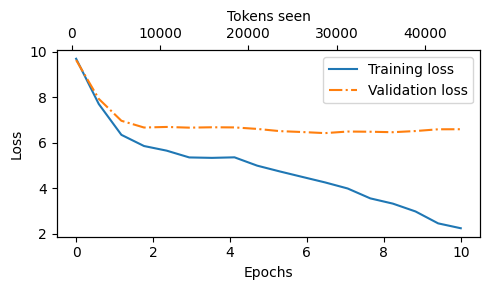

In [158]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Eğitim ve doğrulama kaybını tur sayısına göre çiz
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    ax2 = ax1.twiny()   # aynı y eksenini paylaşan ikinci x ekseni: görülen token
    ax2.plot(tokens_seen, train_losses, alpha=0)   # görünmez çizim: eksenleri hizalamak için
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

<hr id="ders-11" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 11 · Üretim Ayarları: Temperature ve Top-k

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-10">←</a> <a href="vscode-notebook-cell:?execution_count=136&line=1">Ders 10</a>  ·  <a href="vscode-notebook-cell:?execution_count=173&line=1">Ders 12</a> <a href="#ders-12">→</a></sub>

In [159]:
lesson(11, "Üretim Ayarları: Temperature ve Top-k")

Ders 11 · Üretim Ayarları: Temperature ve Top-k   ·   0.8 dk


**Problem:** hep en yüksek olasılıklıyı seçersek metin tekrara düşer, rastgele seçersek saçmalar. Arada ne var?

İki düğme. **Temperature** dağılımı düzleştirir ya da keskinleştirir — küçük değer kesin ama sıkıcı, büyük değer yaratıcı ama savruk. **Top-k sampling** kuyruğu keser: yalnız en olası k aday yarışır. Üretilen metnin karakterini bu iki sayı belirler.

<hr id="konu-11-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Temperature (Sıcaklık): Kesinlik ve Çeşitlilik Arasındaki Düğme

`generate_text_simple` her adımda en yüksek olasılıklıyı seçiyordu: aynı istem her zaman aynı metni veriyor, model bir kelime döngüsüne girdiğinde de çıkışı olmuyor. Bu konu o satırı örneklemeyle değiştiriyor ve araya bir düğme koyuyor — dağılımı keskinleştiren ya da düzleştiren Temperature (sıcaklık).

#### Eğitilmiş modelle üretim

<div class="alert alert-block alert-success">

Modeli cihaza taşı, sonra `eval()`. Dropout açık kalsa aynı istem her seferinde başka metin verirdi; bu dersin konusu çeşitliliği **bilerek** ayarlamak.

</div>

In [160]:
model.to(device)
model.eval();   # çıkarım modu: dropout kapalı

<div class="alert alert-block alert-success">

Eğitilmiş modelden metin. `context_size` modelin penceresi: sınır aşılınca en eski token'lar pencereden düşer. Çıktı akıcı değil ama artık İngilizce — ve korpusun ibareleri görünüyor, çünkü `generate_text_simple` her adımda en yüksek olasılıklıyı seçiyor: modelin en çok ezberlediği yol.

</div>

In [161]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you the same four
the and a reader has the links are not. "the same kind.
the and the thing beside


#### Dokuz kelimelik oyuncak sözlük

<div class="alert alert-block alert-success">

Sıcaklığın etkisi için 50 257 token yerine dokuz kelime. `inverse_vocab` ID'den kelimeye.

</div>

In [162]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

<div class="alert alert-block alert-success">

Elle yazılmış dokuz logit, üç sıcaklıkta softmax'tan geçiyor.

`T=0.1`: bölmek skorlar arasındaki **farkı** büyütür, softmax da farka bakar — tek bir 0.9910, kalan sekiz 0.0090. `T=5`: dağılım düzleşiyor. `T=1` ham dağılım: `forward` 0.5721, `toward` 0.3576 — `argmax` hep ilkini seçer, ikinci adaya sıra gelmez.

</div>

In [163]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

# T = 0.1 · keskin: 1'den küçük sayıya bölmek skorlar arasındaki farkı büyütür
probas = torch.softmax(next_token_logits / 0.1, dim=0)
print(probas)

# T = 5 · düz
probas = torch.softmax(next_token_logits / 5, dim=0)
print(probas)

# T = 1 · bölme yok: ham dağılım, karşılaştırma ölçütü
probas = torch.softmax(next_token_logits, dim=0)
print(probas)

next_token_id = torch.argmax(probas).item()
print(next_token_id)
print(inverse_vocab[next_token_id])

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])
tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
3
forward


#### `argmax` yerine örnekleme

<div class="alert alert-block alert-success">

`argmax` **deterministik**: model bir kelime döngüsüne girdiğinde çıkışı yoktur. `torch.multinomial` ise ağırlıklı bir zar atar: 0.5721 olan çoğu zaman, 0.3576 olan bazen, 0.0001 olan neredeyse hiç gelmez. Rastgeleleşen şey kararın kendisi.

</div>

In [164]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()   # (9,) -> tek ID
print(inverse_vocab[next_token_id])

forward


<div class="alert alert-block alert-success">

Tek örnek bir şey kanıtlamaz. 1000 kez örnekliyoruz: `forward` 582, `toward` 343, `closer` 73 — yani 0.5721, 0.3576 ve 0.0609'un bin katına yakın. `inches` bin denemede 2 kez geldi (payı 3.4190e-03), `pizza` hiç: küçük olasılık sıfır değil, sadece nadir. Örnekleme dağılımı bozmuyor, ona uyuyor.

</div>

In [165]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)   # aynı sonuçlar için tohum
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


#### Üç sıcaklığı tek fonksiyonda

<div class="alert alert-block alert-success">

Sıranın önemi var: bölme **softmax'tan önce** yapılıyor. Olasılıkları bölseydik toplamları 1 olmaktan çıkardı; logit ise sınırsız bir skor, onu ölçeklemek serbest.

</div>

In [166]:
def softmax_with_temperature(logits, temperature):
    return torch.softmax(logits / temperature, dim=0)

temperatures = [1, 0.1, 5]   # ham, keskin, düz

scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

<div class="alert alert-block alert-success">

Üç profil tek grafikte: `T=0.1`'de tek çubuk tavana değiyor, `T=1`'de iki çubuk öne çıkıyor, `T=5`'te dokuzu birbirine yaklaşıyor. Sıcaklık sıralamayı değiştirmiyor, yalnız adaylar arasındaki mesafeyi açıp kapatıyor — en yüksek logit hangi sıcaklıkta olursa olsun en yüksek pay alır.

</div>

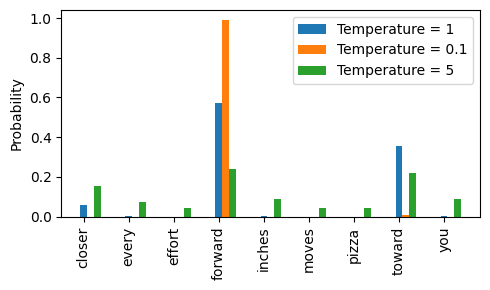

In [167]:
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

<hr id="konu-11-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Top-k Sampling: Saçmalamayı Nasıl Engelleriz?

Örnekleme çeşitlilik getirdi ama bir bedeli var: kuyrukta duran binlerce saçma adayın toplam payı da sıfır değil, uzun bir metinde biri mutlaka seçilir. Top-k sampling kuyruğu baştan kesiyor. Sonra iki düğmeyi birleştirip serinin son üretim fonksiyonunu kuruyoruz.

#### En yüksek k logit

<div class="alert alert-block alert-success">

Dokuz elemanlı logit vektörü **elle** yazıldı — dokuz sayıyı gözle takip edebilirsin, 50 257 tanesini edemezsin. `torch.topk(x, k)` en büyük k değeri ve **konumlarını** döndürür; bize asıl gereken k'ncı değer, bir sonraki adımda eşik olacak.

</div>

In [168]:
# Aynı dokuz logit; yukarıda kuruldu
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)   # (9,) -> (3,) + (3,) konum
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


#### Kalanları $-\infty$ yap

<div class="alert alert-block alert-success">

`torch.where`: k'ncı en büyükten küçük olan her logit $-\infty$ olsun. Niye 0 değil? Logit dünyasında 0 sıradan bir skordur ($e^0 = 1$), softmax'tan sonra pay alır. Olasılığı **tam** sıfıra indiren tek değer $-\infty$.

</div>

In [169]:
# (9,) -> (9,): şekil aynı, eşiğin altındaki altı logit -inf oluyor
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],   # eşik: 3. en büyük logit, 4.51
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)

print(new_logits)

topk_probas = torch.softmax(new_logits, dim=0)   # -inf'ler tam 0; kalan üçün toplamı 1
print(topk_probas)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


<div class="alert alert-block alert-info">

`-inf` yapılan altı yer softmax'tan sonra tam **0**. Kalan üçün payları 0.5775 · 0.3610 · 0.0615, toplamı 1: atılanların olasılığı kalanlara yeniden dağıtıldı. `forward` süzgeçten önce 0.5721 alıyordu, şimdi 0.5775 — kuyruk susturulunca öndekiler biraz daha güçlenir.

</div>

#### Birleşik `generate`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** `generate_text_simple`'a üç varsayılan argüman eklendi: `top_k=None`, `temperature=0.0`, `eos_id=None`. İki `if` hangi kolun çalışacağını belirliyor; varsayılanlarla çağrılırsa `argmax` koluna düşer, yani ders 9'daki davranış. Sıra da önemli: süzgeç önce, sıcaklık sonra — eşik ham logitler üzerinden seçilir.

</div>

In [170]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # şekil izi:  b = yığın · T = o anki token sayısı · 50257 = sözlük boyu
    # Döngü ders 9'un aynısı: logit al, yalnız son konuma bak
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]   # (b, T) -> son context_size token
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]   # (b, T, 50257) -> (b, 50257): yalnız son konum

        # YENİ: top-k süzgeci
        if top_k is not None:
            # Yalnız en yüksek k değeri tut
            top_logits, _ = torch.topk(logits, top_k)   # (b, 50257) -> (b, top_k)
            min_val = top_logits[:, -1]   # (b, top_k) -> (b,): k'ncı en büyük = eşik
            # eşiğin altındaki her skor -inf olur; şekil değişmez, kuyruk susturulur
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # YENİ: sıcaklık ölçeklemesi
        if temperature > 0.0:
            logits = logits / temperature   # şekil aynı; <1 keskinleştirir, >1 düzleştirir

            # Logit -> olasılık
            probs = torch.softmax(logits, dim=-1)   # (b, 50257): son adımın dağılımı

            # Dağılımdan örnekle
            idx_next = torch.multinomial(probs, num_samples=1)   # (b, 50257) -> (b, 1)

        # Sıcaklık 0 ise ders 9'daki gibi en yükseğini seç
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)   # (b, 50257) -> (b, 1)

        if idx_next == eos_id:   # dizi sonu token'ı geldiyse erken dur
            break

        # Seçilen token'ı dizinin sonuna ekle
        idx = torch.cat((idx, idx_next), dim=1)   # (b, T) + (b, 1) -> (b, T+1)

    return idx

<div class="alert alert-block alert-success">

Deneyelim: `top_k=25`, `temperature=1.4` — hem süzgeç hem çeşitlilik.

</div>

In [171]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as as the, the sentence is often anywhere. Some rain not all written


#### Aynı girdi, farklı ayarlar

<div class="alert alert-block alert-success">

Aynı istem, aynı tohum, aynı model — değişen yalnız iki sayı. Üç satırın başı benziyor, sonu ayrışıyor: farklı seçilen tek token sonraki adımların bağlamını değiştiriyor.

</div>

In [172]:
for name, setting in [("deterministik (argmax)", dict(temperature=0.0)),
                ("ölçülü (T=0.8, top_k=25)", dict(temperature=0.8, top_k=25)),
                ("çeşitli (T=1.5, top_k=50)", dict(temperature=1.5, top_k=50))]:
    torch.manual_seed(123)
    ids = generate(
        model=model,
        idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
        max_new_tokens=15,
        context_size=GPT_CONFIG_124M["context_length"],
        **setting,
    )
    print(f"{name}:")
    print("  ", token_ids_to_text(ids, tokenizer).replace("\n", " "))
    print()

deterministik (argmax):
   Every effort moves you the same four the and a reader has the links are not. "



ölçülü (T=0.8, top_k=25):
   Every effort moves you as as a reader worked" the anywhere. Some thing, but a



çeşitli (T=1.5, top_k=50):
   Every effort moves you as as the, the cheapest same word anywhere. Some rain not which



<hr id="ders-12" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 12 · Ağırlıklar: Kaydet, Yükle, OpenAI'ın GPT-2'si

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-11">←</a> <a href="vscode-notebook-cell:?execution_count=159&line=1">Ders 11</a>  ·  <a href="vscode-notebook-cell:?execution_count=188&line=1">Ders 13</a> <a href="#ders-13">→</a></sub>

In [173]:
lesson(12, "Ağırlıklar: Kaydet, Yükle, OpenAI'ın GPT-2'si")

Ders 12 · Ağırlıklar: Kaydet, Yükle, OpenAI'ın GPT-2'si   ·   0.9 dk


Eğittiğimiz model bellekte; defter kapanınca gidiyor. **`state_dict`** bütün ağırlıkları sözlük hâlinde verir, diske yazılır, geri yüklenir.

Sonra dersin asıl olayı: kendi yazdığımız modele **OpenAI'ın gerçek GPT-2 ağırlıkları** yükleniyor. Bu bir hile değil, bir doğrulama — mimari gerçekten GPT-2'yse başkasının ağırlıkları bizim sınıflarımıza oturur. Oturuyor, ve model ilk kez akıcı İngilizce üretiyor.

<hr id="konu-12-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Modeli Kaydet ve Yükle: state_dict ve Checkpoint

Eğitimin ürünü yalnız bellekte: defter kapanınca 90 adımın tamamı gidiyor. Bu konu iki kaydı ayırıyor — yalnız ağırlıkları taşıyan `state_dict` ile eğitimi kaldığı yerden sürdürmeye yarayan checkpoint.

#### `state_dict`

<div class="alert alert-block alert-success">

`model.state_dict()` bütün kayıtları **ada göre** bir sözlükte döndürür. `load_state_dict` var olan tensörlerin üstüne yazar, yenisini yaratmaz — `GPTModel(GPT_CONFIG_124M)` çağrısı bu yüzden yükleme satırından ÖNCE durur.

</div>

In [174]:
torch.save(model.state_dict(), "_data/model.pth")

<div class="alert alert-block alert-success">

Yükleme üç adım: modeli kur → `load_state_dict` → `eval()`. Sondaki `eval()` şart: yeni bir `nn.Module` eğitim modunda doğar, ağırlık yüklemek bunu değiştirmez — atlanırsa diskten okunan model aynı istemde başka metin üretir.

</div>

In [175]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("_data/model.pth"))
model.eval();

#### Eğitimi kaldığı yerden sürdürmek

<div class="alert alert-block alert-success">

`torch.save` sözlük de alır: `model_state_dict` ve `optimizer_state_dict` yan yana. Optimizatörün sözlüğü iki bölüm: `"state"` (parametre başına tutulan tablolar) ve `"param_groups"` (ayarlar).

</div>

In [176]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

torch.save({"model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()},
           "_data/model_and_optimizer.pth")

<div class="alert alert-block alert-success">

Geri yüklerken de ikisi birden. `model.train()` sonda: eğitime devam edeceğimiz için dropout açık olmalı.

</div>

In [177]:
checkpoint = torch.load("_data/model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

<div class="alert alert-block alert-success">

İki kaydın dosya boyu — ve çıktı beklenmedik: ikisi de 622.6 MB, optimizatörün durum tablosu **boş**.

Sebep: `optimizer` sıfırdan kuruldu, bir kez bile `step()` çağrılmadı; AdamW durum tablolarını ilk adımda yaratır. Dosyaya yalnız `param_groups` yazıldı. Eğitim gerçekten sürseydi checkpoint kabaca **üç katına** çıkardı.

</div>

In [178]:
for name in ["_data/model.pth", "_data/model_and_optimizer.pth"]:
    mb = os.path.getsize(name) / (1024 * 1024)
    print(f"{name:34s} {mb:8.1f} MB")

print()
print("optimizatör durum kaydı:", len(optimizer.state_dict()["state"]), "parametre için tablo")
print("param_group sayısı     :", len(optimizer.state_dict()["param_groups"]))

_data/model.pth                       622.6 MB
_data/model_and_optimizer.pth         622.6 MB

optimizatör durum kaydı: 0 parametre için tablo
param_group sayısı     : 1


<hr id="konu-12-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### OpenAI'ın Ağırlıklarını Kendi Modelimize Yüklüyoruz

Bizim ön eğitimimiz 5 542 token gördü; OpenAI'ın GPT-2'si ~10 milyar. Aynı mimariyi yazdıysak onun ağırlıkları bizim sınıflarımıza oturmalı: bu konu hem o yüklemeyi yapıyor hem de mimarinin doğruluğunu sınıyor.

#### Ağırlıkları indir

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Yaygın yol OpenAI'ın TensorFlow checkpoint'i — 2 GB'lık kurulum ister. Aynı ağırlıkların **safetensors** sürümü de var; fonksiyon onu indirip **birebir aynı** `params` sözlüğünü üretiyor.

Okunacak yer sondaki `params` sözlüğü: OpenAI'ın anahtar adları burada kuruluyor ve bir sonraki hücreye o adlarla geçiyor. İndirme ≈ 550 MB ve **bir kez** olur: `_data/gpt2/124M/` altına yazılır.

</div>

In [179]:
# --- OpenAI'ın GPT-2 ağırlıklarını indir ---------------------------------------
GPT2_REPOS = {
    "124M": ("openai-community/gpt2",        dict(n_layer=12, n_head=12, n_embd=768)),
    "355M": ("openai-community/gpt2-medium", dict(n_layer=24, n_head=16, n_embd=1024)),
    "774M": ("openai-community/gpt2-large",  dict(n_layer=36, n_head=20, n_embd=1280)),
    "1558M": ("openai-community/gpt2-xl",    dict(n_layer=48, n_head=25, n_embd=1600)),
}


def download_and_load_gpt2(model_size="124M", models_dir="_data/gpt2"):
    """Ağırlıkları indirir (bir kez) ve (settings, params) döndürür."""
    from safetensors.numpy import load_file

    repo, shape = GPT2_REPOS[model_size]
    out_dir = Path(models_dir) / model_size
    out_dir.mkdir(parents=True, exist_ok=True)
    weights_file = out_dir / "model.safetensors"

    if not weights_file.exists():
        url = f"https://huggingface.co/{repo}/resolve/main/model.safetensors"
        print(f"{model_size} ağırlıkları indiriliyor ({repo})...")
        with urllib.request.urlopen(url, timeout=120) as r, open(weights_file, "wb") as out:
            total = int(r.headers.get("Content-Length", 0))
            done = 0
            step_bytes = max(total // 10, 1 << 21)   # ilerlemeyi ~%10'luk aralıklarla bas
            threshold = step_bytes                        # (her yığında bassa 260+ satır gürültü olur)
            while True:
                chunk = r.read(1 << 21)
                if not chunk:
                    break
                out.write(chunk)
                done += len(chunk)
                if done >= threshold or done == total:
                    print(f"\r  {done / 1e6:7.0f} / {total / 1e6:.0f} MB", end="")
                    threshold += step_bytes
        print(f"\n  kaydedildi: {weights_file}")
    else:
        print(f"{model_size} ağırlıkları zaten yerelde: {weights_file}")

    w = load_file(str(weights_file))

    def get(name):
        # Bazı sürümlerde anahtarlar "transformer." önekiyle geliyor
        return w[name] if name in w else w["transformer." + name]

    params = {
        "wpe": get("wpe.weight"),          # konum embedding tablosu
        "wte": get("wte.weight"),          # token embedding tablosu
        "g": get("ln_f.weight"),           # son LayerNorm ölçeği
        "b": get("ln_f.bias"),             # son LayerNorm kaydırması
        "blocks": [],
    }
    for b in range(shape["n_layer"]):
        p = f"h.{b}."
        params["blocks"].append({
            "attn": {
                "c_attn": {"w": get(p + "attn.c_attn.weight"), "b": get(p + "attn.c_attn.bias")},
                "c_proj": {"w": get(p + "attn.c_proj.weight"), "b": get(p + "attn.c_proj.bias")},
            },
            "mlp": {
                "c_fc": {"w": get(p + "mlp.c_fc.weight"), "b": get(p + "mlp.c_fc.bias")},
                "c_proj": {"w": get(p + "mlp.c_proj.weight"), "b": get(p + "mlp.c_proj.bias")},
            },
            "ln_1": {"g": get(p + "ln_1.weight"), "b": get(p + "ln_1.bias")},
            "ln_2": {"g": get(p + "ln_2.weight"), "b": get(p + "ln_2.bias")},
        })

    settings = {"n_vocab": 50257, "n_ctx": 1024,
                "n_embd": shape["n_embd"], "n_head": shape["n_head"], "n_layer": shape["n_layer"]}
    return settings, params


settings, params = download_and_load_gpt2(model_size="124M", models_dir="_data/gpt2")

124M ağırlıkları indiriliyor (openai-community/gpt2)...


       57 / 548 MB

      111 / 548 MB

      166 / 548 MB

      220 / 548 MB

...

      329 / 548 MB

      384 / 548 MB

      440 / 548 MB

      495 / 548 MB

      548 / 548 MB
  kaydedildi: _data/gpt2/124M/model.safetensors


<div class="alert alert-block alert-success">

Sözlüğün içine bakalım. `settings` GPT-2'nin ölçüleri; `params` beş anahtar: `wte`, `wpe`, `g`, `b` ve bütün blokları tutan `blocks`. Sonra token embedding tablosu — 50 257 × 768, ders 1'de "en büyük tek tablo" dediğimiz matris, artık OpenAI'ın eğittiği gerçek sayılarla.

</div>

In [180]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())
print(params["wte"][:2, :4])   # (50257, 768) tablosunun ilk iki satırı, ilk dört sayısı
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['wpe', 'wte', 'g', 'b', 'blocks'])
[[-0.11010301 -0.03926672  0.03310751  0.13382645]
 [ 0.04034033 -0.04861503  0.04624869 -0.09900099]]
Token embedding weight tensor dimensions: (50257, 768)


#### Modeli aynı ölçüye getir

<div class="alert alert-block alert-success">

Dört GPT-2 boyunun ölçüleri. Yükleyeceğimiz ağırlıklar 124M, o satırı seçiyoruz.

</div>

In [181]:
# Dört GPT-2 boyunun ölçüleri
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Temel yapılandırmayı seçilen boyun ölçüleriyle güncelle
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs["gpt2-small (124M)"])

<div class="alert alert-block alert-success">

İki anahtar değişiyor, ikisi de mecburi — devralınan ağırlıkların şekli mimariyi dikte ediyor:

| Anahtar | Yeni değer | Neden |
| --- | --- | --- |
| `context_length` | 1024 | OpenAI'ın konum tablosu `(1024, 768)` |
| `qkv_bias` | `True` | GPT-2 q/k/v katmanlarını bias ile eğitmiş |

</div>

In [182]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})   # pos_emb (256, 768) -> (1024, 768)
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

#### `assign`: şekil kontrolü + kopyalama

<div class="alert alert-block alert-success">

Tek iş: kopyalamadan önce iki tarafın ölçüsünü karşılaştır, tutmazsa `ValueError`. Ama denetim şekle bakar, içeriğe bakmaz: aynı ölçüdeki iki tablo yer değiştirse yine geçerdi. Asıl güvence eşleme haritası.

</div>

In [183]:
def assign(left, right):
    if left.shape != right.shape:   # tutmazsa dur; sessiz bozulma olmasın
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

#### `load_weights_into_gpt`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Eşleme elle yazılmış: iki taraf bağımsız isimler kullanıyor. Tablonun her satırı kodun bir satırıdır.

| OpenAI | Bizim | Şekil | `.T`? |
| --- | --- | --- | --- |
| `wte` | `tok_emb.weight` · `out_head.weight` | (50257, 768) | hayır |
| `wpe` | `pos_emb.weight` | (1024, 768) | hayır |
| `attn.c_attn` · `w` | `att.W_query`/`W_key`/`W_value`.`weight` | (768, 2304) → 3 × (768, 768) | **evet** |
| `attn.c_attn` · `b` | aynı üçlünün `.bias`'ı | (2304,) → 3 × (768,) | hayır |
| `attn.c_proj` | `att.out_proj` | (768, 768) | ağırlıkta **evet** |
| `mlp.c_fc` | `ff.layers[0]` | (768, 3072) | ağırlıkta **evet** |
| `mlp.c_proj` | `ff.layers[2]` | (3072, 768) | ağırlıkta **evet** |
| `ln_1` / `ln_2` · `g`/`b` | `norm1` / `norm2` · `.scale`/`.shift` | (768,) | hayır |
| `g` / `b` | `final_norm.scale` / `.shift` | (768,) | hayır |

**`.T` neden:** OpenAI'ın `Conv1D` katmanı ağırlığı `(girdi, çıktı)` sırasıyla saklar, `nn.Linear` ise `(çıktı, girdi)` bekler. Vektörde (bias, LayerNorm) sıra olmadığı için devrik gerekmez.

**Tuzak:** q/k/v parçaları kare (768 × 768) — `.T` atlansa şekil denetimi yine geçerdi, sayılar yanlış yere düşerdi.

İlk satır: `wte` hem girişte hem çıkışta (Weight Tying — ağırlık paylaşımı). Döngü 12 blok için koşuyor.

</div>

In [184]:
def load_weights_into_gpt(gpt, params):
    # OpenAI'ın adı -> bizim ad. `.T` gereken yerler: OpenAI'ın Conv1D katmanı ağırlığı
    # (girdi, çıktı) sırasıyla saklar, nn.Linear ise (çıktı, girdi) bekler.
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])   # (1024, 768)
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])   # (50257, 768)

    for b, p in enumerate(params["blocks"]):
        blk = gpt.trf_blocks[b]   # kısa ad: her atama tek satıra sığsın

        # --- dikkat · c_attn tek matris: (768, 2304) -> üçe bölünüp 3 × (768, 768) ---
        q_w, k_w, v_w = np.split(p["attn"]["c_attn"]["w"], 3, axis=-1)
        blk.att.W_query.weight = assign(blk.att.W_query.weight, q_w.T)
        blk.att.W_key.weight   = assign(blk.att.W_key.weight,   k_w.T)
        blk.att.W_value.weight = assign(blk.att.W_value.weight, v_w.T)

        # --- aynı bölme bias için: (2304,) -> 3 × (768,) · vektörde devrik yok ---
        q_b, k_b, v_b = np.split(p["attn"]["c_attn"]["b"], 3, axis=-1)
        blk.att.W_query.bias = assign(blk.att.W_query.bias, q_b)
        blk.att.W_key.bias   = assign(blk.att.W_key.bias,   k_b)
        blk.att.W_value.bias = assign(blk.att.W_value.bias, v_b)

        # --- dikkatin çıkış izdüşümü · c_proj -> out_proj: (768, 768) ---
        blk.att.out_proj.weight = assign(blk.att.out_proj.weight, p["attn"]["c_proj"]["w"].T)
        blk.att.out_proj.bias   = assign(blk.att.out_proj.bias,   p["attn"]["c_proj"]["b"])

        # --- ileri besleme · c_fc genişletir (768, 3072), c_proj daraltır (3072, 768) ---
        # layers[0] ve layers[2]: aradaki layers[1] GELU, öğrenilecek ağırlığı yok
        blk.ff.layers[0].weight = assign(blk.ff.layers[0].weight, p["mlp"]["c_fc"]["w"].T)
        blk.ff.layers[0].bias   = assign(blk.ff.layers[0].bias,   p["mlp"]["c_fc"]["b"])
        blk.ff.layers[2].weight = assign(blk.ff.layers[2].weight, p["mlp"]["c_proj"]["w"].T)
        blk.ff.layers[2].bias   = assign(blk.ff.layers[2].bias,   p["mlp"]["c_proj"]["b"])

        # --- iki LayerNorm · OpenAI'ın g/b -> bizim scale/shift, ikisi de (768,) ---
        blk.norm1.scale = assign(blk.norm1.scale, p["ln_1"]["g"])
        blk.norm1.shift = assign(blk.norm1.shift, p["ln_1"]["b"])
        blk.norm2.scale = assign(blk.norm2.scale, p["ln_2"]["g"])
        blk.norm2.shift = assign(blk.norm2.shift, p["ln_2"]["b"])

    # --- döngü dışı: son LayerNorm + çıkış başı ---
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    # out_head, tok_emb ile AYNI tabloyu alıyor (Weight Tying)
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])   # (50257, 768)

<div class="alert alert-block alert-success">

Yükle ve cihaza taşı: `gpt` artık OpenAI'ın 10 milyar token görmüş modeliyle aynı ağırlıklara sahip.

</div>

In [185]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

#### Sınav

<div class="alert alert-block alert-success">

Aynı başlangıç metni, aynı `generate`, aynı mimari — tek fark ağırlıklar. Doğrulama noktası: *"aynı model, artık akıcı metin üretmeli"*.

</div>

In [186]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn. By now there's a very small delay before you gain


<div class="alert alert-block alert-success">

Aynı istem, aynı tohum, aynı üretim ayarları: çıktı farkının tek açıklaması ağırlıklar. Kendi eğittiğimiz model ile OpenAI'ınki yan yana.

</div>

In [187]:
# `model` diskten yeniden kuruldu: CPU'da ve train() modunda. İkisi de düzeltilmeli —
# dropout açık kalsa "tek fark ağırlıklar" iddiası düşerdi.
model.to(device)
model.eval();

torch.manual_seed(123)
ours = generate(model=model, idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
                 max_new_tokens=20, context_size=GPT_CONFIG_124M["context_length"],
                 top_k=25, temperature=0.8)

torch.manual_seed(123)
openai = generate(model=gpt, idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
                  max_new_tokens=20, context_size=NEW_CONFIG["context_length"],
                  top_k=25, temperature=0.8)

print("bizim ön eğitimimiz (5 542 token):")
print("  ", token_ids_to_text(ours, tokenizer).replace("\n", " "))
print()
print("OpenAI'ın ön eğitimi (~10 milyar token):")
print("  ", token_ids_to_text(openai, tokenizer).replace("\n", " "))
print()
print("Aynı mimari, aynı kod, aynı parametre sayısı — fark yalnız görülen veri miktarı.")

bizim ön eğitimimiz (5 542 token):
   Every effort moves you as as a reader worked" the anywhere. Some thing, but a language: the commonest

OpenAI'ın ön eğitimi (~10 milyar token):
   Every effort moves you as far as the eye can see.  It's not that you have to be a very

Aynı mimari, aynı kod, aynı parametre sayısı — fark yalnız görülen veri miktarı.


<hr id="bolum-6" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

# BÖLÜM 6 · FINETUNING

<hr id="ders-13" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 13 · Finetuning Nedir ve Sınıflandırma Verisi

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-12">←</a> <a href="vscode-notebook-cell:?execution_count=173&line=1">Ders 12</a>  ·  <a href="vscode-notebook-cell:?execution_count=199&line=1">Ders 14</a> <a href="#ders-14">→</a></sub>

In [188]:
lesson(13, "Finetuning Nedir ve Sınıflandırma Verisi")

Ders 13 · Finetuning Nedir ve Sınıflandırma Verisi   ·   1.1 dk


Elimizde metnin devamını yazan bir model var; ama çoğu gerçek iş bu değil. **Finetuning**, hazır modele küçük bir veriyle yeni davranış ekler.

İki yol var, ikisini de yapacağız: **classification finetuning** sabit etiketlere karar verdirir, **instruction finetuning** talimat izleyen asistana çevirir. Bu ders birincinin verisini hazırlıyor: dengeli sınıflar, üçe bölme, ve tensörü dikdörtgen yapan **padding**.

<hr id="konu-13-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Finetuning (İnce Ayar) Nedir? Aynı Modelden İki Farklı Uzman

Bu derste kod yok: iki ince ayar türünün ayrımı, çıkış katmanının küçülme oranı ve veri kümesi kararı ders yüzeyinde kuruluyor. Defter sıradaki dersle, kümeyi üreterek başlıyor.

#### Sınıflandırma hattının hücre sırası

<div class="alert alert-block alert-success">

1. veri kümesi ve üçe bölme — bu derste
2. `TopicDataset` ve üç `DataLoader` — bu derste
3. `out_head`'in değişmesi ve `requires_grad` — ders 14
4. eğitim döngüsü ve `calc_accuracy_loader` — ders 14

</div>

<div class="alert alert-block alert-warning">

**Veri kümesi inmez, kodla üretilir.** İnen tek dosya ders 12'nin ağırlıkları; o da `_data/gpt2/124M/` altında hazır.

</div>

<hr id="konu-13-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Veri Kümesini Hazırla: Class Balance (Dengeleme) ve Split (Bölme)

Bu dersin hücreleri kümeyi üretiyor, `pandas` tablosuna alıyor, dengeliyor, etiketleri sayıya çeviriyor ve üç CSV dosyası yazıyor.

#### Kümeyi üret

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Üstteki katlı hücre yalnız veri taşıyor: 101 biyoloji + 100 fizik cümlesi. Alttaki hücre her cümleyi üç önekle çoğaltıp etiketiyle birlikte JSON'a yazıyor.

**Neden önek:** aynı bilgi farklı kalıplarla gelsin ki model kalıbı değil konuyu ayırsın. Öneklerin ilki boş dizgi, yani cümlenin düz hâli: 201 cümle × 3 önek = 603 kayıt.

**Kritik satır:** `random.Random(123).shuffle(records)` sırayı karıştırıyor — kayıtlar sınıf sınıf sıralı kalmasın, ama sabit tohum sayesinde her koşuda aynı sıra çıksın.

</div>

In [189]:
# --- Konu sınıflandırma cümleleri ---------------------------------------------
# Bu hücre yalnız veri taşır: 101 biyoloji + 100 fizik cümlesi. Üreten kod bir alttaki
# hücrede. (Jupyter ve Colab bu hücreyi katlı açar; GitHub gibi durağan görüntüleyicide
# açık gelir — okumadan aşağı kaydırıp geçebilirsin.)

BIOLOGY_SENTENCES = [
    "The cell membrane is selectively permeable.",
    "Ribosomes assemble proteins from amino acids.",
    "Mitochondria release energy stored in glucose.",
    "Chloroplasts capture light and store it as sugar.",
    "Enzymes lower the activation energy of reactions in the cell.",
    "DNA carries the instructions for building proteins.",
    "Messenger RNA copies a gene and leaves the nucleus.",
    "Chromosomes condense before a cell divides.",
    "Red blood cells transport oxygen to the tissues.",
    "Neurons transmit signals through long thin extensions.",
    "Bacteria reproduce by splitting into two identical cells.",
    "Fungi absorb nutrients from decaying organic matter.",
    "The nucleus stores the genetic material of the cell.",
    "Photosynthesis converts carbon dioxide and water into sugar.",
    "Cellular respiration breaks down glucose to release energy.",
    "Osmosis moves water across a membrane toward higher solute concentration.",
    "Natural selection favours traits that improve survival.",
    "A gene is a segment of DNA that codes for a protein.",
    "Proteins fold into specific shapes that determine their function.",
    "The immune system recognises foreign molecules and responds to them.",
    "Stomata on a leaf open and close to control water loss.",
    "Roots absorb water and dissolved minerals from the soil.",
    "Xylem carries water upward through the stem of a plant.",
    "Phloem distributes sugars from the leaves to the rest of the plant.",
    "Meiosis produces cells with half the usual number of chromosomes.",
    "Mitosis produces two daughter cells identical to the parent.",
    "Enzyme activity depends strongly on temperature and acidity.",
    "The liver removes toxins from the blood.",
    "The kidneys filter waste products out of the bloodstream.",
    "Alveoli in the lungs allow gases to diffuse into the blood.",
    "Hormones travel through the blood and act on distant organs.",
    "Insulin lowers the concentration of sugar in the blood.",
    "The heart pumps blood through two separate circuits.",
    "Capillary walls are thin enough for molecules to pass through.",
    "Antibodies bind to specific molecules on invading cells.",
    "Vaccination trains the immune system without causing illness.",
    "Bacteria in the soil convert nitrogen into forms plants can use.",
    "Decomposers return nutrients from dead matter to the soil.",
    "An ecosystem includes all organisms in an area and their surroundings.",
    "Producers convert light energy into chemical energy.",
    "Consumers obtain energy by eating other organisms.",
    "Energy is lost as heat at every step of a food chain.",
    "Populations grow until limited by food, space, or disease.",
    "Species that cannot adapt to a changing habitat decline.",
    "Fossils record the sequence in which species appeared.",
    "Related species share features inherited from a common ancestor.",
    "Mutations introduce new variation into a population.",
    "Most mutations have no effect on the organism.",
    "Genetic variation allows populations to adapt over generations.",
    "Two organisms of the same species can produce fertile offspring.",
    "The cytoplasm holds the organelles of the cell in place.",
    "Lysosomes break down worn out cell components.",
    "The endoplasmic reticulum transports proteins within the cell.",
    "The Golgi apparatus packages proteins for export.",
    "Cell walls give plant cells their rigid shape.",
    "Vacuoles store water and dissolved substances in plant cells.",
    "Chlorophyll absorbs red and blue light and reflects green.",
    "Yeast converts sugar into carbon dioxide during fermentation.",
    "Algae in water produce a large share of atmospheric oxygen.",
    "Seeds remain dormant until conditions allow germination.",
    "Pollination transfers pollen between flowers of the same species.",
    "Fruit develops from the ovary of a flower after fertilisation.",
    "Tropisms cause plants to grow toward light or against gravity.",
    "Auxin accumulates on the shaded side of a growing stem.",
    "The spinal cord carries signals between the brain and the body.",
    "Reflexes bypass the brain and shorten the response time.",
    "Muscle cells contract when they receive a nerve signal.",
    "Tendons connect muscle to bone.",
    "Bone tissue is continuously rebuilt throughout life.",
    "Cartilage cushions the surfaces where two bones meet.",
    "Blood platelets help wounds close by forming clots.",
    "White blood cells engulf and destroy bacteria.",
    "The stomach secretes acid that begins the digestion of protein.",
    "Bile emulsifies fat so that enzymes can act on it.",
    "The small intestine absorbs nutrients through folded walls.",
    "Bacteria in the gut help break down material we cannot digest.",
    "Cells specialise during development into tissues and organs.",
    "Stem cells can develop into several different cell types.",
    "Tissue is a group of similar cells with a shared function.",
    "An organ is built from several tissues working together.",
    "Body temperature is held nearly constant by feedback mechanisms.",
    "Sweating cools the body as water evaporates from the skin.",
    "Shivering releases heat through rapid muscle contraction.",
    "A virus can only reproduce inside a living host cell.",
    "Antibiotics act on bacteria and have no effect on viruses.",
    "Resistant bacteria survive treatment and pass on their resistance.",
    "Enzymes are proteins and lose their shape when heated too far.",
    "The rate of photosynthesis rises with light until another factor limits it.",
    "Guard cells change shape to open the pores of a leaf.",
    "Transpiration pulls a continuous column of water up a tree.",
    "Nerve signals travel as a wave of electrical change along a membrane.",
    "Synapses pass signals between neurons using chemical messengers.",
    "The retina contains cells that respond to light of different colours.",
    "The inner ear converts vibrations into nerve signals.",
    "Cells maintain a difference in ion concentration across the membrane.",
    "Active transport moves molecules against a concentration gradient.",
    "Diffusion spreads molecules from crowded regions to empty ones.",
    "Surface area limits how fast a cell can exchange materials.",
    "Larger organisms need transport systems because diffusion is too slow.",
    "Offspring inherit one copy of each gene from each parent.",
    "A recessive trait appears only when both inherited copies match.",
]

PHYSICS_SENTENCES = [
    "A force is required to change the velocity of an object.",
    "Acceleration is proportional to the net force on a body.",
    "An object at rest stays at rest unless a force acts on it.",
    "Momentum is the product of mass and velocity.",
    "Total momentum is conserved when two bodies collide.",
    "Kinetic energy grows with the square of the speed.",
    "Potential energy increases as an object is raised.",
    "Energy is transferred but never created or destroyed.",
    "Friction opposes the relative motion of two surfaces.",
    "Friction converts kinetic energy into heat.",
    "Gravity pulls every mass toward every other mass.",
    "The weight of an object depends on the local gravitational field.",
    "A projectile follows a curved path under constant gravity.",
    "The period of a pendulum depends on its length.",
    "A wave transfers energy without transferring matter.",
    "Frequency and wavelength are inversely related for a fixed speed.",
    "Sound travels faster in water than in air.",
    "Light travels in straight lines through a uniform medium.",
    "Refraction bends light when it passes between two media.",
    "A lens forms an image by refracting light to a focus.",
    "A mirror reflects light at an angle equal to the incoming angle.",
    "White light separates into colours when it passes through a prism.",
    "Electric current is the rate of flow of charge.",
    "Voltage is the energy transferred per unit of charge.",
    "Resistance limits the current for a given voltage.",
    "Power equals current multiplied by voltage.",
    "Components in series carry the same current.",
    "Components in parallel share the same voltage.",
    "A magnetic field surrounds every moving charge.",
    "A current carrying wire experiences a force in a magnetic field.",
    "Moving a magnet near a coil induces a voltage in the coil.",
    "A transformer changes voltage using two coils and a shared core.",
    "Heat flows from a hotter body to a colder one.",
    "Metals conduct heat faster than gases.",
    "Most materials expand when their temperature rises.",
    "Pressure is force divided by area.",
    "Pressure in a fluid increases with depth.",
    "An object floats when the upward buoyant force balances its weight.",
    "Gas pressure rises when the same gas is compressed into a smaller volume.",
    "The temperature of a gas is a measure of the average kinetic energy of its particles.",
    "Work is done when a force moves an object along its direction.",
    "Power is the rate at which work is done.",
    "A machine can reduce the required force but not the required work.",
    "A lever multiplies force at the cost of distance.",
    "A pulley changes the direction of an applied force.",
    "Terminal velocity is reached when drag balances weight.",
    "Air resistance grows as an object moves faster.",
    "Circular motion requires a force directed toward the centre.",
    "A satellite stays in orbit because gravity provides the centripetal force.",
    "Escape speed depends on the mass and radius of the planet.",
    "Two charges of the same sign repel each other.",
    "An electric field describes the force per unit charge at a point.",
    "Charge is conserved in every interaction.",
    "A capacitor stores energy in an electric field.",
    "An insulator has very few charges free to move.",
    "Semiconductors conduct better as their temperature rises.",
    "A diode allows current to flow in only one direction.",
    "Radio waves and visible light differ only in wavelength.",
    "The speed of light in a vacuum is the same for all observers.",
    "Nothing carrying information can travel faster than light.",
    "Mass and energy are related by a single constant factor.",
    "A nucleus is held together by a force stronger than electric repulsion.",
    "Radioactive decay reduces the number of unstable nuclei over time.",
    "Half life is the time for half of a sample to decay.",
    "Nuclear fusion joins light nuclei and releases energy.",
    "Nuclear fission splits heavy nuclei and releases energy.",
    "Alpha particles are stopped by a sheet of paper.",
    "Gamma rays penetrate much further than alpha particles.",
    "Photons carry energy proportional to their frequency.",
    "Electrons occupy discrete energy levels in an atom.",
    "An atom emits light when an electron falls to a lower level.",
    "The photoelectric effect shows that light arrives in packets.",
    "Interference occurs when two waves overlap.",
    "Two waves cancel where a crest meets a trough.",
    "Diffraction spreads a wave after it passes through a narrow gap.",
    "Standing waves form when a wave reflects onto itself.",
    "Resonance occurs when a system is driven at its natural frequency.",
    "A vibrating string produces a note set by its length and tension.",
    "The Doppler effect changes the observed frequency of a moving source.",
    "Echoes are reflections of sound from a distant surface.",
    "Ultrasound frequencies lie above the range of human hearing.",
    "A thermometer works because a property changes with temperature.",
    "Specific heat capacity is the energy needed to warm one kilogram by one degree.",
    "Latent heat is absorbed during a change of state without a temperature change.",
    "Evaporation cools the liquid that is left behind.",
    "Convection carries heat by the bulk motion of a fluid.",
    "Radiation transfers heat without any material between the bodies.",
    "A dark surface absorbs and emits radiation more readily than a shiny one.",
    "Velocity is speed together with a direction.",
    "Displacement is the straight line distance from start to finish.",
    "The gradient of a distance time graph gives the speed.",
    "The area under a velocity time graph gives the distance travelled.",
    "Two forces of equal size in opposite directions produce no acceleration.",
    "Every action force has an equal and opposite reaction force.",
    "The centre of mass of an object moves as if all mass were there.",
    "An object is stable when its centre of mass lies above its base.",
    "A torque turns an object about a pivot.",
    "A beam balances when the turning effects on both sides are equal.",
    "Density is mass divided by volume.",
    "A denser fluid exerts more pressure at the same depth.",
]

In [190]:
# --- Konu sınıflandırma kümesini üret -----------------------------------------
# Yukarıdaki iki listeyi üç önekle çarpıp `_data/topic-classification.json` dosyasını
# yazar; dosya varsa yeniden üretmez. İndirme yok, ağ erişimi yok.

import random   # ortak kurulum hücresinde yok, karıştırma için burada gerekiyor

# Her cümle listedeki üç önekle birleştirilir; birincisi boş dizgi, yani cümlenin düz hâli.
PREFIXES = ["", "In most cases, ", "The textbook states that "]


def build_topic_dataset(path):
    """İki sınıflı konu kümesini üretir ve JSON olarak yazar (varsa dokunmaz)."""
    if path.exists():
        print(f"{path} zaten var, yeniden üretilmedi.")
        return path

    records = []
    for label, sentences in (("biology", BIOLOGY_SENTENCES), ("physics", PHYSICS_SENTENCES)):
        for sentence in sentences:
            for prefix in PREFIXES:
                # önek varsa cümlenin ilk harfi küçülür
                text = prefix + sentence[0].lower() + sentence[1:] if prefix else sentence
                records.append({"text": text, "label": label})

    random.Random(123).shuffle(records)      # sabit tohum: her koşuda aynı sıra
    path.write_text(json.dumps(records, indent=1, ensure_ascii=False), encoding="utf-8")
    print(f"{path} üretildi: {len(records)} kayıt")
    return path


topic_file = build_topic_dataset(DATA_DIR / "topic-classification.json")

_data/topic-classification.json üretildi: 603 kayıt


#### Pandas tablosuna al

<div class="alert alert-block alert-success">

Kayıtlar iki kolonlu bir tabloya giriyor; kolon adları sonraki hücrenin aradığı adlara çevriliyor.

Çıktıda iki şey var: 603 kayıt ve sınıf dağılımı — 303 biyolojiye 300 fizik. Fark tek bir temel cümleden geliyor (101 − 100), üç önekle üçe katlanmış. Alttaki beş satırda önekli ve düz cümleler karışık geliyor: karıştırma çalışmış.

</div>

In [191]:
df = pd.read_json(topic_file)

# kolon adları TopicDataset'in aradığı adlara çevriliyor: "Label" ve "Text"
df = df.rename(columns={"text": "Text", "label": "Label"})[["Label", "Text"]]

print("kayıt sayısı:", len(df))
print(df["Label"].value_counts())
df.head()

kayıt sayısı: 603
Label
biology    303
physics    300
Name: count, dtype: int64


,Label,Text
0,biology,The textbook states that roots absorb water an...
1,biology,Tendons connect muscle to bone.
2,biology,"In most cases, enzyme activity depends strongl..."
3,biology,"In most cases, a virus can only reproduce insi..."
4,physics,The textbook states that a current carrying wi...


#### Dengeleme

<div class="alert alert-block alert-success">

Her sınıftan, en küçük sınıf kadar örnek alıyoruz: 303 biyoloji kaydından 3'ü düşüyor, elde 300'e 300 kalıyor.

**Neden:** dengesiz kümede Accuracy (doğruluk) yalancı olur — hiç öğrenmeyen bir model çoğunluk sınıfını söyleyerek yüksek not alır. 300'e 300'de taban çizgisi (Baseline) %50'dir; bundan sonra göreceğimiz her puan bu %50 ile kıyaslanır.

**Kritik satır:** `.sample(smallest, random_state=123)` — hangi 3 kaydın düştüğü tohumla sabitlenmiş, iki koşuda aynı küme çıkıyor.

Çıktıdaki iki sayı eşit olmalı.

</div>

In [192]:
def create_balanced_dataset(df, label_column="Label"):
    counts = df[label_column].value_counts()
    smallest = counts.min()   # hedef sayı: en küçük sınıf kaç örnek taşıyorsa o

    # her sınıftan aynı sayıda örnek; random_state sabit, düşen kayıtlar her koşuda aynı
    parts = [df[df[label_column] == label].sample(smallest, random_state=123)
             for label in counts.index]
    return pd.concat(parts)


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
biology    300
physics    300
Name: count, dtype: int64


#### Etiketleri sayıya çevir

<div class="alert alert-block alert-success">

`biology` → 0, `physics` → 1. Kayıp fonksiyonu hedefi tam sayı ister; sınıf adı metin kalamaz.

Eşlemede karşılığı olmayan bir değer `NaN` olur — yazım hatası sessizce geçmez.

</div>

In [193]:
balanced_df["Label"] = balanced_df["Label"].map({"biology": 0, "physics": 1})

#### Üçe bölme: %70 / %10 / %20

<div class="alert alert-block alert-success">

Tablo karıştırılıp iki kesim noktasından bölünüyor; üçüncü parça artandan geliyor: 420 eğitim · 60 doğrulama · 120 test. Üç parça `_data/` altına CSV yazılıyor, bir sonraki hücre onları dosyadan okuyor.

**Neden üç parça:** eğitim ağırlıkları günceller, doğrulama tur tur "nasıl gidiyor" sorusunu yanıtlar, test yalnız en sonda bir kez okunur. Karar verirken kullanılan veri sınav kâğıdı olamaz.

Çıktıdaki üç sayının toplamı 600 olmalı: bir kayıt iki bölüme birden düşemez.

</div>

In [194]:
def random_split(df, train_frac, validation_frac):
    # karıştırma şart: tablo sınıf sınıf sıralı — olduğu gibi bölünse eğitim kümesi
    # tümüyle biology, test kümesi tümüyle physics olurdu
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    train_end = int(len(df) * train_frac)                        # 600 × 0.7 = 420
    validation_end = train_end + int(len(df) * validation_frac)  # 420 + 60 = 480

    # üç dilim: ilk 420 · aradaki 60 · artan 120 (kalan %20 test olur)
    return df[:train_end], df[train_end:validation_end], df[validation_end:]


train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

print(len(train_df))
print(len(validation_df))
print(len(test_df))

# CSV'ler bir sonraki hücrenin girdisi: TopicDataset kümeleri dosyadan okuyor
train_df.to_csv("_data/train.csv", index=None)
validation_df.to_csv("_data/validation.csv", index=None)
test_df.to_csv("_data/test.csv", index=None)

420
60
120


<hr id="konu-13-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Padding (Dolgu): Farklı Uzunluktaki Metinler Aynı Batch'te

Bu blok yukarıdaki üç CSV dosyasını okuyup sabit uzunlukta yığınlar üreten `TopicDataset` sınıfını ve üç `DataLoader`'ı kuruyor.

#### `TopicDataset`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Ders 3'teki `GPTDatasetV1` ile aynı iskelet, sırayla üç iş yapıyor: metinleri token'a çevirir, hepsini ortak bir genişliğe getirir, `__getitem__`'de token ID'leriyle **tek bir** etiket döndürür.

**Neden Padding (dolgu):** bir yığın tek tensördür, tensör de dikdörtgen olmak zorundadır. 7 token'lık cümle 14 token'lıkla aynı tabloya girecekse kısa olanın sonuna dolgu token'ı eklenir — `pad_token_id=50256`, yani `<|endoftext|>` (ders 8).

**Kritik satırlar:** `max_length is None` dalı ortak genişliği en uzun kayıttan okur; ikinci dal verilen genişlikten uzun kayıtları keser; son kavrama her satırı `max_length`'e doldurur.

Şekil zinciri: N kayıt × değişken boy → `(N, max_length)`; `__getitem__` bundan bir satır verir, `(max_length,)` token ve `()` tek etiket.

</div>

In [195]:
class TopicDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        # şekil izi:  N = kayıt sayısı · max_length = ortak kolon sayısı (eğitimde 21)
        self.data = pd.read_csv(csv_file)

        # N adet liste, boyları farklı: bir cümle 7, bir başkası 14 token
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # verilen genişlikten uzun olan kesilir (en uzun kayıt 21, kesilen olmuyor)
            self.encoded_texts = [e[:self.max_length] for e in self.encoded_texts]

        # dolgu: her satır max_length'e çıkar -> yığın dikdörtgen olabilir
        self.encoded_texts = [
            e + [pad_token_id] * (self.max_length - len(e)) for e in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),   # (max_length,) token ID'si
            torch.tensor(label, dtype=torch.long)      # () tek sayı: 0 ya da 1
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(e) for e in self.encoded_texts)

#### Üç küme

<div class="alert alert-block alert-success">

Eğitim kümesi `max_length=None` ile kuruluyor: ortak genişliği en uzun kayıt belirliyor. Doğrulama ve test aynı sayıyı argüman alıyor.

**Neden aynı sayı:** genişlik değişse dolgu miktarı ve son token'ın yeri de değişirdi — üç küme aynı ölçüde ölçülmezdi.

Çıktıdaki iki sayı da 21: eğitim kümesindeki en uzun cümle 21 token. (Doğrulama kümesinin kendi en uzunu 18; ona üç kolon fazladan dolgu dayatılıyor.)

</div>

In [196]:
train_dataset = TopicDataset("_data/train.csv", tokenizer, max_length=None)
print(train_dataset.max_length)   # ortak genişliği en uzun eğitim cümlesi belirledi

# doğrulama ve test aynı genişliği argüman alır
val_dataset = TopicDataset("_data/validation.csv", tokenizer, max_length=train_dataset.max_length)
test_dataset = TopicDataset("_data/test.csv", tokenizer, max_length=train_dataset.max_length)

print(test_dataset.max_length)

21
21


#### Üç veri yükleyici

<div class="alert alert-block alert-success">

Yığın boyu 8. `torch.manual_seed(123)` satırı eğitim yükleyicisinin karıştırma sırasını sabitliyor: iki koşuda aynı yığınlar aynı sırada gelir.

| argüman | eğitim | doğrulama / test | neden |
| --- | --- | --- | --- |
| `shuffle` | açık | kapalı | eğitimde sıra her turda değişsin, model sırayı öğrenmesin |
| `drop_last` | açık | kapalı | eksik yığının gradyanı gürültülü; ölçümde hiçbir örnek dışarıda kalmamalı |

</div>

In [197]:
batch_size = 8

torch.manual_seed(123)   # eğitim yükleyicisinin karıştırma sırası her koşuda aynı olsun

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=False)

<div class="alert alert-block alert-success">

Dolgunun karşılığı burada görünüyor: `DataLoader` sekiz örneği üst üste koyup `(8, 21)` ve `(8,)` üretiyor — sekiz cümle, her biri 21 kolon, cümle başına tek etiket.

Alttaki üç sayı yığın sayısı: eğitimde 420 / 8 = 52.5 ama `drop_last=True` eksik yığını attığı için 52 (4 örnek dışarıda kalıyor); doğrulamada 60 / 8 = 7.5 yukarı yuvarlanıp 8, testte 120 / 8 = 15.

</div>

In [198]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass   # döngü boşa dönüyor; amaç son yığını değişkenlerde bırakmak

print("Input batch dimensions:", input_batch.shape)   # (8, 21) = 8 cümle × 21 token
print("Label batch dimensions", target_batch.shape)   # (8,) = cümle başına bir etiket

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Train loader:
Input batch dimensions: torch.Size([8, 21])
Label batch dimensions torch.Size([8])
52 training batches
8 validation batches
15 test batches


<hr id="ders-14" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 14 · Classification Head ve Sınıflandırıcının Eğitimi

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-13">←</a> <a href="vscode-notebook-cell:?execution_count=188&line=1">Ders 13</a>  ·  <a href="vscode-notebook-cell:?execution_count=222&line=1">Ders 15</a> <a href="#ders-15">→</a></sub>

In [199]:
lesson(14, "Classification Head ve Sınıflandırıcının Eğitimi")

Ders 14 · Classification Head ve Sınıflandırıcının Eğitimi   ·   1.1 dk


**Problem:** çıkış katmanı 50 257 token için puan üretiyor; bize iki sınıf lazım. Ve 124 milyon parametreyi yeniden eğitmek gereksiz.

Modelin **kafasını değiştiriyoruz**: son katman iki çıkışlı yeni bir katmanla değişiyor, gövde donuyor — yalnız son transformer bloğu, son normalizasyon ve yeni kafa eğitiliyor. Sonra yeni bir ölçüt giriyor: **accuracy**. Kayıpla aynı yöne gitmek zorunda değil; ikisini birlikte okumayı öğreniyoruz.

<hr id="konu-14-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Classification Head (Sınıflandırma Başlığı): Modelin Kafasını Değiştiriyoruz

Bu ders, ders 12'de yüklediğimiz ağırlıkları alıp `out_head` katmanını değiştiriyor ve `requires_grad` işaretleriyle gövdenin çoğunu donduruyor.

#### Modeli hazırla

<div class="alert alert-block alert-success">

Ders 12'nin 124M ağırlıkları yeniden yükleniyor: gövde ön eğitimden geldiği gibi, çıkış katmanı hâlâ 50 257 kelimelik. `BASE_CONFIG` ders 12'nin yapılandırması; ağırlıklar `_data/gpt2/124M/` altında zaten var, yeniden inmez.

`assert` satırı bir ölçü kontrolü: veri kümesinin genişliği (21) modelin penceresine (1024) sığmalı. Sığmasa uzun cümleler sessizce kesilir, çıktı hatasız ama yanlış olur.

</div>

In [200]:
CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG = {
    "vocab_size": 50257,     # sözlük boyu
    "context_length": 1024,  # bağlam penceresi
    "drop_rate": 0.0,        # dropout kapalı
    "qkv_bias": True         # Q, K, V katmanlarında bias var
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])   # dört boyun tablosu ders 12'de kuruldu

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

_, params = download_and_load_gpt2(model_size=model_size, models_dir="_data/gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

124M ağırlıkları zaten yerelde: _data/gpt2/124M/model.safetensors


#### İki sınav

<div class="alert alert-block alert-success">

Ders 9'un `generate_text_simple`'ı iki kez: düz bir cümle, sonra konu soran bir istem.

**Neden bu sınav:** ilk çıktı modelin dili bildiğini gösteriyor; ikincisi istemi kelime kelime tekrarlıyor, yani şu hâliyle sınıflandırma yapmıyor. Eksik olan bilgi değil, işe uygun bir çıkış katmanı.

</div>

In [201]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(model, text_to_token_ids(text_1, tokenizer),
                                 max_new_tokens=15, context_size=BASE_CONFIG["context_length"])
print(token_ids_to_text(token_ids, tokenizer))

# aynı model, bu kez konu soran bir istem
text_2 = (
    "Is the following sentence about 'biology' or 'physics'? Answer with one word:"
    " 'Mitochondria release energy stored in glucose.'"
)
token_ids = generate_text_simple(model, text_to_token_ids(text_2, tokenizer),
                                 max_new_tokens=23, context_size=BASE_CONFIG["context_length"])
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


Is the following sentence about 'biology' or 'physics'? Answer with one word: 'Mitochondria release energy stored in glucose.'

The following sentence about 'biology' or 'physics'? Answer with one word: 'Mitochondria


#### Modelin yapısına bakalım

<div class="alert alert-block alert-success">

İlgilendiğimiz tek satır sonda: `out_head`. `bias=False` ayrıntısı bir sonraki adımda önem kazanacak.

(Modelin tamamını basmak iki yüz satırlık döküm verir; değişecek olan yalnız son katman.)

</div>

In [202]:
# Modelin künyesi. print(model) tamamını basar (iki yüz satır); bize son katman yetiyor.
print("blok sayısı :", len(model.trf_blocks))
print("final_norm  :", model.final_norm)
print("out_head    :", model.out_head)

blok sayısı : 12
final_norm  : LayerNorm()
out_head    : Linear(in_features=768, out_features=50257, bias=False)


#### 1. adım: her şeyi dondur

<div class="alert alert-block alert-success">

Tek satır bütün parametrelerin `requires_grad` bayrağını kapatıyor: gradyan hesaplanmıyor, optimizatör onlara dokunamıyor.

**Neden:** dondurmak hız kurnazlığı değil koruma önlemi. Gövdedeki dil bilgisi milyonlarca token'la kazanıldı; 420 örnek onu yeniden öğretmeye yetmez, ama bozmaya yeter.

</div>

In [203]:
for param in model.parameters():
    param.requires_grad = False

#### 2. adım: yeni baş

<div class="alert alert-block alert-success">

Modelin kafası sökülüp yerine iki çıkışlı yeni bir katman takılıyor. Gövde aynı gövde, değişen yalnız kafa.

**Neden yetiyor:** gövde her token için 768 boyutlu bir vektör üretiyor ve bu vektör okunanın özetini taşıyor. Ön eğitimin başı o özeti 50 257 kelime puanına çeviriyordu; bizim sorumuz iki sınıflı, o yüzden aynı özete bakan yeni bir küçük matris yeter: 768 × 2 = 1 536 ağırlık artı 2 bias.

**Kritik satırlar:** `torch.manual_seed(123)` yeni katmanın rastgele ilk ağırlıklarını sabitliyor. `torch.nn.Linear(768, num_classes)` başı kuruyor — ve sıra önemli: baş dondurma turundan SONRA doğduğu için `requires_grad` açık gelir, yani donuk gövdenin içinde eğitilebilir yeni parça o.

Eski başın ağırlıkları ders 12'de token embedding tablosundan kopyalanmıştı ve o tablonun bias'ı yok; bu yüzden `bias=False` görünüyordu. Yenide sınıf başına bir bias var.

Şekil zinciri: `(b, T, 768) → (b, T, num_classes)`. Sayıya dökülürse ön eğitimde `(1, 4, 50257)` = 201 028 puan üretilen yerde artık `(1, 4, 2)` = 8 puan üretiliyor.

</div>

In [204]:
torch.manual_seed(123)

num_classes = 2

# baş 768 boyutlu vektörü artık 50257 kelimeye değil 2 sınıf puanına çeviriyor
# çıkışın son ekseni değişiyor:  (yığın, token, 50257) -> (yığın, token, 2)
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

#### 3. adım: üstteki ince dilimi geri aç

<div class="alert alert-block alert-success">

`trf_blocks[-1]` ile `final_norm` yeniden açılıyor. Yeni başın baktığı temsil en üstteki blokta üretiliyor; karar öğrenilirken o da göreve dönmeli. `final_norm` donuk kalsa yeni başın gördüğü sayılar turdan tura kayardı. Alttaki on bir blok kapalı — dilin genel bilgisi orada.

</div>

In [205]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

<div class="alert alert-block alert-success">

Parametreleri `requires_grad` bayrağına göre iki kovaya ayırıp topluyoruz: hangi ağırlıklar eğitime katılıyor, hangileri seyirci?

</div>

In [206]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

def show(n):
    return f"{n:,}".replace(",", " ")

print("eğitilecek parametre :", show(trainable))
print("donuk parametre      :", show(frozen))
print("toplam               :", show(trainable + frozen))
print(f"eğitilen oran        : %{100 * trainable / (trainable + frozen):.1f}")

eğitilecek parametre : 7 090 946
donuk parametre      : 117 350 400
toplam               : 124 441 346
eğitilen oran        : %5.7


<div class="alert alert-block alert-info">

Çıktıdaki dört sayı bu dersin özeti: 124 441 346 parametrenin 117 350 400'ü donuk, eğitilen 7 090 946 — yani %5.7. Eğitilenin %99.96'sı son transformer bloğu; yeni baş bu payın yalnız %0.02'si (1 538 sayı). Bir işi öğretmek için modeli baştan eğitmek gerekmiyor: üstteki ince dilimi oynatmak yetiyor.

</div>

#### Çıktı artık ne şeklinde?

<div class="alert alert-block alert-success">

Kısa bir metin modelden geçiyor. Şekil `(yığın, token, sınıf)`: model **her token için ayrı** bir sınıf tahmini üretiyor. Dört satır aynı iki kolondan çıkıyor; satırların farkı besledikleri vektörlerden geliyor.

</div>

In [207]:
inputs = tokenizer.encode("Do you have time")   # 4 token'lık düz liste
inputs = torch.tensor(inputs).unsqueeze(0)   # (4,) -> (1, 4): başa yığın ekseni
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)   # (yığın, token) = (1, 4)

with torch.no_grad():
    outputs = model(inputs)   # (1, 4) -> (1, 4, 2): her token için 2 puan

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)   # (yığın, token, sınıf) = (1, 4, 2)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])
Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


#### Hangi token'ın çıktısını kullanacağız?

<div class="alert alert-block alert-success">

Dört satırdan biri seçilecek: `outputs[:, -1, :]` son konumu alıyor, orta eksen düşüyor — `(1, 4, 2) -> (1, 2)`.

**Neden sonuncusu:** Causal Mask (nedensel maske) her konumu yalnız soluna baktırır (ders 6). Birinci satır yalnız `Do`'yu görmüştü; cümlenin tamamını görmüş tek konum en sondakidir, karar ancak orada tam bilgiyle verilebilir. Kısa cümlelerde o konum bir dolgu token'ı olur, ama solundaki her şeye baktığı için cümleyi yine taşır.

</div>

In [208]:
print("Last output token:", outputs[:, -1, :])   # (1, 4, 2) -> (1, 2): eksen düşer

Last output token: tensor([[-3.5983,  3.9902]])


<div class="alert alert-block alert-success">

Aynı karar iki yoldan: softmax'lı ve softmax'sız. Softmax kararı değiştirmez, yalnız okunur kılar — sıralama korunur.

</div>

In [209]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)   # (1, 4, 2) -> (1, 2), toplamı 1
print(probas)
label = torch.argmax(probas)   # (1, 2) -> tek sayı: büyük payın indeksi
print("Class label:", label.item())

logits = outputs[:, -1, :]   # (1, 4, 2) -> (1, 2)
label = torch.argmax(logits)   # softmax olmadan da aynı karar
print("Class label:", label.item())

tensor([[5.0598e-04, 9.9949e-01]])
Class label: 1
Class label: 1


<hr id="konu-14-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Sınıflandırıcıyı Eğitiyoruz: Accuracy (Doğruluk) Nasıl Ölçülür?

Bu ders `calc_accuracy_loader` ile `train_classifier_simple`'ı yazıyor, modeli eğitiyor, eğrileri çiziyor ve tek bir cümleyi sınıflandıran `classify_text`'i kuruyor.

#### Doğruluk

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Doğruluk üç satırda hesaplanıyor: son token'ın logitleri `argmax` ile karara dönüyor, kararlar hedeflerle karşılaştırılıp doğrular sayılıyor, sonunda `correct_predictions / num_examples` bölünüyor. Bölen sabit değil, okunan yığınlarla birlikte büyüyor — `num_batches=10` verilirse 10 yığın × 8 örnek = 80 örnek üzerinden ölçüm yapılır.

Kayıp (Loss) zaten elimizde; Accuracy (doğruluk) neden gerekli? Kayıp süreklidir, hiçbir karar değişmese bile küçülebilir: doğru sınıfa verilen pay biraz artar, kayıp düşer, ama `argmax` aynı sınıfı göstermeye devam eder. Doğruluk basamaklıdır — ancak bir karar döndüğünde zıplar. Biri eğitimi yönetir, öteki işin ne durumda olduğunu söyler.

</div>

In [210]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    # şekil izi:  b = yığındaki örnek sayısı (8) · T = token (21) · sınıf = 2
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]   # (b, T, 2) -> (b, 2): son token
            predicted_labels = torch.argmax(logits, dim=-1)   # (b, 2) -> (b,): sınıf no

            num_examples += predicted_labels.shape[0]
            # (b,) == (b,) -> b tane True/False; sum() doğru karar sayısını verir
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [211]:
model.to(device)   # nn.Module'lerde atama gerekmez

torch.manual_seed(123)   # karıştırma her koşuda aynı olsun

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 38.75%
Validation accuracy: 50.00%
Test accuracy: 61.25%


<div class="alert alert-block alert-info">

Ölçüm eğitimden **önce** yapıldı: bu üç sayı karşılaştırma tabanıdır. Beklenen zemin %50 — sınıflar 300'e 300 dengeli olduğu için hiç öğrenmemiş bir baş yazı tura atmış gibi davranır. Çıktıdaki üç sayının %50'nin altına ya da üstüne düşmesi bilgi değil gürültü: yeni başın ağırlıkları rastgele ve `num_batches=10` yüzünden ölçüm kümelerin yalnız ilk on yığınını okuyor.

</div>

#### Kayıp fonksiyonunda tek değişiklik

<div class="alert alert-block alert-success">

Ders 10'daki `calc_loss_batch` bütün token'ların logitlerini kullanıyordu; burada yalnız **son token**. Puanlanan satır, ölçümde karar sayılan satırla aynı olmak zorunda.

Dilim `flatten(0, 1)` ihtiyacını da kaldırıyor: şekil zaten `(yığın, 2)`, hedef `(yığın,)`. `calc_loss_loader` ile `evaluate_model` değişmiyor.

</div>

In [212]:
def calc_loss_batch(input_batch, target_batch, model, device):
    # şekil izi:  b = yığındaki örnek sayısı (8) · T = token (21) · sınıf = 2
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]   # (b, T, 2) -> (b, 2): ders 10'da bu dilim yoktu
    loss = torch.nn.functional.cross_entropy(logits, target_batch)   # (b, 2) + (b,) -> skaler
    return loss

<div class="alert alert-block alert-success">

Eğitimden önceki kayıp: üç sayı da rastgele tahminin kaybına yakın çıkmalı.

</div>

In [213]:
with torch.no_grad():   # henüz eğitmiyoruz
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.220
Validation loss: 2.630
Test loss: 1.543


#### Eğitim döngüsü

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Ders 10'daki `train_model_simple`'ın uyarlanmış hâli; iskelet aynı: yığın al, gradyanı sıfırla, kaybı hesapla, geri yay, adım at.

İki fark var. `tokens_seen` yerine `examples_seen`: sayılan birim artık token değil cümle. Ve tur sonunda metin üretmek yerine `calc_accuracy_loader` çağrılıyor — sınıflandırmada okunacak şey üretilen cümle değil, doğru karar oranı.

</div>

In [214]:
# Ders 10'daki train_model_simple ile aynı iskelet
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Kayıpları ve görülen örnek sayısını izleyecek listeler
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Ana eğitim döngüsü
    for epoch in range(num_epochs):
        model.train()   # eğitim modu

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   # önceki gradyanları sil
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()   # gradyanları hesapla
            optimizer.step()   # ağırlıkları güncelle
            examples_seen += input_batch.shape[0]   # YENİ: token değil örnek sayılıyor
            global_step += 1

            # Belirli aralıklarla ölçüm
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Her turun sonunda doğruluk ölç
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

#### Eğit

<div class="alert alert-block alert-success">

`AdamW`'ye bütün parametreler veriliyor; donuk olanlar gradyan üretmediği için optimizatör onlara dokunmuyor — dondurmayı ayrıca optimizatöre söylemek gerekmiyor.

İş miktarı: 5 tur × 52 yığın = 260 güncelleme adımı. `eval_freq=50` olduğu için kayıp adım 0, 50, 100, 150, 200 ve 250'de ölçülüyor (6 nokta), doğruluk ise tur sonlarında (5 nokta). `eval_iter=5` ölçümün beş yığınla yapıldığını söylüyor: ölçmek de zaman alıyor, bütün kümeyi her elli adımda okumuyoruz.

Değerlerin gerekçesi ders yüzeyinde.

</div>

In [215]:
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

Ep 1 (Step 000000): Train loss 2.244, Val loss 2.490


Ep 1 (Step 000050): Train loss 0.765, Val loss 0.745
Training accuracy: 50.00% | Validation accuracy: 45.00%


Ep 2 (Step 000100): Train loss 0.599, Val loss 0.633
Training accuracy: 70.00% | Validation accuracy: 57.50%


Ep 3 (Step 000150): Train loss 0.499, Val loss 0.585


Training accuracy: 72.50% | Validation accuracy: 70.00%


Ep 4 (Step 000200): Train loss 0.421, Val loss 0.410


Training accuracy: 92.50% | Validation accuracy: 97.50%


Ep 5 (Step 000250): Train loss 0.207, Val loss 0.228


Training accuracy: 95.00% | Validation accuracy: 92.50%


<div class="alert alert-block alert-info">

Günlüğü iki kolonda oku. Sol kolon kayıp: adım 0'da 2.244, adım 250'de 0.207 — düzenli iniyor ve `Val loss` onu adım adım takip ediyor, yani öğrenilen şey eğitim kümesine özel değil. Sağ kolon doğruluk: birinci turun sonunda %50 ile %45, beşinci turun sonunda %95 ile %92.50.

İki kolonun ritmi farklı: kayıp ilk elli adımda 2.244'ten 0.765'e çakılıyor ama doğruluk hâlâ %50'de duruyor. Model doğru sınıfa daha yüksek pay vermeye başlamıştı; kararın dönmesi için birkaç tur daha gerekti.

</div>

#### Kayıp ve doğruluk eğrileri

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Tek çizim fonksiyonu iki kez çağrılıyor; `label` argümanı eksen adını ve başlıkları değiştiriyor. Ayrı çizmek şart: kayıp iniyor, doğruluk çıkıyor ve ikisi aynı ölçekte değil — tek y ekseninde biri ezilirdi.

`ax1.twiny()` satırı üste ikinci bir x ekseni koyuyor: altta tur sayısı, üstte görülen örnek sayısı. Aynı eğri iki ölçekte okunabilsin diye.

</div>

In [216]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Eğitim ve doğrulama değerlerini tur sayısına göre çiz
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Görülen örnek sayısı için ikinci x ekseni
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)   # görünmez çizim: eksen hizalama
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()   # üst eksenin etiketi kırpılmasın
    plt.show()

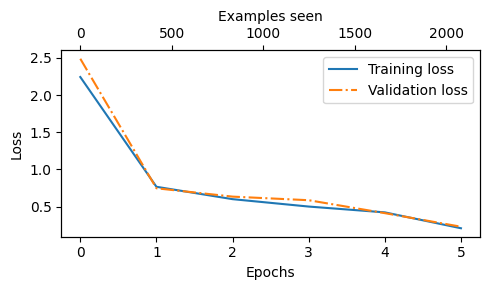

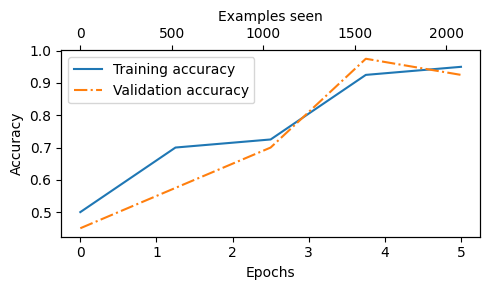

In [217]:
# x ekseni iki ölçekte gösterilecek: altta tur sayısı, üstte görülen örnek sayısı
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

# doğruluk listesi daha kısa: kayıp 50 adımda bir, doğruluk tur başına bir ölçüldü
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

<div class="alert alert-block alert-info">

İki grafikte bakılacak şey iki çizginin **arası**. Kayıp grafiğinde eğitim ve doğrulama eğrileri birlikte iniyor; doğrulama eğrisi yukarı dönseydi model eğitim cümlelerini ezberlemeye başlamış olurdu. Doğruluk grafiğinde iki çizgi merdiven gibi çıkıyor: her basamak bir turun sonundaki ölçüm — kayıp eğrisi altı noktadan geçerken doğruluk eğrisi beş noktadan geçiyor, çünkü ölçüm sıklıkları farklı.

</div>

#### Son ölçüm: bütün küme üzerinde

<div class="alert alert-block alert-success">

Bu kez `num_batches` verilmiyor: `calc_accuracy_loader` üç kümenin bütün yığınlarını okuyor. Eğitim boyunca gördüğümüz sayılar ilk beş yığınla alınmış tahminlerdi; karne bu hücrede.

</div>

In [218]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 94.95%
Validation accuracy: 93.33%
Test accuracy: 92.50%


<div class="alert alert-block alert-info">

Karne: eğitim %94.95, doğrulama %93.33, test %92.50. Üçü birbirine yakın — model konuyu öğrendi, cümleleri ezberlemedi.

Ağırlığı olan sayı test: o 120 cümle ne eğitimde ağırlık güncelledi ne ayar kararına girdi. %50 zeminden %92.50'ye çıkan şey 420 örnek ve parametrelerin %5.7'si.

</div>

#### Yeni bir cümleyi sınıflandır

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** `classify_text` tek bir cümleyi `TopicDataset`'in yaptığı üç işten geçiriyor: token'a çevirme, pencereye kesme, `max_length`'e doldurma.

**Neden aynı üç iş:** model eğitimde 21 kolonluk satırlar gördü ve kararı son kolondan okudu. Tek cümle de aynı biçimde gelmezse son kolon başka bir yere denk düşer, karar bozulur. Eğitim ile çıkarım (Inference) aynı hazırlığı paylaşmak zorunda.

</div>

In [219]:
def classify_text(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    # pos_emb ağırlığı (1024, 768): shape[0] pencere uzunluğu, shape[1] vektör boyu verirdi
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]   # fazlası kesilir
    input_ids += [pad_token_id] * (max_length - len(input_ids))         # uzunluk max_length
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)  # -> (1, max_length)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]   # (1, max_length, 2) -> (1, 2)
    predicted_label = torch.argmax(logits, dim=-1).item()   # (1, 2) -> 0 ya da 1
    return "physics" if predicted_label == 1 else "biology"

<div class="alert alert-block alert-success">

Eğitimde hiç görülmemiş altı cümle — üçü biyoloji, üçü fizik. Ölçüm değil gözle bakma: öğrenilenin konu ayrımı olup olmadığı ancak yeni cümlelerde görünür.

Çıktıda altıncı satıra da bak: ısı iletimi hakkındaki cümle `biology` geliyor. Test doğruluğu %92.50, yani ortalama on üç cümleden biri yanlış — altılık bir örneklemde bir hata görmek bu orana uygun. Kararın kendisi iki sayının karşılaştırılmasıdır; kesinlik değil.

</div>

In [220]:
samples = [
    "The enzyme breaks down starch into simpler sugars.",
    "A charged particle moving through a magnetic field feels a sideways force.",
    "Chloroplasts in the leaf capture sunlight.",
    "The pendulum swings more slowly when the string is made longer.",
    "White blood cells attack bacteria that enter a wound.",
    "Heat spreads through the metal bar by conduction.",
]

for sentence in samples:
    prediction = classify_text(sentence, model, tokenizer, device, max_length=train_dataset.max_length)
    print(f"{prediction:8s} <- {sentence}")

biology  <- The enzyme breaks down starch into simpler sugars.
physics  <- A charged particle moving through a magnetic field feels a sideways force.
biology  <- Chloroplasts in the leaf capture sunlight.
physics  <- The pendulum swings more slowly when the string is made longer.
biology  <- White blood cells attack bacteria that enter a wound.
biology  <- Heat spreads through the metal bar by conduction.


#### Uzmanı kaydet

<div class="alert alert-block alert-success">

`state_dict` ağırlıkları diske yazıp geri yüklüyor: eğitim bir kez yapılır, dosya sonra kullanılır.

Yükleme yalnız **aynı mimariyle** kurulmuş bir modele yapılabilir — dosyada katman adları ve şekilleri var, mimari yok. `out_head` 50 257 çıkışlı bir modele bu dosya girmez.

</div>

In [221]:
torch.save(model.state_dict(), "_data/topic_classifier.pth")

model.load_state_dict(torch.load("_data/topic_classifier.pth"))

<All keys matched successfully>

<div class="alert alert-block alert-info">

Sınıflandırma hattı bitti. Sıradaki instruction finetuning aynı gövdeyi başka bir veri kümesiyle yeniden yükleyecek.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-15" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 15 · Instruction Finetuning: Template, Maske, DataLoader

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-14">←</a> <a href="vscode-notebook-cell:?execution_count=199&line=1">Ders 14</a>  ·  <a href="vscode-notebook-cell:?execution_count=241&line=1">Ders 16</a> <a href="#ders-16">→</a></sub>

In [222]:
lesson(15, "Instruction Finetuning: Template, Maske, DataLoader")

Ders 15 · Instruction Finetuning: Template, Maske, DataLoader   ·   1.3 dk


Ön eğitim modeline soru sorarsan devamını yazar, cevap vermez — öğrendiği şey metni sürdürmektir. **Instruction finetuning** ona talimat–cevap kalıbını öğretir.

Üç iş: **prompt template** talimatı hep aynı biçimde verir (Alpaca kalıbı). Sonra tuzak — dolgu kayba girerse model boşluk üretmeyi öğrenir; `ignore_index = -100` dolguyu kayıptan çıkarır, ama **bir tanesi** bilerek kalır: model durmayı ondan öğrenir. Üçüncüsü bu mantığı taşıyan dataloader'ları kurmak.

<hr id="konu-15-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Instruction Finetuning (Talimat İnce Ayarı): Modeli Asistana Dönüştüren Adım

Asistanın hammaddesi ön eğitimdeki gibi uzun bir metin değil, talimat–cevap çiftlerinden oluşan bir liste. Bu ders o listeyi açıp içine bakıyor: kaç kayıt var, bir kaydın alanları neler.

#### Veri kümesi

<div class="alert alert-block alert-success">

Ön eğitimde veri tek uzun metindi ve hedef bir sonraki token'dı. Burada veri **kayıt** listesi ve her kaydın kendi doğru cevabı var.

Üç alan ayrı ayrı duruyor: `instruction` ne yapılacağını, `input` üstünde çalışılacak malzemeyi, `output` beklenen cevabı taşır. Ayrı durmaları şart: sıradaki konu üçünü sabit bir kalıba oturtacak.

`data_path(...)` dosyayı `_data/` altında arıyor — defter veri indirmez, arar.

</div>

In [223]:
with open(data_path("instruction-data.json"), "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of entries:", len(data))

Number of entries: 1100


In [224]:
print("Example entry:\n", data[50])
print("Another example entry:\n", data[999])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


<div class="alert alert-block alert-info">

`input` alanı 1 100 kaydın 775'inde boş (%70.45), 325'inde dolu — ikinci çıktıda boş dizgi. Boş `input` uç durum değil, kuralın kendisi: şablon onu doğal karşılamalı.

</div>

<hr id="konu-15-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Prompt Template (Alpaca): Talimatı Modele Nasıl Yazarız?

Üç alanlı kayıt modele tek bir metin olarak girmek zorunda. Prompt Template (istem kalıbı) o çeviriyi yapar: hangi alan nereye, hangi işaretle yazılacak. Ders kalıbı kuruyor, iki kayıtta gösteriyor, sonra kümeyi üç dilime kesiyor.

#### `format_input`

<div class="alert alert-block alert-success">

Şablon sabit başlık cümlesi + `### Instruction:` bölümü; `input` doluysa `### Input:` bölümü de eklenir, boşsa yazılmaz.

Kalıbın **sabit** olması şart: model "talimat bitti, cevap başlıyor" ayrımını hep aynı yerde duran bu bölüm işaretlerinden öğrenir. Bedeli kayıt başına 30 token, `input` dolu kayıtlarda 36.

Cevap ayrıca ekleniyor: üretimde cevap elimizde olmayacak.

</div>

In [225]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

<div class="alert alert-block alert-success">

Şablon iki kayıtta: birincide `### Input:` var, ikincide yok.

</div>

In [226]:
for i in (50, 999):
    print(format_input(data[i]) + f"\n\n### Response:\n{data[i]['output']}")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


#### %85 / %5 / %10 bölme

<div class="alert alert-block alert-success">

İlk iki dilim `int(...)` ile, üçüncüsü **kalandan** çıkıyor: üçünü de yuvarlasak toplam kümeden sapardı (935 + 55 + 110 = 1 100). Dilimler listenin sırasından kesiliyor; karıştırma `DataLoader`'da yapılacak.

</div>

In [227]:
train_portion = int(len(data) * 0.85)   # %85 eğitim
test_portion = int(len(data) * 0.1)     # %10 test
val_portion = len(data) - train_portion - test_portion   # kalan %5 doğrulama

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


<div class="alert alert-block alert-info">

935 · 55 · 110. Doğrulama en küçük parça — işi öğrenmek değil eğriyi izlemek; test hükmü verecek küme, o yüzden doğrulamanın iki katı.

</div>

<hr id="konu-15-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Dolgu Token'ları Loss'u Bozuyor: ignore_index ile Maskeleme

Bu bölümün en teknik dersi. Talimat metinleri çok farklı uzunlukta olduğu için yığın kurmak sınıflandırma hattından daha zor. Çözümü üç taslakta inşa ediyoruz: her taslak bir sorunu çözüyor, bir sonrakini ortaya çıkarıyor.

#### Dolgu token'ı

<div class="alert alert-block alert-success">

GPT-2'nin ayrı bir padding token'ı yok — sözlükteki tek özel token `<|endoftext|>`. Dolgu için onu kullanıyoruz: yeni bir ID eklemek embedding katmanını büyütür ve hazır ağırlıklarla uyumu bozar.

</div>

In [228]:
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


#### Taslak 1: dolgu ekle

<div class="alert alert-block alert-success">

Tensör dikdörtgen olmak zorunda: 5, 2 ve 3 uzunluğundaki üç oyuncak dizi aynı boya gelmeden `torch.stack` çalışmaz. Kısa satırların artanına padding token'ı yazılıyor.

`batch_max_length` en uzun diziye **1 ekliyor**: satır sonuna bir bitiş token'ı girecek. `padded[:-1]` o fazla hücreyi geri atıyor — taslak 2'de gerekecek.

</div>

In [229]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # şekil izi:  b = yığındaki dizi sayısı · L = en uzun dizinin uzunluğu
    # Yığındaki en uzun diziyi bul, +1 ekle (fazladan bir dolgu token'ı için)
    batch_max_length = max(len(item)+1 for item in batch)   # = L + 1

    # Dolgu ekle ve girdileri hazırla
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Sona bir <|endoftext|> ekle
        new_item += [pad_token_id]
        # Yığının en uzun dizisine hizala: padded uzunluğu L + 1
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # padded[:-1] ile +1'den gelen fazladan dolgu token'ını atıyoruz
        # (o fazladan token taslak 2'de işe yarayacak)
        inputs = torch.tensor(padded[:-1])   # (L,)
        inputs_lst.append(inputs)

    # Listeyi tensöre çevir ve cihaza taşı
    inputs_tensor = torch.stack(inputs_lst).to(device)   # b × (L,) -> (b, L)
    return inputs_tensor

In [230]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))   # (3, 5) = 3 dizi × 5 token

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


<div class="alert alert-block alert-info">

Üçü de 5 uzunluğa geldi, boşluklar 50256 ile doldu. 3 × 5 = 15 hücrenin 10'u gerçek token, 5'i dolgu.

</div>

#### Taslak 2: hedefi de üret

<div class="alert alert-block alert-success">

Aynı diziden iki tensör dilimleniyor:

- `inputs = padded[:-1]` → son token atılır
- `targets = padded[1:]` → ilk token atılır

Bir token kaymışlar: `inputs`'un i. konumunda tahmin edilecek şey `targets`'ın i. konumudur. Kaydırma hizalamadan **sonra** olmak zorunda; önce olsaydı satır sonları karışırdı.

Ama dolgu token'ları hedefe de geçiyor. Sayılar gerçek ID değil, sırayla verildi — dolgu ancak böyle izlenir.

</div>

In [231]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # şekil izi:  b = yığındaki dizi sayısı · L = en uzun dizinin uzunluğu
    # Yığındaki en uzun diziyi bul
    batch_max_length = max(len(item)+1 for item in batch)   # = L + 1

    # Girdi ve hedefleri hazırla
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Sona bir <|endoftext|> ekle
        new_item += [pad_token_id]
        # En uzun diziye hizala: padded uzunluğu L + 1
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])   # (L,) girdi: son token atılır
        targets = torch.tensor(padded[1:])   # (L,) hedef: bir token sağa kaymış
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Listeleri tensöre çevir ve cihaza taşı
    inputs_tensor = torch.stack(inputs_lst).to(device)   # b × (L,) -> (b, L)
    targets_tensor = torch.stack(targets_lst).to(device)   # aynı şekil: (b, L)
    return inputs_tensor, targets_tensor

In [232]:
# batch taslak 1'in deneme hücresinde kuruldu: ([0,1,2,3,4], [5,6], [7,8,9])
inputs, targets = custom_collate_draft_2(batch)   # ikisi de (3, 5)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


<div class="alert alert-block alert-info">

Girdide 5 dolgu vardı; hedefte 8 oldu — kaydırma her satıra bir dolgu daha ekliyor. 15 hedef hücresinin %53.3'ü dolgu, yani model bu hâlde öğrendiğinin yarısını "dolgu üret" olarak öğrenir.

</div>

#### Taslak 3: `-100` maskesi

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Taslak 2'nin gövdesi aynen duruyor; üstüne iki yeni blok biniyor, imzaya da iki parametre giriyor:

1. `ignore_index` → dolgu konumlarının **ilki hariç** hepsi bu değere döner
2. `allowed_max_length` → pencereye sığmayan kayıtları keser

Maskeyi üç satır kuruyor: `targets == pad_token_id` dolgu konumlarını işaretler, `torch.nonzero(...).squeeze()` onları konum listesine çevirir, `targets[indices[1:]] = ignore_index` listenin **ilkini atlayıp** kalanını eziyor. Kuralın tamamı o `[1:]` diliminde.

`indices.numel() > 1` dalı süs değil: tek dolgusu olan satırda hiçbir şey maskelenmez, çünkü o tek dolgu zaten kalması gereken bitiş token'ıdır. Çıktının ilk satırı bu durumda.

`-100` keyfî değil, `cross_entropy`'nin `ignore_index` varsayılanı: o konumlar ne toplama ne bölene girer. Yerine 0 yazsaydık maske değil yanlış bir hedef koyardık — "sıfırıncı token'ı tahmin et".

Bir dolgu bilerek bırakıldı: durmak da öğrenilen bir davranıştır ve model bir konumu ancak kayba girerse öğrenir. Biri yetiyor.

</div>

In [233]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # şekil izi:  b = yığındaki dizi sayısı · L = hizalama boyu (en uzun dizi kadar)
    # Yığındaki en uzun diziyi bul
    batch_max_length = max(len(item)+1 for item in batch)   # = L + 1

    # Girdi ve hedefleri hazırla
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Sona bir <|endoftext|> ekle
        new_item += [pad_token_id]
        # En uzun diziye hizala: padded uzunluğu L + 1
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])   # (L,) girdi: son token atılır
        targets = torch.tensor(padded[1:])   # (L,) hedef: bir token sağa kaymış

        # YENİ: ilk dolgu hariç bütün dolguları ignore_index (-100) yap
        mask = targets == pad_token_id   # (L,) bool: dolgu mu değil mi
        indices = torch.nonzero(mask).squeeze()   # (dolgu sayısı,) konum listesi
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # YENİ: istenirse en fazla şu uzunluğa kes
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]   # (L,) -> (min(L, allowed_max_length),)
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Tensöre çevir ve cihaza taşı
    inputs_tensor = torch.stack(inputs_lst).to(device)   # b × (L,) -> (b, L)
    targets_tensor = torch.stack(targets_lst).to(device)   # aynı şekil: (b, L)

    return inputs_tensor, targets_tensor

In [234]:
# batch taslak 1'in deneme hücresinde kuruldu: ([0,1,2,3,4], [5,6], [7,8,9])
inputs, targets = custom_collate_fn(batch)   # ikisi de (3, 5)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


<div class="alert alert-block alert-info">

8 dolgu hedefinin 5'i `-100` oldu, 3'ü kaldı: satır başına tam bir bitiş token'ı. Girdi tarafına hiç dokunulmadı — maske yalnız hedefi buduyor.

</div>

#### `-100` gerçekten çalışıyor mu?

<div class="alert alert-block alert-success">

Sınanan iddia: maske kaybı azaltmıyor, o konumu hesaptan tamamen çıkarıyor — azaltmak bölene saymayı sürdürürdü. Önce iki örnekli bir kayıp.

</div>

In [235]:
logits_1 = torch.tensor(   # (2, 2) = 2 örnek × 2 sınıf
    [[-1.0, 1.0],   # 1. örnek
     [-0.5, 1.5]]   # 2. örnek
)
targets_1 = torch.tensor([0, 1])   # (2,) örnek başına bir doğru sınıf


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


<div class="alert alert-block alert-success">

Üçüncü örnek ekleniyor. `loss_2`'nin hedefi normal, `cross_entropy` ortalama aldığı için sayı değişir; `loss_3`'te aynı logitler ama üçüncü hedef `-100` — o örnek ortalamaya girmez, sonuç `loss_1` ile **birebir** aynı çıkmalı.

</div>

In [236]:
logits_2 = torch.tensor(   # (3, 2) = 3 örnek × 2 sınıf
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]   # YENİ 3. örnek
)
targets_2 = torch.tensor([0, 1, 1])       # (3,) bölen artık 3
targets_3 = torch.tensor([0, 1, -100])    # (3,) ama etkin örnek sayısı 2

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(0.7936)
tensor(1.1269)
loss_1 == loss_3: tensor(True)


<div class="alert alert-block alert-info">

1.1269 → 0.7936 → 1.1269. Üçüncü örnek eklenince ortalama düştü (bölen 2'den 3'e çıktı); hedefi `-100` yapılınca ilk değere **birebir** döndü: `loss_1 == loss_3` → `True`. Maske o konumu bölene bile saymıyor.

</div>

<hr id="konu-15-4" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Instruction Dataloader'larını Kuruyoruz

Şablon ve gruplama fonksiyonu hazır. Şimdi ikisini `Dataset` ve `DataLoader` içine yerleştiriyoruz.

#### `InstructionDataset`

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Şablon ile gruplama arasındaki halka: `__init__` her kaydın tam metnini kuruyor (`format_input` + `### Response:` + `output`) ve ID listesine çeviriyor.

Kritik satır `return self.encoded_texts[index]`: **tensör değil, düz liste** dönüyor. Sebebi zorunluluk — bir kaydın kaç token'a hizalanacağı ancak yanına hangi kayıtların düştüğü bilinince belli olur, yani yığın kurulurken. Hizalama ve tensöre çevirme işi bu yüzden `collate_fn`'e kalıyor; `Dataset` yalnız ham uzunlukları taşıyor (40–91 token).

Talimat ile cevap **tek dizide** birleşiyor ve maskelenen tek şey dolgu: model hem cevabı üretmeyi hem kalıbı sürdürmeyi öğreniyor. Talimat konumlarını da maskelemek mümkündü — kalıbı öğrenmek işin parçası.

</div>

In [237]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Metinleri baştan token'lara çevir (turda bir daha kodlanmasın)
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)   # metin -> ID listesi (40-91 uzunlukta)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]   # düz Python listesi, tensör değil

    def __len__(self):
        return len(self.data)

#### Sabit parametreleri bağla

<div class="alert alert-block alert-success">

`DataLoader`, `collate_fn`'i tek argümanla çağırır; `device` ile `allowed_max_length` dışarıdan gelmeli, o yüzden baştan bağlanıyor.

`allowed_max_length=1024` bağlam penceresi — burada emniyet kemeri: en uzun kayıt 91 token, pencerenin %8.9'u, kesme hiç devreye girmiyor.

</div>

In [238]:
from functools import partial
customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

<div class="alert alert-block alert-success">

Üç yükleyici kuruluyor. Ayarlar bilinçli olarak simetrik değil:

- `shuffle` eğitimde açık (yığın sırası öğrenmeyi etkiler), ölçümde kapalı
- `drop_last` eğitimde açık (eksik son yığın adımı bozmasın), ölçümde kapalı

</div>

In [239]:
batch_size = 8   # yığın 8 satır; satır boyu (T) yığından yığına değişir

torch.manual_seed(123)

train_loader = DataLoader(
    InstructionDataset(train_data, tokenizer),
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    InstructionDataset(val_data, tokenizer),
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    InstructionDataset(test_data, tokenizer),
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)

<div class="alert alert-block alert-success">

Döngü eğitim yükleyicisini baştan sona gezip şekilleri topluyor. Bakılacak şey hizalama boyu (`T`): yığın başına hesaplandığı için sabit bir boy YOK — 116 yığını tek tek basmak yerine en küçüğü, en büyüğü ve ortalaması ölçülüyor.

</div>

In [240]:
shapes = [tuple(inputs.shape) for inputs, targets in train_loader]
T = [s[1] for s in shapes]   # her yığının hizalama boyu

print("Train loader:", len(shapes), "yığın")
print("ilk üç yığın:", *shapes[:3])
print(f"T: en kısa {min(T)} · en uzun {max(T)} · ortalama {sum(T) / len(T):.1f}")

Train loader: 116 yığın
ilk üç yığın: (8, 61) (8, 76) (8, 73)
T: en kısa 57 · en uzun 91 · ortalama 70.1


<div class="alert alert-block alert-info">

116 yığın: 935 eğitim kaydı 8'lik yığınlara bölününce 116 tam yığın kalıyor, artan 7 kayıt `drop_last=True` ile atılıyor (%0.75).

Hizalama boyu her yığında başka: en kısa 57, en uzun 91, ortalama 70.1 token. Sabit bir boy yok, çünkü hizalama yığın içinde yapılıyor — hepsini en uzun kayda (91) çekmek aynı işi %23 daha pahalı yapardı.

Maskenin gerçek ölçeği: bir tur 65 008 hedef hücresi ayırıyor, bunların %19.51'i `-100` ile kayıp dışında kalıyor. Geriye 928 örneğin metin token'ları ve örnek başına tam bir bitiş token'ı kalıyor — oyuncak 3 × 5'te gördüğümüz kural, 65 008 hücrede aynen bu.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-16" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 16 · Asistanı Eğit ve Cevaplarını Puanla

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-15">←</a> <a href="vscode-notebook-cell:?execution_count=222&line=1">Ders 15</a>  ·  <a href="vscode-notebook-cell:?execution_count=255&line=1">Ders 17</a> <a href="#ders-17">→</a></sub>

In [241]:
lesson(16, "Asistanı Eğit ve Cevaplarını Puanla")

Ders 16 · Asistanı Eğit ve Cevaplarını Puanla   ·   1.3 dk


Veri hazır, model hazır. Bu ders eğitimin kendisi ve sonucun ölçülmesi.

Önce eğitim öncesi cevabı görüyoruz — kötü olacak, ve bu bir çıpa. Sonra döngü koşuyor, kayıp iniyor, cevaplar düzeliyor. Son kısım en çok atlanan kısım: **ölçme**. "İyi görünüyor" bir ölçüm değildir; bütün test kümesini referansla karşılaştırıyoruz — kelime örtüşmesi (F1), boş cevap sayısı, uzunluk oranı — ve yanına bir taban çizgisi koyuyoruz.

<hr id="konu-16-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Pretrained Weights ile Başla: Modelin İlk (Kötü) Cevabı

Veri ve maske hazır; eksik olan model. Bu ders 355M'lik hazır ağırlıkları getirip **ince ayardan önce** bir talimat veriyor. Sonradan "düzeldi" diyebilmek için elde bir "önce" olması şart.

#### 355M ağırlıklarını indir

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Asistan üç parçadan çıkıyor: aynı model + talimat biçimli veri + maskeli kayıp. Veri ve maske önceki dersteydi; bu hücre birinci parçayı getiriyor.

Kurulan sınıf ders 9'da yazdığımız `GPTModel`; içinde tek satır değişmedi. Değişen yalnız sözlükteki üç ölçü: `emb_dim` 768 → 1 024, `n_layers` 12 → 24, `n_heads` 12 → 16. `CHOOSE_MODEL` bunu getiriyor, indirme 1 520 MB ve bir kez oluyor; dosya `_data/gpt2/355M/` altına yazılıyor.

Büyütmenin nedeni işin genişlemesi: sınıflandırma iki şıklı bir sınavdı, serbest cevapta model her konumda 50 257 aday arasından seçiyor.

Donuk (frozen) katman yok — ders 14'te gövdeyi dondurmuştuk, burada bütün ağ ince ayara giriyor.

</div>

In [242]:
BASE_CONFIG = {
    "vocab_size": 50257,     # sözlük boyu
    "context_length": 1024,  # bağlam penceresi
    "drop_rate": 0.0,        # dropout kapalı
    "qkv_bias": True         # gerçek GPT-2 ağırlıkları bias içeriyor
}

CHOOSE_MODEL = "gpt2-medium (355M)"   # model_configs sözlüğü ders 12'de kuruldu

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
_, params = download_and_load_gpt2(model_size=model_size, models_dir="_data/gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()
model.to(device);          # GPU varsa modeli de oraya taşı

print("model boyu:", f"{sum(p.numel() for p in model.parameters()):,}".replace(",", " "), "parametre")

355M ağırlıkları indiriliyor (openai-community/gpt2-medium)...


      153 / 1520 MB

      304 / 1520 MB

      457 / 1520 MB

      608 / 1520 MB

...

     1065 / 1520 MB

     1216 / 1520 MB

     1369 / 1520 MB

     1520 / 1520 MB
  kaydedildi: _data/gpt2/355M/model.safetensors


model boyu: 406 286 336 parametre


#### Şablona sokulmuş bir talimat ver

<div class="alert alert-block alert-success">

Doğrulama kümesinin ilk kaydı şablona konup modele veriliyor; aynı kayıt dersin sonunda tekrar sorulacak — "düzeldi" demek için **eğitimden önceki** cevap elde olmalı.

`input` boş, o yüzden `### Input:` bölümü yok; istem 41 token.

</div>

In [243]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


<div class="alert alert-block alert-success">

`generate` çağrılıyor; girdi tensörü `device`'a taşınıyor — model GPU'da, girdi CPU'da kalırsa PyTorch hata verir.

`eos_id=50256` üretimi erken kesebilir ama model bitiş işaretini henüz öğrenmedi; 35 token'ın sonuna kadar gidiyor. Son iki satır istemi kesip cevabı bırakıyor.

</div>

In [244]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),   # (1, 41) istem
    max_new_tokens=35,   # çıkış en fazla (1, 41 + 35) = (1, 76)
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

# İstemi kes, yalnız cevabı bırak
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


<div class="alert alert-block alert-info">

Model istenen dönüşümü yapmıyor: cümleyi geri yazıyor, sonra yeni bir `### Instruction:` bölümü açıp metni sürdürüyor. Kalıbı taklit ediyor ama işi yapmıyor — eksik olan bilgi değil alışkanlık.

</div>

<hr id="konu-16-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Finetuning Training Loop: Loss Eğrisi Nereye İner?

Sınıflandırmada tek bir konumun kaybı yetiyordu; serbest cevapta her token bir karardır. Bu ders kaybı o hâline geri alıyor, modeli bir tur eğitiyor ve iki eğrinin nereye indiğine bakıyor.

#### Kayıp fonksiyonunu geri al

<div class="alert alert-block alert-success">

Bu hücre tekrar değil, **geri alma** — tek bir satırı geri alıyor:

- ders 14: `logits = model(input_batch)[:, -1, :]` → yalnız son konum
- ders 16: `logits = model(input_batch)` → her token kendi kaybını taşır

Serbest cevapta karar sayısı cevabın uzunluğu kadardır: onuncu kelime yanlışsa bunu ölçen tek yer o konumun kendi puanıdır. Dolgu konumları yine kayba girmiyor — `-100` onları işaretledi.

`calc_loss_loader` ile `train_model_simple` yeniden tanımlanmıyor; `calc_loss_batch`'i adıyla çağırdıkları için aşağıdaki sürümü kullanacaklar.

</div>

In [245]:
# şekil izi:  b = yığın satırı (8) · T = yığının hizalama boyu · V = 50257 (sözlük boyu)


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)   # (b, T) -> (b, T, V)
    # cross_entropy iki boyut bekler: (b, T, V) -> (b*T, V) ve (b, T) -> (b*T,)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

<div class="alert alert-block alert-success">

İnce ayardan önceki kayıp: eğitimin ne kadar yol aldığını görmek için başlangıç noktası. `num_batches=5` bütün kümeyi taramıyor — gereken kesin bir sayı değil, karşılaştırılabilir bir çıpa.

</div>

In [246]:
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.82590913772583
Validation loss: 3.7679300785064695


<div class="alert alert-block alert-info">

Başlangıç noktası: eğitim 3.826, doğrulama 3.768. İkisinin yakın olması beklenen şey — model henüz bu kümeden hiçbir şey görmedi, iki dilim onun için de aynı derecede yabancı. Dersin sonunda doğrulama 0.668'e inecek.

</div>

#### Eğit

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Döngünün kendisi ders 10'da yazıldı; burada yalnız çağrılıyor. Yeni olan üç ayar:

`lr=0.00005`, ön eğitimdeki `0.0004`'ün sekizde biri: hazır ağırlıkların bilgisini koruyoruz, büyük adım öğrenileni siler.

`num_epochs=1`: 935 kayıt, 8'lik yığın, 116 güncelleme adımı. `eval_freq=5` ile beş adımda bir, beş yığınla (`eval_iter=5`) ölçüm alınıyor — 24 satırlık günlük buradan çıkıyor.

`start_context=format_input(val_data[0])`: her turun sonunda aynı talimat modele soruluyor, böylece günlüğün son satırı sayı değil cevap oluyor.

**Bu hücre CPU'da uzun sürer** (355M model).

</div>

In [247]:
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 1

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.631


Ep 1 (Step 000005): Train loss 1.175, Val loss 1.105


Ep 1 (Step 000010): Train loss 0.872, Val loss 0.946


Ep 1 (Step 000015): Train loss 0.854, Val loss 0.910


Ep 1 (Step 000020): Train loss 0.777, Val loss 0.885


...

Ep 1 (Step 000100): Train loss 0.503, Val loss 0.681


Ep 1 (Step 000105): Train loss 0.570, Val loss 0.676


Ep 1 (Step 000110): Train loss 0.559, Val loss 0.671


Ep 1 (Step 000115): Train loss 0.513, Val loss 0.668


Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The meal is prepared every day by the chef.<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive:


<div class="alert alert-block alert-info">

Günlükte iki sayı yan yana iniyor. En büyük sıçrama ilk beş adımda: `Train loss` 2.637'den 1.175'e, `Val loss` 2.631'den 1.105'e. Model yeni bilgi öğrenmiyor, kalıbı öğreniyor — "talimat bitti, cevap başlıyor" ayrımı ucuz ve hızlı.

Son satır bir sayı değil, turun sonunda üretilen cevap. Veri kümesindeki doğru cevap şu: *The meal is cooked by the chef every day.* Modelin buna ne kadar yaklaştığına bak — ve arkasından `<|endoftext|>` basıp yeni bir bölüm açtığına: durmayı öğrenmiş, ama sonrasını kesen bir şey yok.

</div>

#### Kayıp eğrisi

<div class="alert alert-block alert-success">

Eğride bakılacak şey iki çizginin arası: eğitim kaybı doğrulamanın belirgin biçimde altına inip ayrılırsa model kümeyi ezberlemeye başlamış olur.

</div>

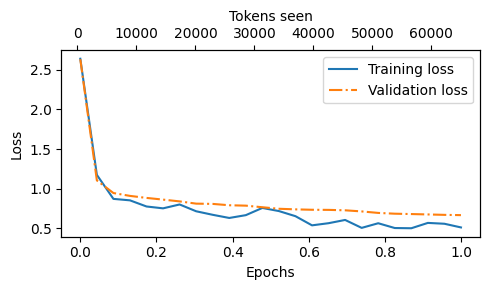

In [248]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

<div class="alert alert-block alert-info">

Kesikli doğrulama eğrisi hiçbir yerde yukarı kıvrılmıyor: 2.631'den 0.668'e iniyor ve koşu bittiğinde **hâlâ** iniyor. Yani ikinci bir tur daha kazanç getirebilirdi — durma kararı eğriye değil bütçeye dayanıyor.

</div>

<hr id="konu-16-3" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Cevapları Üret ve Puanla: Modelimiz Ne Kadar İyi?

Eğitim bitti. Şimdi asıl soru: **oldu mu?** Test kümesinin 110 kaydı için cevap üretiyoruz, referansla yan yana koyuyoruz ve üç şeffaf sayıyla ölçüyoruz.

#### Üç örnek: talimat, doğru cevap, modelin cevabı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** `answer()` bir kaydı baştan sona geçiriyor: şablona sok, ID'ye çevir, `generate` ile üret, sonucu geri metne çevir, istemi kes.

İki kritik satır var. `idx=text_to_token_ids(...).to(device)` girdiyi modelin durduğu yere taşıyor. `generated_text[len(input_text):]` ise istemi kesiyor: `generate` istemi ve cevabı **tek dizi** olarak döndürür, cevap ancak istemin karakter uzunluğundan sonrası olarak ayrılabilir.

Aynı yardımcıyı bir sonraki hücre 110 kayıt için çağıracak. Ölçmeden önce göz: bir sayı neyin bozuk olduğunu söylemez.

</div>

In [249]:
torch.manual_seed(123)


def answer(entry, max_new_tokens=256):
    """Kaydı şablona sokup modele cevap ürettirir; (istem, cevap) döndürür."""
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=max_new_tokens,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    return input_text, generated_text[len(input_text):].replace("### Response:", "").strip()


for entry in test_data[:3]:
    input_text, response_text = answer(entry)
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of storm that typically produces thunderstorms.
-------------------------------------


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is George Bernard Shaw.
-------------------------------------


<div class="alert alert-block alert-info">

Dersin başındaki (eğitim öncesi) çıktıyla karşılaştır: model artık talimatı tekrarlamıyor, cevap verip duruyor. Kalıp öğrenildi.

Ama biçim düzeldi diye içerik doğru olmuyor. Üçüncü kaydın talimatı *Name the author of 'Pride and Prejudice'* ve veri kümesindeki doğru cevap tek kelime: *Jane Austen.* Modelin yazdığı ada bak — cümle kalıbı kusursuz, ad yanlış. Kalıbı öğrenmek olguyu öğrenmek değildir; 935 kayıt biçim öğretmeye yeter, dünya bilgisi öğretmeye yetmez.

</div>

#### 110 test kaydının tamamı

<div class="alert alert-block alert-success">

Aynı `answer()` bütün test kümesinde: 110 kayıt × en fazla 256 token, yani en fazla 28 160 üretim adımı. **CPU'da uzun sürer**; `tqdm` ilerlemeyi gösterir.

Cevaplar iki yere gidiyor: `test_data` sözlüklerine `model_response` anahtarıyla (puanlama hücresi buradan okuyacak) ve bir JSON dosyasına (defter kapanınca kaybolmaması için). Son satır ilk kaydı basıyor — artık dört anahtarlı.

</div>

In [250]:
from tqdm import tqdm

# mininterval=20: ilerleme çubuğu 20 saniyede bir yenilenir; defterde yüzlerce
# satırlık döküm yerine birkaç satır kalır.
for i, entry in tqdm(enumerate(test_data), total=len(test_data), mininterval=20):
    test_data[i]["model_response"] = answer(entry)[1]


with open("_data/instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

print(test_data[0])

  0%|          | 0/110 [00:00<?, ?it/s]

 36%|███▋      | 40/110 [00:20<00:35,  1.96it/s]

 36%|███▋      | 40/110 [00:39<00:35,  1.96it/s]

 64%|██████▎   | 70/110 [00:40<00:23,  1.69it/s]

 64%|██████▎   | 70/110 [01:00<00:23,  1.69it/s]

 77%|███████▋  | 85/110 [01:00<00:19,  1.26it/s]

 77%|███████▋  | 85/110 [01:20<00:19,  1.26it/s]

 95%|█████████▌| 105/110 [01:22<00:04,  1.11it/s]

100%|██████████| 110/110 [01:24<00:00,  1.30it/s]

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


#### Puanlama

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Üç fonksiyon: `words` metni kelimelere böler, `overlap_score` tek bir cevabı referansla karşılaştırır, `score_responses` aynı hesabı 110 kayıt için toplar. Hiçbiri dışarıdan model çağırmıyor — judge (hakem) modelin bedeli para, ağ ve tekrarlanamazlıktır; burada aynı girdi her koşuda aynı sayıyı verir.

`overlap_score` iki ayak üstünde duruyor ve ikisi kasten simetrik değil:

- `precision = hit / len(cand)` — cevabın kelime **listesi** üstünde sayılıyor, yani aynı kelimeyi üç kez yazan cevap üç kez sayılır
- `recall = len(ref_set & set(cand)) / len(ref_set)` — **kümeler** üstünde, tekrar sayılmaz

İkisini `F1` birleştiriyor; harmonik ortalama olması şart. Aritmetik olsaydı referansı içine gömen upuzun bir cevap yüksek not alırdı: recall 1'e giderken precision'ın çöküşünü aritmetik ortalama affeder, harmonik affetmez.

Ölçtüğü şey "cevap referansla aynı kelimeleri kullanıyor mu"; ölçmediği "cevap doğru mu". Eş anlamlıyı yanlış sayar, kelime sırasını hiç görmez.

</div>

In [251]:
def words(text):
    return re.findall(r"[a-z0-9']+", str(text).lower())


def overlap_score(reference, candidate):
    """Referans ile cevabın kelime örtüşmesi: 0 (hiç) - 100 (tam)."""
    ref, cand = words(reference), words(candidate)
    if not ref or not cand:
        return 0.0
    ref_set = set(ref)
    hit = sum(1 for w in cand if w in ref_set)
    precision = hit / len(cand)
    recall = len(ref_set & set(cand)) / len(ref_set)
    if precision + recall == 0:
        return 0.0
    return 100 * 2 * precision * recall / (precision + recall)   # F1


def score_responses(entries, key="model_response"):
    scores, empty, ratios = [], 0, []
    for e in entries:
        cand = str(e.get(key, "")).strip()
        if not cand:
            empty += 1
        scores.append(overlap_score(e["output"], cand))
        ref_len = max(1, len(words(e["output"])))
        ratios.append(len(words(cand)) / ref_len)
    return {
        "mean_overlap": sum(scores) / len(scores),
        "empty_answers": empty,
        "total": len(entries),
        "length_ratio": sum(ratios) / len(ratios),
        "scores": scores,
    }

<div class="alert alert-block alert-success">

Aynı üç ölçü iki kez: `model_response` ve `baseline_response` için — bir sayı ancak neye göre iyi olduğu bilindiğinde anlam taşır.

Taban kasten güçlü: cevap yerine talimatın kendisi. Boş cevaplı bir taban kazancı şişirirdi.

</div>

In [252]:
# Taban çizgisi: cevap yerine talimatın kendisini vermek
for e in test_data:
    e["baseline_response"] = e["instruction"]

result = score_responses(test_data, key="model_response")
baseline = score_responses(test_data, key="baseline_response")

print(f"test kaydı                : {result['total']}")
print(f"boş cevap                 : {result['empty_answers']}")
print(f"uzunluk oranı (cevap/ref) : {result['length_ratio']:.2f}")
print()
print(f"ortalama örtüşme · model  : {result['mean_overlap']:.1f} / 100")
print(f"ortalama örtüşme · taban  : {baseline['mean_overlap']:.1f} / 100")
print()
exact = sum(1 for s in result["scores"] if s >= 80)
half = sum(1 for s in result["scores"] if 40 <= s < 80)
bad = sum(1 for s in result["scores"] if s < 40)
print(f"iyi (>=80)    : {exact:3d} cevap")
print(f"kısmi (40-80) : {half:3d} cevap")
print(f"zayıf (<40)   : {bad:3d} cevap")

test kaydı                : 110
boş cevap                 : 0
uzunluk oranı (cevap/ref) : 1.85

ortalama örtüşme · model  : 58.8 / 100
ortalama örtüşme · taban  : 39.9 / 100

iyi (>=80)    :  42 cevap
kısmi (40-80) :  32 cevap
zayıf (<40)   :  36 cevap


<div class="alert alert-block alert-info">

Üç sayı birlikte okunur: ortalama örtüşme **58.8**, taban **39.9** — 18.9 puan (1.47 kat) fark. Boş cevap 0: model 110 kaydın hepsinde bir şey yazdı. Uzunluk oranı 1.85, yani cevaplar referansın neredeyse iki katı uzunlukta — fazla kelime `precision` değerini aşağı çeker.

Ortalama dağılımı saklıyor: 42 iyi, 32 kısmi, 36 zayıf. "Ortalama 58.8" ile "cevapların üçte biri zayıf" aynı koşunun iki yüzü. Sıradaki hücre iki uçtan üçer örnek basıyor.

</div>

In [253]:
scored = sorted(zip(result["scores"], test_data), key=lambda t: t[0])

def show_row(header, records):
    print("=" * 70)
    print(header)
    print("=" * 70)
    for score, e in records:
        print(f"\ntalimat   : {e['instruction']}")
        if e["input"]:
            print(f"girdi     : {e['input']}")
        print(f"referans  : {e['output']}")
        print(f"model     : {e['model_response']}")
        print(f"örtüşme   : {score:.1f}")

show_row("EN İYİ ÜÇ CEVAP", scored[-3:][::-1])
print()
show_row("EN ZAYIF ÜÇ CEVAP", scored[:3])

EN İYİ ÜÇ CEVAP

talimat   : What is the molecular formula for water?
referans  : The molecular formula for water is H2O.
model     : The molecular formula for water is H2O.
örtüşme   : 100.0

talimat   : What is the opposite of 'horizontal'?
referans  : The opposite of 'horizontal' is 'vertical'.
model     : The opposite of 'horizontal' is 'vertical'.
örtüşme   : 100.0

talimat   : What is an antonym of 'complicated'?
referans  : An antonym of 'complicated' is 'simple'.
model     : An antonym of 'complicated' is 'simple'.
örtüşme   : 100.0

EN ZAYIF ÜÇ CEVAP

talimat   : Name the author of 'Pride and Prejudice'.
referans  : Jane Austen.
model     : The author of 'Pride and Prejudice' is George Bernard Shaw.
örtüşme   : 0.0

talimat   : Translate 'Hello' into Russian.
referans  : Привет (Privet)
model     : Собрания призвать призвать.
örtüşme   : 0.0

talimat   : Generate a past-tense verb that describes a person laughing.
referans  : Laughed.
model     : The past-tense verb 'laugh' is

<div class="alert alert-block alert-info">

Üstteki üç cevap 100.0: referansla birebir aynı kelimeler. Üçünün de referansı talimatın yeniden yazımı artı tek bir olgu (*An antonym of 'complicated' is 'simple'.*) — modelin ezberlemesi en kolay biçim.

Alttaki üç 0.0 ise ölçünün kendi sınırını gösteriyor, üç ayrı sebeple:

- referans *Jane Austen.* — model doğru kalıpta yanlış ad verdi; ölçü içeriği gördü
- referans *Привет (Privet)* — `words` deseni `[a-z0-9']+` yalnız ASCII harf tanıyor. Kiril alfabesiyle yazılmış bir cevapta tek kelime bile bulamaz, liste boş kalır ve fonksiyon baştaki `if not ref or not cand` dalından `0.0` döner. Puan içerikle değil desenle ilgili
- referans *Laughed.* — tek kelimelik referansta `recall`'ın böleni 1'dir: ya tam tutar ya sıfır, arası yok

Üçünden yalnız birincisi modelin hatası. Bir ölçü kullanmanın şartı, hangi sıfırın kimin sıfırı olduğunu bilmek.

</div>

#### Uzmanı kaydet

<div class="alert alert-block alert-success">

Dosya adı modelin adından üretiliyor: boşluk ve parantezler atılıp sonuna `-sft.pth` ekleniyor. `-sft` eki bilinçli — aynı dizinde ders 14'ün sınıflandırıcısı da duruyor.

</div>

In [254]:
file_name = f"_data/{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Geri yüklemek için:
# model.load_state_dict(torch.load("_data/gpt2-medium355M-sft.pth"))

Model saved as _data/gpt2-medium355M-sft.pth


<div class="alert alert-block alert-info">

Çıktı `_data/gpt2-medium355M-sft.pth` diyor: aynı dizinde ders 14'ün sınıflandırıcısıyla birlikte artık iki ağırlık dosyası duruyor. İkisi de ders 9'un `GPTModel` iskeletinden çıktı. Sınıflandırıcının çıkış katmanı iki sınıfa indirilmiş ve gövdesinin %94'ü donuktu; asistanın çıkışı 50 257 aday geniş kaldı ve parametrelerin %100'ü eğitildi. Fark mimaride değil, verinin biçiminde ve kaybın neyi saydığında.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>

<hr id="ders-17" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

## Ders 17 · Kapanış: Ne Yazdık, Sırada Ne Var

<sub><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekiler</a>  ·  <a href="#ders-16">←</a> <a href="vscode-notebook-cell:?execution_count=241&line=1">Ders 16</a></sub>

In [255]:
lesson(17, "Kapanış: Ne Yazdık, Sırada Ne Var")

Ders 17 · Kapanış: Ne Yazdık, Sırada Ne Var   ·   4.7 dk


Baştan sona ne yaptığımızı topluyoruz: hangi kutuyu biz yazdık, hangi sayı nereden geldi, akıcı metnin kaynağı neydi. Sonra buradan sonrası: modern LLM'lerin bu iskeletin üzerine eklediği parçalar — **RoPE** (konum bilgisini başka türlü kodlayan yöntem), **KV-cache** (üretimi hızlandıran bellek), **MoE** (her token için modelin yalnız bir kısmını çalıştırmak) ve daha fazlası. Hiçbiri buradaki temeli değiştirmiyor; hepsi onun üstüne biniyor.

<hr id="konu-17-1" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Baştan Sona Özet: Sıfırdan Yazdığımız LLM'in Tamamı

Ders 2'den 16'ya kadar yazdığımız her parça hâlâ bu defterin belleğinde: defter 17 ayrı program değil, baştan sona tek bir çekirdek. Aşağıdaki üç hücre parçaları tek tek arayıp buluyor, zinciri tek akışta çalıştırıyor ve modelin ölçülerini basıyor.

#### Yazdığımız sınıflar ve fonksiyonlar

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Hücrenin 29 satırı veri: her satır bir parça, geldiği ders ve işi. Altındaki birkaç satır o listeyi basıyor.

Kritik satır `name in globals()`: hücre iddia etmiyor, **sınıyor**. Çekirdeğin ad tablosunda o ad duruyorsa `✓`, durmuyorsa `·` basılıyor — yani `·` kalan her satır atlanmış bir hücreyi işaret eder. Ders 2'nin tokenizer'ı ile ders 16'nın puanlayıcısının aynı listede `✓` alması, aradaki 15 dersin birbirinin üstüne bindiğinin kanıtı.

</div>

In [256]:
PARTS = [
    ("SimpleTokenizerV1", "ders 2", "metni token'lara ayırır, ID verir"),
    ("SimpleTokenizerV2", "ders 2", "bilinmeyen token'ı <|unk|> ile karşılar"),
    ("GPTDatasetV1", "ders 3", "kayan pencereyle girdi-hedef çiftleri üretir"),
    ("create_dataloader_v1", "ders 3", "örnekleri yığın yığın servis eder"),
    ("softmax_stable", "ders 4", "sayısal olarak güvenli softmax"),
    ("SelfAttention_v1", "ders 5", "sorgu-anahtar-değer, elle parametrelerle"),
    ("SelfAttention_v2", "ders 5", "aynısı, nn.Linear ile"),
    ("CausalAttention", "ders 6", "geleceğe bakmayı yasaklar, dropout ekler"),
    ("MultiHeadAttentionWrapper", "ders 6", "birden çok başı yan yana koyar"),
    ("MultiHeadAttention", "ders 6", "başları tek matriste böler — GPT'nin sınıfı"),
    ("LayerNorm", "ders 7", "her token'ı ortalama 0, varyans 1'e ölçekler"),
    ("GELU", "ders 7", "pürüzsüz doğrusal olmayan geçiş"),
    ("FeedForward", "ders 7", "768 -> 3072 -> 768"),
    ("ExampleDeepNeuralNetwork", "ders 8", "kaybolan gradyan deneyi"),
    ("TransformerBlock", "ders 9", "dikkat + ileri besleme + iki kısayol"),
    ("GPTModel", "ders 9", "12 blok + embedding + çıkış katmanı"),
    ("generate_text_simple", "ders 9", "otoregresif üretim, argmax ile"),
    ("calc_loss_batch", "ders 10", "tek yığının çapraz entropi kaybı"),
    ("calc_loss_loader", "ders 10", "yükleyicinin ortalama kaybı"),
    ("train_model_simple", "ders 10", "ön eğitim döngüsünün tamamı"),
    ("generate", "ders 11", "sıcaklık + top-k ile üretim"),
    ("download_and_load_gpt2", "ders 12", "hazır ağırlıkları indirir"),
    ("load_weights_into_gpt", "ders 12", "197 ağırlığı modele yerleştirir"),
    ("TopicDataset", "ders 13", "sınıflandırma için sabit uzunluklu yığınlar"),
    ("train_classifier_simple", "ders 14", "sınıflandırıcı eğitim döngüsü"),
    ("classify_text", "ders 14", "tek cümleyi sınıflandırır"),
    ("InstructionDataset", "ders 15", "şablon + cevabı tek diziye çevirir"),
    ("custom_collate_fn", "ders 15", "dolgu, kaydırma, -100 maskesi"),
    ("score_responses", "ders 16", "cevapları referansla karşılaştırır"),
]

defined = sum(name in globals() for name, _, _ in PARTS)

print(f"{'parça':28s} {'ders':10s} işi")
print("-" * 92)
for name, lesson, job in PARTS:
    print(f"{('✓ ' if name in globals() else '· ') + name:28s} {lesson:10s} {job}")
print("-" * 92)
print(f"{defined} / {len(PARTS)} parça bu defterde tanımlı ve çalışır durumda.")

parça                        ders       işi
--------------------------------------------------------------------------------------------
✓ SimpleTokenizerV1          ders 2     metni token'lara ayırır, ID verir
✓ SimpleTokenizerV2          ders 2     bilinmeyen token'ı <|unk|> ile karşılar
✓ GPTDatasetV1               ders 3     kayan pencereyle girdi-hedef çiftleri üretir
✓ create_dataloader_v1       ders 3     örnekleri yığın yığın servis eder
✓ softmax_stable             ders 4     sayısal olarak güvenli softmax
✓ SelfAttention_v1           ders 5     sorgu-anahtar-değer, elle parametrelerle
✓ SelfAttention_v2           ders 5     aynısı, nn.Linear ile
✓ CausalAttention            ders 6     geleceğe bakmayı yasaklar, dropout ekler
✓ MultiHeadAttentionWrapper  ders 6     birden çok başı yan yana koyar
✓ MultiHeadAttention         ders 6     başları tek matriste böler — GPT'nin sınıfı
✓ LayerNorm                  ders 7     her token'ı ortalama 0, varyans 1'e ölçekler
✓ GELU         

<div class="alert alert-block alert-info">

Son satır **29 / 29** diyor: hiçbir parça atlanmadı. Listeyi yukarıdan aşağı okumak serinin haritası — ders 2'de metni ID'ye çeviren sınıf, ders 6'da başları tek matriste bölen `MultiHeadAttention`, ders 9'da 12 bloğu birleştiren `GPTModel`, ders 12'de hazır GPT-2'nin 197 ağırlığını yerine koyan fonksiyon, ders 15'te dolgu–kaydırma–maske işini yapan `custom_collate_fn`, ders 16'da cevapları puanlayan `score_responses`.

Hepsi aynı çekirdekte ve hepsi hâlâ çağrılabilir: sıradaki iki hücre listeden parça seçip gerçekten çalıştırıyor.

</div>

#### Metinden cevaba: zincirin tamamı

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Yedi adım tek hücrede ve her `print` hangi dersten geldiğini kendi yazıyor. Yeni kod yok — yalnız daha önce yazdığımız nesnelerin alanları çağrılıyor (`gpt.tok_emb`, `gpt.trf_blocks`, `gpt.out_head`).

Bakılacak şey şekiller: blok yığınına giren ile çıkan **aynı**; şekli değiştiren tek yer çıkış katmanı. Kullanılan model 124M, o yüzden 12 blok.

Serinin tamamı tek akışta:

| Adım | Parça (ders) | Şekil |
| --- | --- | --- |
| metin -> ID | `tokenizer.encode` (2) | 4 ID |
| yığın ekseni | `unsqueeze(0)` (3) | `(4,)` -> `(1, 4)` |
| embedding | `tok_emb` + `pos_emb` (3) | -> `(1, 4, 768)` |
| blok yığını | `TransformerBlock` × 12 (9) | şekil korunur |
| çıkış katmanı | `out_head` (9) | -> `(1, 4, 50257)` |
| softmax | `torch.softmax` (4) | -> `(50257,)` |

</div>

In [257]:
sample = "Every effort moves you"

print("BİR TOKEN'IN YOLCULUĞU")
print("=" * 70)

# 1) Metin -> token ID  (ders 2)
ids = tokenizer.encode(sample)
print(f"1. metin -> token ID          (ders 2)  : {ids}")

# 2) ID -> tensör, yığın boyutu  (ders 3)
x = torch.tensor(ids).unsqueeze(0).to(device)      # (4,) -> (1, 4)   yığın ekseni eklenir
print(f"2. tensöre çevir              (ders 3) : şekil {tuple(x.shape)}")

# 3) Embedding: token + konum  (ders 3)
tok = gpt.tok_emb(x)                               # (1, 4) -> (1, 4, 768)   ID yerine vektör
pos = gpt.pos_emb(torch.arange(x.shape[1], device=device))   # (4,) -> (4, 768)
h = tok + pos                                      # (1, 4, 768) + (4, 768) -> (1, 4, 768)
print(f"3. token + konum embedding    (ders 3) : şekil {tuple(h.shape)}")

# 4) Transformer blokları  (ders 6, 7, 9) — 124M'de 12 tane
with torch.no_grad():
    h2 = gpt.trf_blocks(gpt.drop_emb(h))           # (1, 4, 768) -> (1, 4, 768)   şekil korunur
print(f"4. {len(gpt.trf_blocks)} transformer bloğu       (ders 9) : şekil {tuple(h2.shape)}  <- şekil korundu")

# 5) Son normalizasyon + çıkış katmanı  (ders 7, 9)
with torch.no_grad():
    logits = gpt.out_head(gpt.final_norm(h2))      # (1, 4, 768) -> (1, 4, 50257)
print(f"5. çıkış katmanı              (ders 9) : şekil {tuple(logits.shape)}")

# 6) Son konumun logitleri -> olasılık  (ders 4, 9)
last = logits[0, -1, :]                             # (1, 4, 50257) -> (50257,)   son token
probs = torch.softmax(last, dim=-1)
top5 = torch.topk(probs, 5)                        # (50257,) -> 5 değer + 5 indis
print(f"6. softmax                    (ders 4) : toplam = {probs.sum().item():.4f}")
print("7. en olası 5 devam           (ders 11) :")
for p, i in zip(top5.values.tolist(), top5.indices.tolist()):
    print(f"      {p:6.2%}  {tokenizer.decode([i])!r}")

BİR TOKEN'IN YOLCULUĞU
1. metin -> token ID          (ders 2)  : [6109, 3626, 6100, 345]
2. tensöre çevir              (ders 3) : şekil (1, 4)
3. token + konum embedding    (ders 3) : şekil (1, 4, 768)
4. 12 transformer bloğu       (ders 9) : şekil (1, 4, 768)  <- şekil korundu
5. çıkış katmanı              (ders 9) : şekil (1, 4, 50257)
6. softmax                    (ders 4) : toplam = 1.0000
7. en olası 5 devam           (ders 11) :
      17.02%  ' forward'
      10.30%  ' to'
       5.57%  ' along'
       4.99%  '.'
       4.82%  ','


<div class="alert alert-block alert-info">

Şekil zinciri tek bakışta: `(1, 4)` → `(1, 4, 768)` → 12 blok boyunca **değişmiyor** → `(1, 4, 50 257)` → son konum `(50 257,)`. Ders 3'ten beri izlediğimiz kural burada özetleniyor: bloklar temsili değiştirir, boyunu değiştirmez.

6. satır `toplam = 1.0000`: softmax 50 257 sayıyı bir olasılık dağılımına çeviriyor, ders 4'te elle yaptığımız işlem. 7. satır o dağılımın tepesi — en olası devam %17.02, ikincisi %10.30. Beş adayın toplamı %42.70, yani olasılığın yarısından fazlası kalan 50 252 token'a dağılmış durumda. Ders 11'in sıcaklık ve top-k ayarları tam bu dağılımın üstünde çalışıyordu.

</div>

#### Ne inşa ettik: sayılarla

<div class="alert alert-block alert-success">

Tablonun üst yarısı serinin ayarları — her satır bir dersin kararı: sözlük boyu ders 2'den, pencere ders 3'ten, blok ve baş sayısı ders 6 ile 9'dan, genişlik ders 7'den. Alt yarısı veri bütçeleri: ön eğitim ders 10'dan, talimat kümesi ders 15'ten, sınıflandırma kümesi ders 13'ten.

Sayıları iddia etmemek için 124M taze kuruluyor (pencere 1 024, `qkv_bias` kapalı) ve parametreler gerçekten sayılıyor.

Kritik satır `tied = total_small - small.out_head.weight.numel()`. GPT-2 token embedding tablosu ile çıkış katmanına aynı ağırlığı verir — Weight Tying (ağırlık paylaşımı); ders 12'de hazır ağırlıkları yüklerken biz de aynısını yaptık, `wte` dizisi hem embedding'e hem çıkış katmanına yazıldı. Taze kurulan `small` bunu bilmiyor, iki tabloyu ayrı ayrı sayıyor; o yüzden biri elle düşülüyor. Herkesin "124M" dediği sayı bu ikinci sayı.

</div>

In [258]:
small = GPTModel({**GPT_CONFIG_124M, "context_length": 1024, "qkv_bias": False})
total_small = sum(p.numel() for p in small.parameters())
# out_head.weight = (50257, 768) = 38 597 376; tok_emb tablosunun aynısı, sayaç iki kez saydı
tied = total_small - small.out_head.weight.numel()

print("SERİNİN SAYILARI")
print("=" * 62)
print(f"{'tokenizer sözlüğü (BPE)':38s} {fmt(50257):>16s}")
print(f"{'bağlam penceresi (token)':38s} {fmt(1024):>16s}")
print(f"{'transformer bloğu':38s} {'12':>16s}")
print(f"{'dikkat başı (blok başına)':38s} {'12':>16s}")
print(f"{'vektör boyu':38s} {'768':>16s}")
print(f"{'ileri beslemeli ağ genişliği':38s} {fmt(3072):>16s}")
print("-" * 62)
print(f"{'parametre (ağırlık paylaşımsız)':38s} {fmt(total_small):>16s}")
print(f"{'parametre (paylaşımlı) = 124M':38s} {fmt(tied):>16s}")
print(f"{'diskte boyut (float32)':38s} {total_small * 4 / 1024**2:>13.2f} MB")
print("-" * 62)
print(f"{'ön eğitim verimiz (token)':38s} {fmt(5542):>16s}")
print(f"{'GPT-2 nin gördüğü (token, yaklaşık)':38s} {fmt(10_000_000_000):>16s}")
print(f"{'talimat kümesi (kayıt)':38s} {fmt(1100):>16s}")
print(f"{'sınıflandırma kümesi (kayıt)':38s} {fmt(600):>16s}")

del small

SERİNİN SAYILARI
tokenizer sözlüğü (BPE)                          50 257
bağlam penceresi (token)                          1 024
transformer bloğu                                    12
dikkat başı (blok başına)                            12
vektör boyu                                         768
ileri beslemeli ağ genişliği                      3 072
--------------------------------------------------------------
parametre (ağırlık paylaşımsız)             163 009 536
parametre (paylaşımlı) = 124M               124 412 160
diskte boyut (float32)                        621.83 MB
--------------------------------------------------------------
ön eğitim verimiz (token)                         5 542
GPT-2 nin gördüğü (token, yaklaşık)      10 000 000 000
talimat kümesi (kayıt)                            1 100
sınıflandırma kümesi (kayıt)                        600


<div class="alert alert-block alert-info">

İki parametre satırı yan yana: sayaç 163 009 536 diyor, paylaşımı düştükten sonra **124 412 160**. Aradaki fark 38 597 376 — çıkış katmanı tablosunun tam boyu, modeldeki en büyük tek tensör. Diskte 621.83 MB, yani "124 milyon parametre" cümlesi yarım gigabaytlık bir dosya demek.

Alt yarıda serinin en dürüst iki satırı: kendi ön eğitimimiz 5 542 token gördü, GPT-2 yaklaşık 10 000 000 000. İki satırı bölmek yeter — aradaki fark bir buçuk milyon katın üstünde. Ders 10'da eğittiğimiz model bu yüzden akıcı konuşmuyordu ve ders 12'de hazır ağırlıkları bu yüzden yükledik: mimari bizde, veri onlarda.

</div>

<hr id="konu-17-2" style="border:0;border-top:1px solid #8886;margin:1.4em 0 0.5em;scroll-margin-top:6rem">

### Sırada Ne Var? RoPE, KV-Cache, MoE ve Modern LLM'ler

Bu bölümün hücreleri üç şey ölçüyor: dikkat katmanının ileri geçişini beş bağlam uzunluğunda, KV-cache'li ve cache'siz üretimin işlediği token sayısını, ve anahtar/değer başı sayısına göre cache belleğini. İlki ders 6'da yazdığımız `MultiHeadAttention`'ı gerçekten koşturuyor; diğer ikisi 124M'in ölçüleri üstünde düz hesap — modern LLM'lerin çözdüğü sorunlar burada sayıya dönüyor.

#### Önce sorunu ölçelim: karesel maliyet

<div class="alert alert-block alert-success">

**Bitmiş hâlde veriliyor — satır satır okuyalım.** Ders 6'nın `MultiHeadAttention`'ı beş uzunlukta koşturuluyor; sınanan iddia şu: bağlam iki katına çıkınca eşleşme sayısı dörde katlanır.

İki kritik satır. `context_length=max(CTX)` — nedensel maske bir `register_buffer`, yani o boyda kurulur ve sonradan büyümez, en uzun ölçüme göre kurulmak zorunda. `match_ratio = (T / prev_T) ** 2` iddianın kendisi: elle yazılmış bir dizge değil, gerçekten hesaplanıyor.

`CTX` 2 048'e kadar açılıyor çünkü süre iki terimin toplamıdır ve ikincisi bu aralıkta baskın olur:

| İş | Maliyet | Ne zaman baskın |
| --- | --- | --- |
| Q/K/V ve çıkış projeksiyonları | $4 n d^2$ | kısa bağlamda |
| skor tablosu + ağırlıklı toplam | $2 n^2 d$ | $n \gg 2d$ olduğunda |

**Ölçüm tuzağı:** GPU'da çağrı kuyruğa girer; `torch.cuda.synchronize()` olmadan süre değil kuyruğa atma ölçülür.

</div>

In [259]:
CTX = [128, 256, 512, 1024, 2048]

# context_length en uzun ölçüme göre kurulmalı: nedensel maske o boyda bir buffer'dır
mha_test = MultiHeadAttention(d_in=768, d_out=768, context_length=max(CTX),
                              dropout=0.0, num_heads=12).to(device)


def measure(x, repeat=5):
    """Bir ileri geçişin ortalama süresi (ms); GPU'da senkronize ederek ölçer."""
    with torch.no_grad():
        mha_test(x)                                   # ısınma
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(repeat):
            mha_test(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
    return (time.time() - t0) / repeat * 1000


print(f"{'token':>8s} {'eşleşme':>14s} {'eşleşme oranı':>15s} {'süre (ms)':>12s} {'süre oranı':>12s}")
print("-" * 66)
prev = prev_T = None
for T in CTX:
    # dikkat katmanı şekli korur: (1, T, 768) -> (1, T, 768); değişen yalnız T ve süre
    x = torch.randn(1, T, 768, device=device)
    elapsed = measure(x)
    match_ratio = "-" if prev is None else f"{(T / prev_T) ** 2:.2f}x"
    time_ratio = "-" if prev is None else f"{elapsed / prev:.2f}x"
    print(f"{T:>8d} {T * T:>14,d} {match_ratio:>15s} {elapsed:>12.2f} {time_ratio:>12s}".replace(",", " "))
    prev, prev_T = elapsed, T

del mha_test

   token        eşleşme   eşleşme oranı    süre (ms)   süre oranı
------------------------------------------------------------------
     128         16 384               -         0.77            -
     256         65 536           4.00x         1.09        1.40x
     512        262 144           4.00x         2.05        1.89x
    1024      1 048 576           4.00x         5.02        2.44x


    2048      4 194 304           4.00x        15.31        3.05x


<div class="alert alert-block alert-info">

`eşleşme` kolonu her satırda dörde katlanıyor: 16 384 → 65 536 → 262 144 → 1 048 576 → 4 194 304. Bağlam iki katına çıkarken her token her token'a bakmak zorunda olduğu için tablo kareyle büyüyor; `eşleşme oranı` bu yüzden sabit **4.00x** ve deterministik.

`süre oranı` kolonu 4.00x'in altında kalıp satır satır ona doğru tırmanıyor, varmıyor. Sebebi yukarıdaki iki terim: kısa bağlamda projeksiyonlar baskın (bağlamla **doğrusal** büyürler), uzadıkça skor tablosu devralıyor. Süre kolonundaki sayılar donanıma ve o anki yüke göre koşudan koşuya değişir — çıpa değildir. Okunacak olan oranın yönü: kareye tırmanıyor, dört katına varmıyor.

</div>

#### 1 · KV-Cache — aynı hesabı tekrar yapmamak

<div class="alert alert-block alert-success">

Üretim token token yapılır ve her adım baştaki bütün bağlamı yeniden modelden geçirir. Oysa o token'ların anahtar ve değer vektörleri bir önceki adımda hesaplanmıştı ve değişmedi. KV-cache onları saklıyor.

Kritik satır `sum(context + i for i in range(to_generate))`: cache yokken i. adım `20 + i` token işler, yani 20, 21, 22 … 119. Cache varken toplam `context + to_generate` — ilk geçişte 20 token, sonra adım başına 1.

Son satır bedeli MB'a çeviriyor: saklanan şey her blok için bir anahtar ve bir değer tablosu, her değer float32, yani **4 bayt**.

</div>

In [260]:
context, to_generate = 20, 100

no_cache = sum(context + i for i in range(to_generate))      # her adımda bütün bağlam
with_cache = context + to_generate                              # her adımda yalnız yeni token

print(f"bağlam: {context} token, üretilecek: {to_generate} token")
print(f"KV-cache YOK : {no_cache:,} token işlenir".replace(",", " "))
print(f"KV-cache VAR : {with_cache:,} token işlenir".replace(",", " "))
print(f"kazanç       : {no_cache / with_cache:.1f} kat daha az iş")
print()
print("Bedeli bellek: saklanan anahtar ve değer vektörleri yer tutar.")
# saklanan şey: her blok için (T, 768) anahtar + (T, 768) değer, T = baglam + uretilecek = 120
print(f"124M model, {context + to_generate} token için kabaca:")
print(f"  12 blok × 2 (anahtar+değer) × {context + to_generate} token × 768 boyut × 4 bayt"
      f" = {12 * 2 * (context + to_generate) * 768 * 4 / 1024**2:.1f} MB")

bağlam: 20 token, üretilecek: 100 token
KV-cache YOK : 6 950 token işlenir
KV-cache VAR : 120 token işlenir
kazanç       : 57.9 kat daha az iş

Bedeli bellek: saklanan anahtar ve değer vektörleri yer tutar.
124M model, 120 token için kabaca:
  12 blok × 2 (anahtar+değer) × 120 token × 768 boyut × 4 bayt = 8.4 MB


<div class="alert alert-block alert-info">

**6 950** token'a karşı **120**: aynı 100 kelimelik cevap için cache'siz üretim 57.9 kat fazla iş yapıyor. Sayı 100 token'da bile bu; bin token'lık bir cevapta fark yüzlerce kata çıkar. Modern modellerin cevabı "yazarken" verebilmesinin sebebi bu satır.

Kazanç bedava değil: 120 token için 8.4 MB. Bedel bağlamla **doğrusal** büyüyor ve eşzamanlı her kullanıcı için ayrı tutulur — bugün büyük modelleri servis etmenin asıl darboğazı hesap değil bellek.

</div>

#### 2 · GQA — anahtar ve değeri başlar arasında paylaşmak

<div class="alert alert-block alert-success">

Yukarıdaki bellek hesabı aynen tekrarlanıyor, tek değişen `n_kv`: kaç ayrı anahtar/değer başı saklanacak. Üç değer deneniyor — **12 · 4 · 1**.

Hücrede üç ayrı 12 var, karıştırmamak gerekiyor: blok sayısı, sorgu başı sayısı (`n_query`) ve anahtar/değer başı sayısı (`n_kv`). MHA üçünü de 12 tutar; GQA sorgu başlarını 12'de bırakıp anahtar/değeri 4 gruba indirir, MQA tek gruba. Formülde `n_query` hiç yok — cache'in boyunu yalnız `n_kv` belirler, oranın böleni olarak duruyor.

</div>

In [261]:
n_query, dim, token = 12, 64, 1024   # 12 sorgu başı · baş başına 64 boyut (768 / 12) · 1 024 token

# n_kv × boyut = saklanan vektörün boyu; MHA'da 12 × 64 = 768, yani KV-cache hesabındaki 768
for n_kv, name in [(12, "MHA  (ders 6'da yazdığımız)"), (4, "GQA  (4 grup)"), (1, "MQA  (tek grup)")]:
    mb = 12 * 2 * n_kv * token * dim * 4 / 1024**2   # baştaki 12: blok sayısı
    print(f"{name:32s} kv başı={n_kv:2d}   cache = {mb:7.1f} MB   ({n_query / n_kv:.0f} kat fark)")

MHA  (ders 6'da yazdığımız)      kv başı=12   cache =    72.0 MB   (1 kat fark)
GQA  (4 grup)                    kv başı= 4   cache =    24.0 MB   (3 kat fark)
MQA  (tek grup)                  kv başı= 1   cache =     6.0 MB   (12 kat fark)


<div class="alert alert-block alert-info">

**72.0 → 24.0 → 6.0 MB.** Bellek `n_kv` ile doğrusal indiği için 4 grup üçte bire, tek grup on ikide bire düşürüyor. Kaybedilen şey çeşitlilik: 12 sorgu başı hâlâ 12 ayrı soru soruyor ama artık aynı anahtar/değer tablosuna bakıyorlar.

Ders 6'da yazdığımız sınıf tablodaki ilk satır. GQA'ya geçmek için `MultiHeadAttention` içinde `W_key` ile `W_value`'nun çıkış boyunu küçültüp anahtarları sorgu gruplarına dağıtmak yeter — mimarinin geri kalanı, bu defterde yazdığımız her şey, aynı kalıyor. Sırada olan bu.

</div>

<div align="right"><a href="#icindekiler">↑</a> <a href="vscode-notebook-cell:?execution_count=2&line=52">içindekilere dön</a></div>